# Baltic macroeconomic indicator dashboard snapshot

This notebook validates that the Lithuanian macroeconomic pipeline can be parameterized for the Baltic countries while keeping the existing Lithuania notebook as the baseline.

- Countries covered: Lithuania, Latvia, Estonia
- Chart surface: `raw_harmonized`, `overlay_index`, and the current z-score summary visuals
- Output root: `bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics`


In [1]:
import sys
from pathlib import Path

from IPython.display import Markdown, display

current_dir = Path.cwd()
search_roots = [current_dir, *current_dir.parents]
module_path = next(
    (
        p
        for p in search_roots
        if (p / "macro_indicator_core.py").exists() and (p / "macro_indicator_pipeline.py").exists()
    ),
    None,
)
if module_path is None:
    module_path = next((p for p in search_roots if (p / "macro_indicator_pipeline.py").exists()), None)
if module_path is None:
    raise FileNotFoundError("macro_indicator_pipeline.py not found in current or parent directories.")

if str(module_path.resolve()) not in sys.path:
    sys.path.insert(0, str(module_path.resolve()))

from macro_indicator_pipeline import (
    DEFAULT_NOTEBOOK_INDICATOR_GROUPS,
    get_pipeline_root,
    render_country_notebook_section,
    run_country_batch,
)


In [2]:
root = get_pipeline_root()
project_subdir = Path("bs2026_student_projects") / "Arturas_Sotnicenko"
output_root = root / project_subdir / "outputs_baltics"

country_codes = ("LT", "LV", "EE")
chart_profile = "harmonized_overlay"
indicator_groups = DEFAULT_NOTEBOOK_INDICATOR_GROUPS

print(f"Countries: {country_codes}")
print(f"Chart profile: {chart_profile}")
print(f"Output root: {output_root.resolve()}")


Countries: ('LT', 'LV', 'EE')
Chart profile: harmonized_overlay
Output root: /workspaces/da-ai/bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics


In [3]:
batch = run_country_batch(
    country_codes=country_codes,
    outdir_root=str(output_root),
    include_analysis=True,
    reuse_existing=True,
    chart_profile=chart_profile,
)

country_results = batch["country_results"]
country_output_dirs = batch["country_output_dirs"]
country_run_summary = batch["country_run_summary"]
country_acceptance_summary = batch["country_acceptance_summary"]


In [4]:
display(Markdown("## Batch diagnostics"))
display(Markdown(f"**Batch output root:** `{batch['output_root']}`"))
display(Markdown("### Country run summary"))
display(country_run_summary)
display(Markdown("### Country acceptance summary"))
display(country_acceptance_summary)


## Batch diagnostics

**Batch output root:** `/workspaces/da-ai/bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics`

### Country run summary

,country_code,country_code_iso3,outdir,include_analysis,chart_profile,coverage_rows,resolved_coverage_rows,normalized_rows,chart_rows,chart_ok_rows,acceptance_pass_count,acceptance_fail_count
0,EE,EST,/workspaces/da-ai/bs2026_student_projects/Artu...,True,harmonized_overlay,100,36,820,20,19,10,2
1,LT,LTU,/workspaces/da-ai/bs2026_student_projects/Artu...,True,harmonized_overlay,100,36,938,20,19,10,2
2,LV,LVA,/workspaces/da-ai/bs2026_student_projects/Artu...,True,harmonized_overlay,100,36,961,20,19,10,2


### Country acceptance summary

,country_code,country_code_iso3,check_name,actual_value,target,status,details
0,LT,LTU,resolved_endpoints_at_least_16,36,>=16,pass,Resolved endpoints in core registry.
1,LT,LTU,all_indicators_have_two_or_more_sources,9,10,fail,Count of indicators meeting >=2 plot-ready sou...
2,LT,LTU,indicator_real_gdp_sources,3,>=2,pass,Per-indicator plot-ready source count.
3,LT,LTU,indicator_gdp_current_usd_sources,4,>=2,pass,Per-indicator plot-ready source count.
4,LT,LTU,indicator_gdp_per_capita_sources,3,>=2,pass,Per-indicator plot-ready source count.
5,LT,LTU,indicator_inflation_cpi_yoy_sources,4,>=2,pass,Per-indicator plot-ready source count.
6,LT,LTU,indicator_trade_balance_pct_gdp_sources,3,>=2,pass,Per-indicator plot-ready source count.
7,LT,LTU,indicator_general_government_gross_debt_pct_gd...,2,>=2,pass,Per-indicator plot-ready source count.
8,LT,LTU,indicator_general_government_balance_deficit_p...,1,>=2,fail,Per-indicator plot-ready source count.
9,LT,LTU,indicator_lending_interest_rate_sources,3,>=2,pass,Per-indicator plot-ready source count.


In [5]:
def _render_country_section(country_code: str):
    display(Markdown(f"**Country code:** `{country_code}`"))
    display(Markdown(f"**Country output directory:** `{Path(country_output_dirs[country_code]).resolve()}`"))
    return render_country_notebook_section(
        country_code=country_code,
        country_results=country_results[country_code],
        country_output_dir=country_output_dirs[country_code],
        indicator_groups=indicator_groups,
        root=root,
    )


## Lithuania

Lithuania is rendered first to keep the baseline country visible in the same shared section flow.


**Country code:** `LT`

**Country output directory:** `/workspaces/da-ai/bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics/LT`

## Diagnostics

### Coverage status counts

,status,count
0,missing_source,44
1,resolved,36
2,known_but_missing_params,20


...

,check_name,actual_value,target,status,details
0,all_indicators_have_two_or_more_sources,9,10,fail,Count of indicators meeting >=2 plot-ready sou...
1,indicator_general_government_balance_deficit_p...,1,>=2,fail,Per-indicator plot-ready source count.
2,indicator_exchange_rate_lcu_per_usd_sources,3,>=2,pass,Per-indicator plot-ready source count.
3,indicator_gdp_current_usd_sources,4,>=2,pass,Per-indicator plot-ready source count.
4,indicator_gdp_per_capita_sources,3,>=2,pass,Per-indicator plot-ready source count.
5,indicator_general_government_gross_debt_pct_gd...,2,>=2,pass,Per-indicator plot-ready source count.
6,indicator_inflation_cpi_yoy_sources,4,>=2,pass,Per-indicator plot-ready source count.
7,indicator_lending_interest_rate_sources,3,>=2,pass,Per-indicator plot-ready source count.
8,indicator_real_gdp_sources,3,>=2,pass,Per-indicator plot-ready source count.
9,indicator_trade_balance_pct_gdp_sources,3,>=2,pass,Per-indicator plot-ready source count.


## Indicator charts

### Output and growth

#### real_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


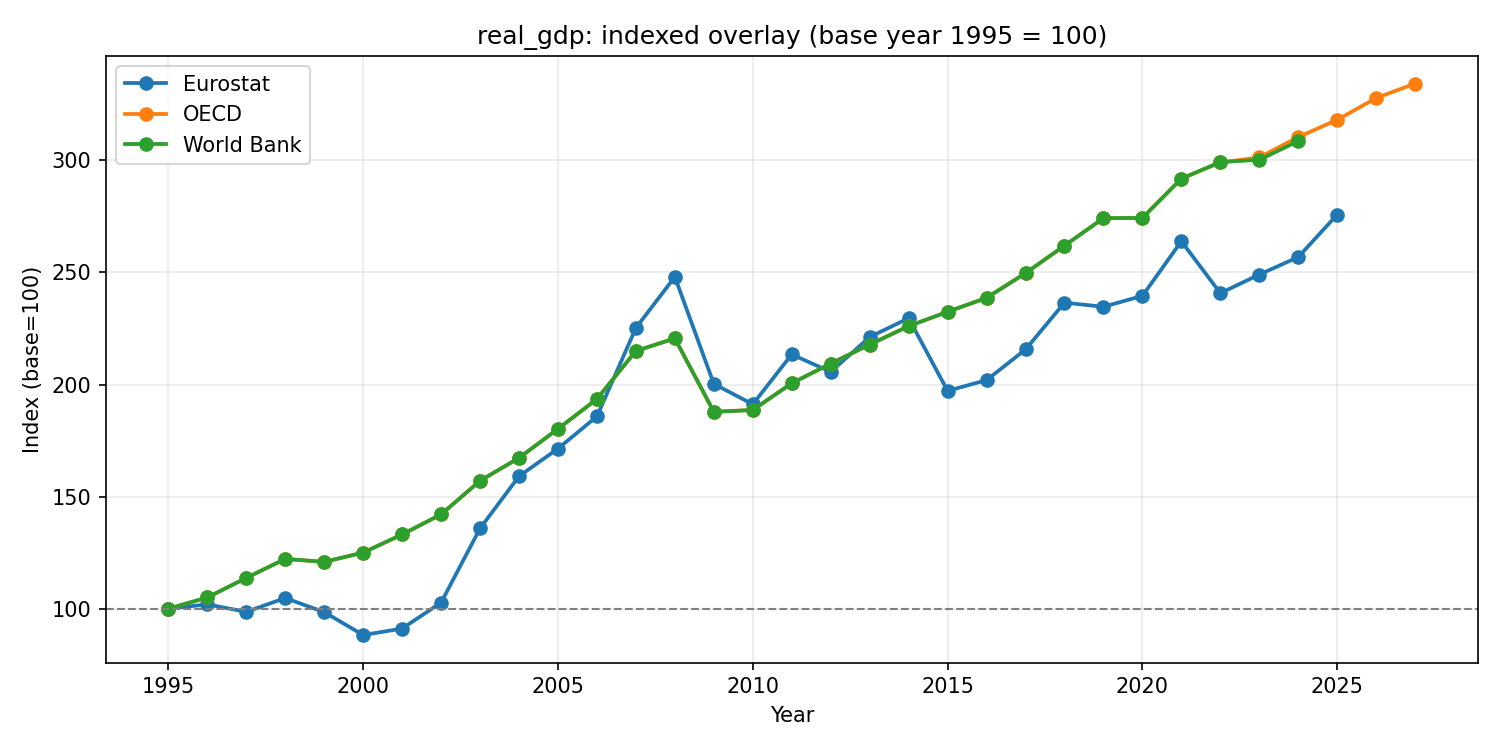

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.MKTP.KD`) | constant USD | `USD` | `value_canonical = value_raw` | Exact mapping (constant-price GDP in USD) |
| IMF (`NGDP_R`) | source-defined | `USD` | `value_canonical = value_raw` | Proxy; source unit conventions may differ |
| Eurostat (`nama_10_gdp`, `CLV10_MEUR`) | million EUR (chain-linked volumes, 2010 ref) | `USD` | `value_canonical = value_raw * 1e6 * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series; constant-price methodology differs from other sources |
| OECD (`DSD_EO@DF_EO`, `GDP_USD`) | `USD` | `USD` | `value_canonical = value_raw` | Proxy: OECD EO GDP is in USD at constant exchange rates |

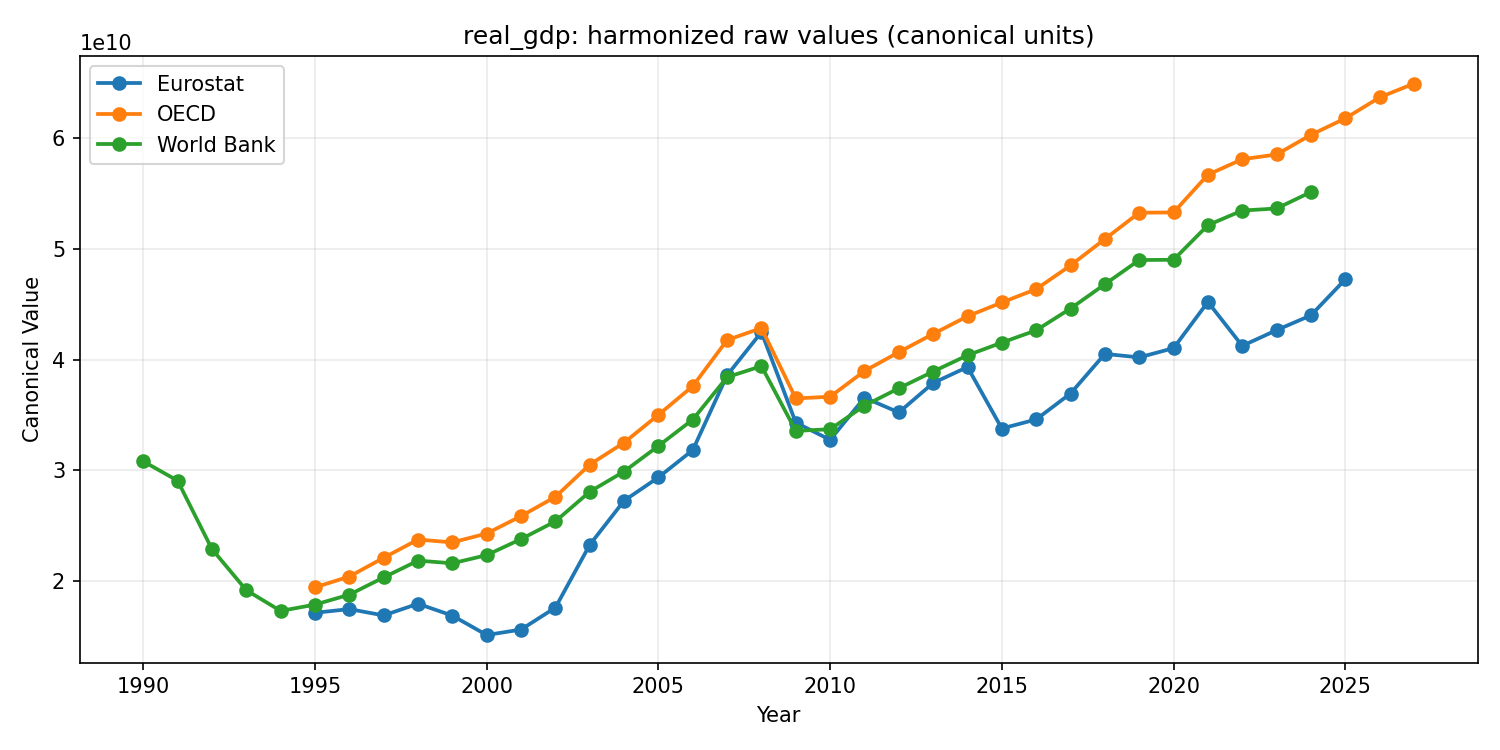

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### gdp_current_usd

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


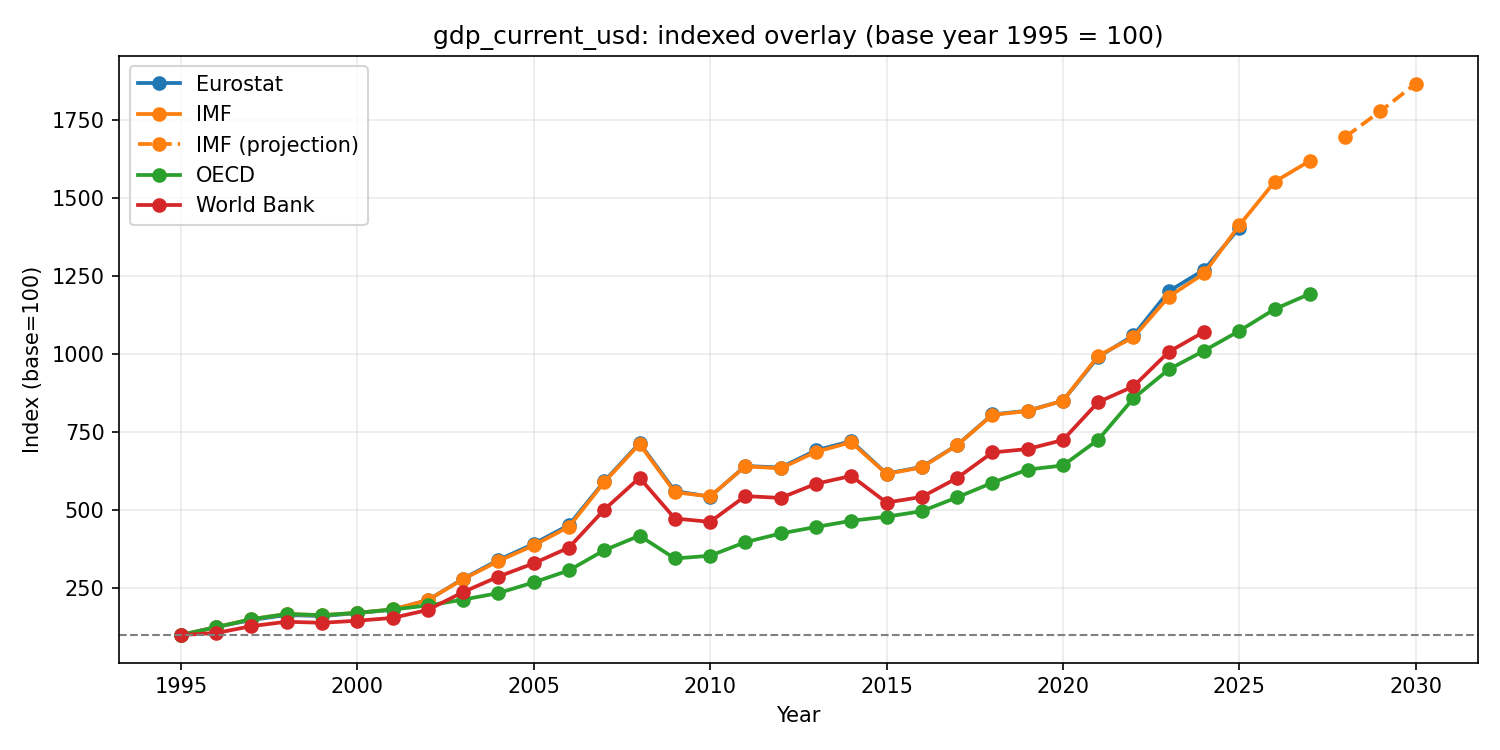

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.MKTP.CD`) | `USD` | `USD` | `value_canonical = value_raw` | Exact mapping |
| IMF (`NGDPD`) | source-defined | `USD` | `value_canonical = value_raw * 1e9` | WEO-backed; future years are projection-flagged |
| Eurostat (`nama_10_gdp`, `CP_MEUR`) | million EUR | `USD` | `value_canonical = value_raw * 1e6 * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series |
| OECD (`DSD_EO@DF_EO`, `GDP_USD`) | `USD` | `USD` | `value_canonical = value_raw` | Proxy: OECD EO GDP is in USD at constant exchange rates (not WB current US$) |

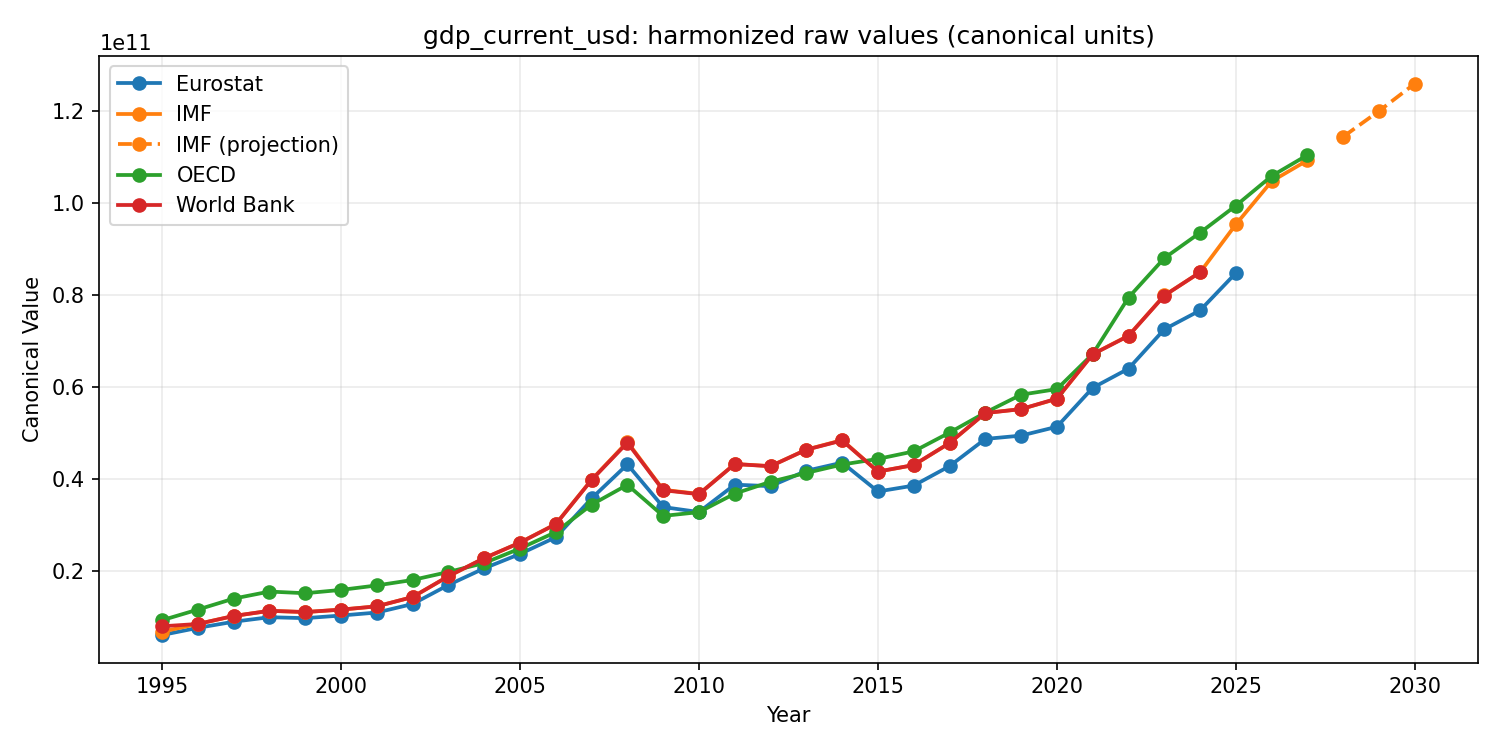

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### gdp_per_capita

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


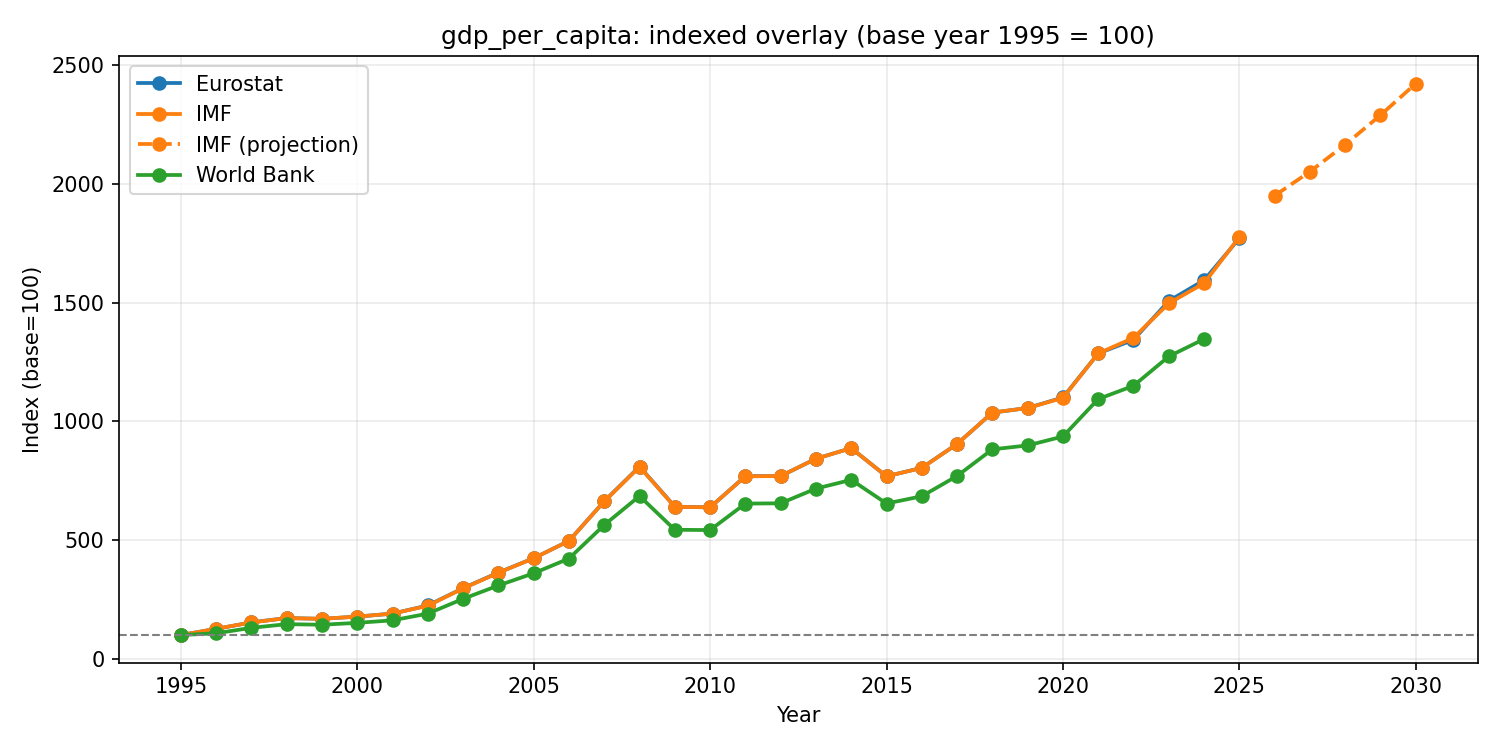

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.PCAP.CD`) | USD per capita | USD per capita | identity | Exact mapping |
| IMF (`NGDPDPC`) | source-defined | USD per capita | identity | WEO-backed; future years are projection-flagged |
| Eurostat (`nama_10_pc`, `CP_EUR_HAB`) | EUR per inhabitant | USD per capita | `value_canonical = value_raw * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series |

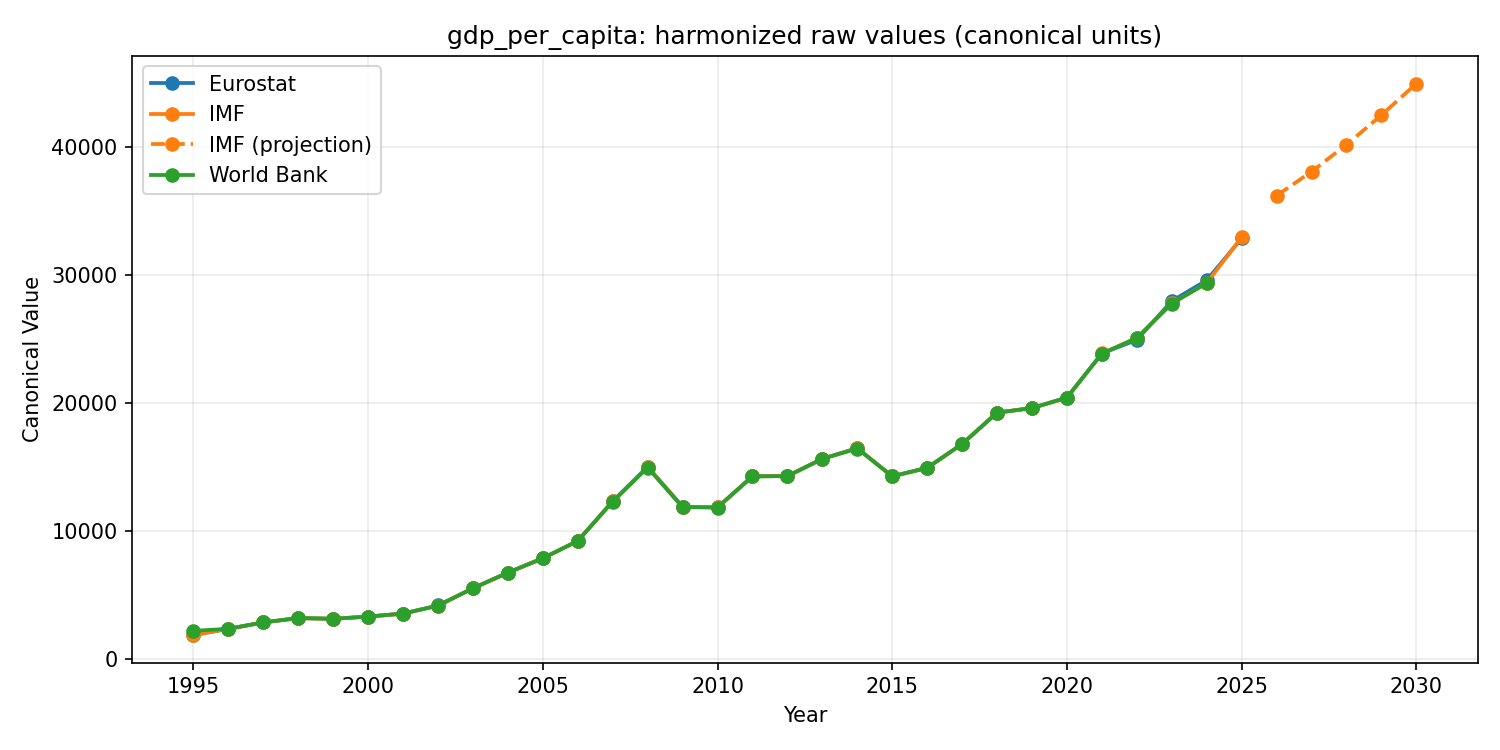

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Labor market

#### unemployment_rate

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1999.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


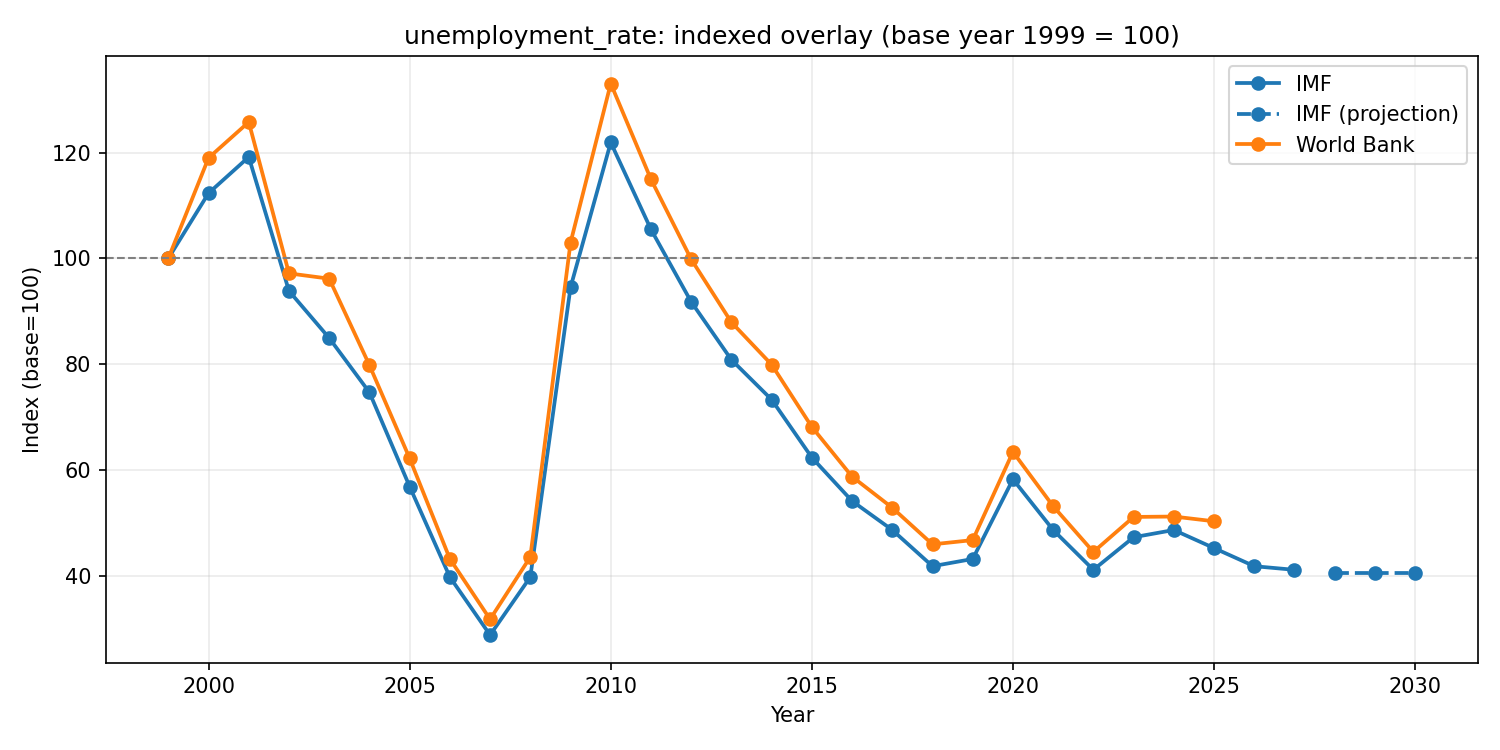

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`SL.UEM.TOTL.ZS`) | percent | percent | identity | Exact mapping |
| IMF (`LUR`) | source-defined | percent | identity | Comparable concept; possible projection years |
| Eurostat (`une_rt_a`) | `PC_ACT` | percent | identity | Proxy (methodology differences) |
| OECD (`DSD_EO@DF_EO`, `UNR`) | percent | percent | identity | Comparable unemployment concept from OECD EO |

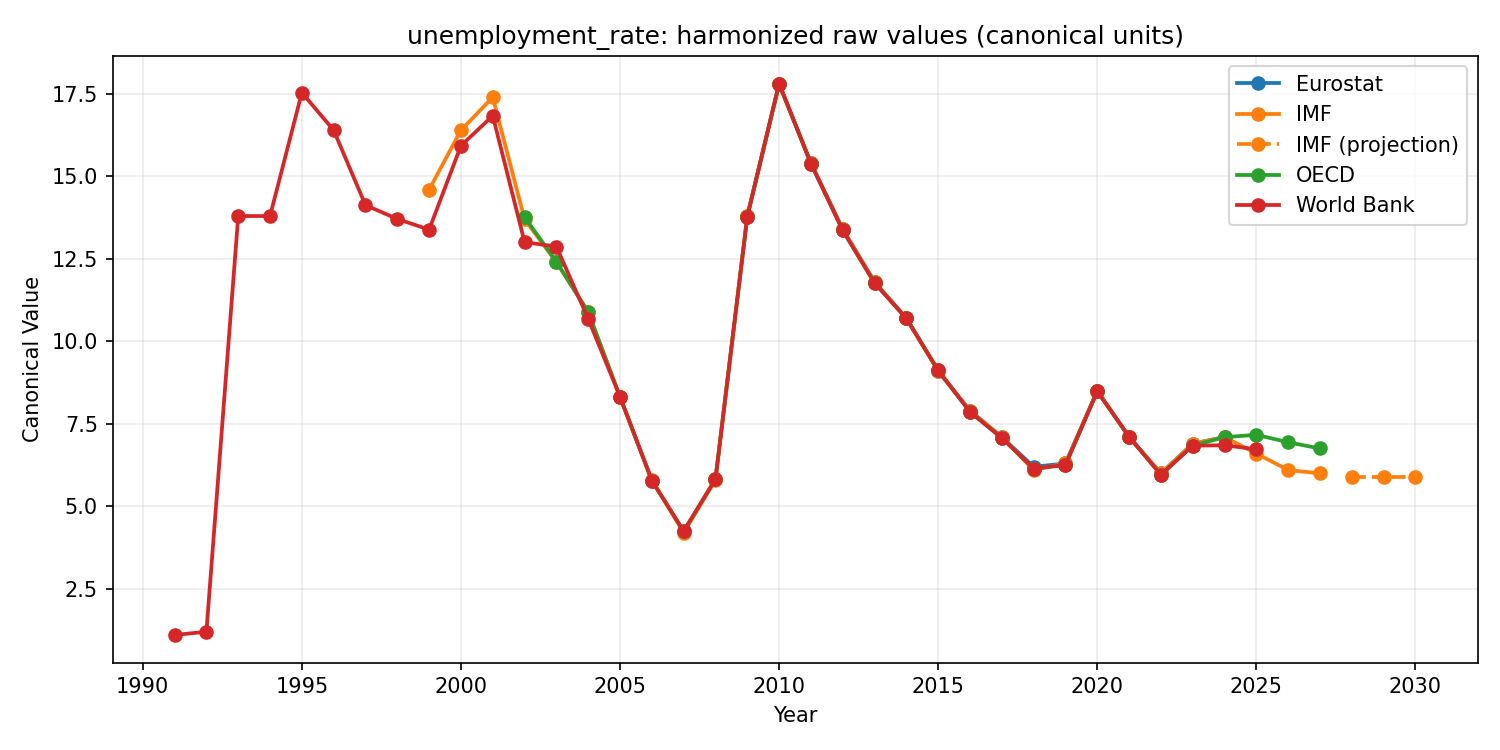

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Inflation and prices

#### inflation_cpi_yoy

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1996.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


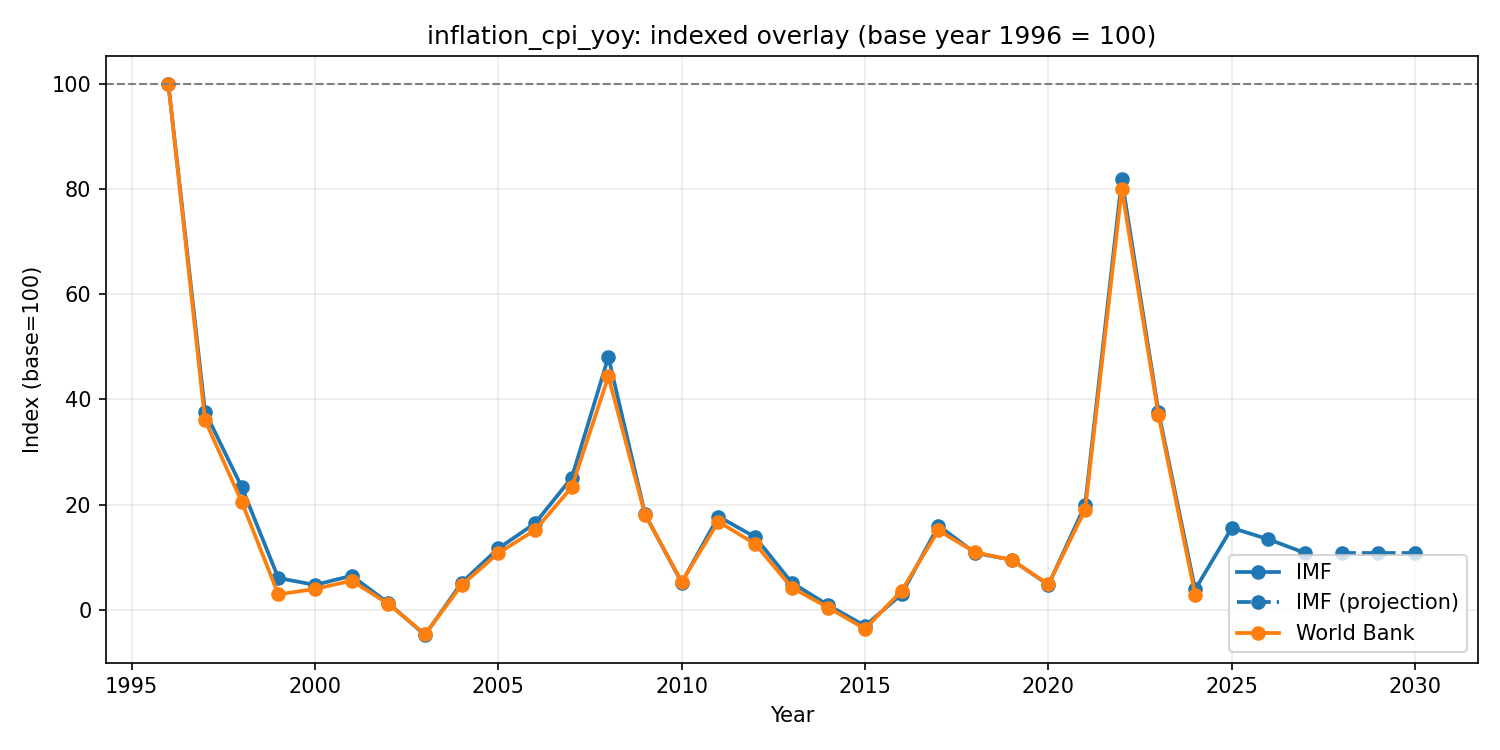

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`FP.CPI.TOTL.ZG`) | percent | percent | identity | Exact mapping |
| IMF (`PCPIPCH`) | source-defined | percent | identity | Proxy-equivalent concept; future years can be projections |
| Eurostat (`prc_hicp_manr`) | `RCH_A` monthly YoY | percent annual | annual mean of monthly values | Proxy with methodology differences |
| OECD (`DSD_EO@DF_EO`, `CPIH_YTYPCT`) | percent | percent | identity | Proxy: harmonised CPI annual inflation rate |

Chart rendering note: `inflation_cpi_yoy` raw and raw-harmonized charts use a logarithmic y-axis; if any non-positive values exist, the axis falls back to `symlog`.

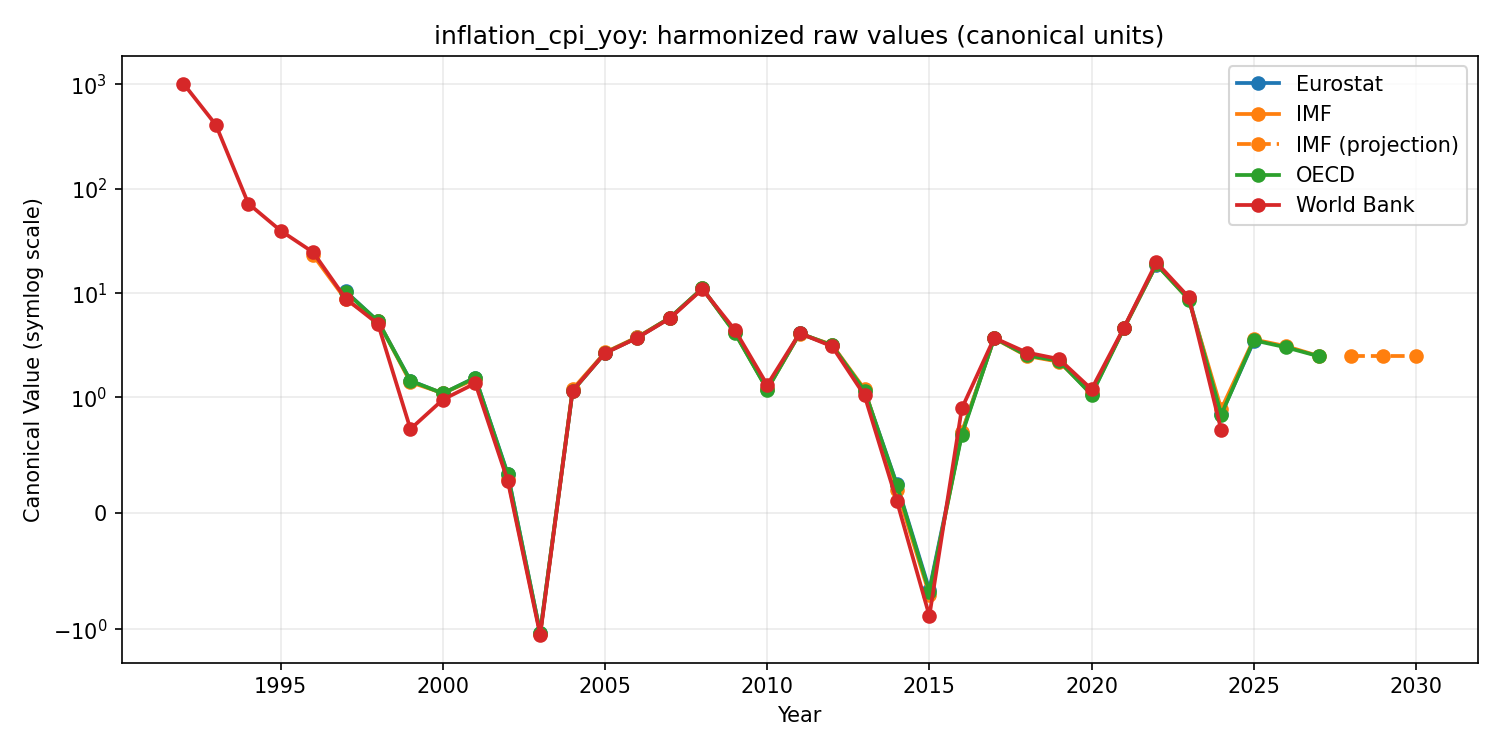

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Monetary conditions and interest rates

#### lending_interest_rate

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,2000.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


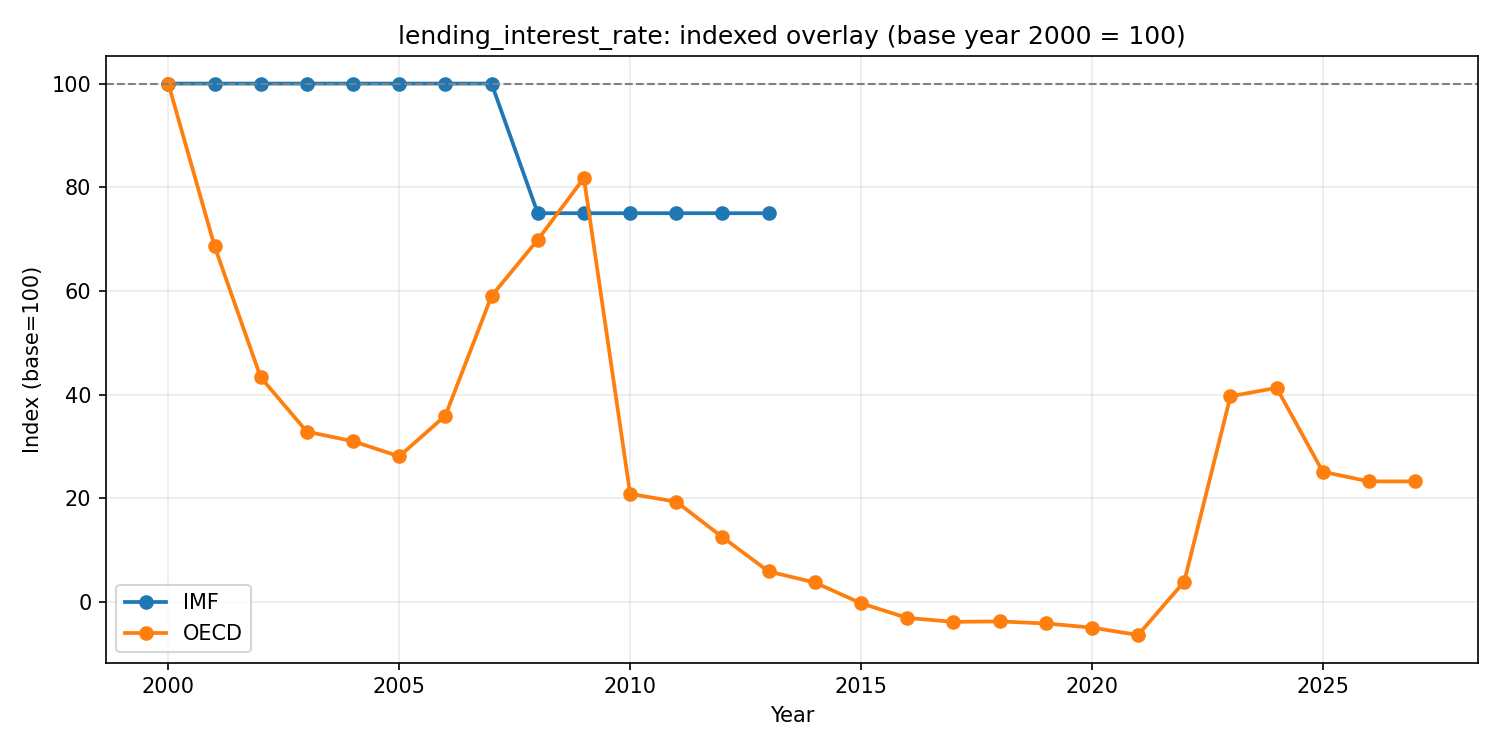

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`FR.INR.LEND`) | percent | percent | identity | Endpoint resolves but currently no numeric LT rows |
| IMF (`Ka_mm`) | index | percent (pipeline canonical target) | identity | Weak proxy; LT availability only to 2013 |
| Eurostat (`irt_lt_mcby_a`) | percent | percent | identity | Proxy (long-term rate, not direct lending rate) |
| OECD (`DSD_EO@DF_EO`, `IRS`) | percent | percent | identity | Proxy: short-term interest rate, not direct lending rate |

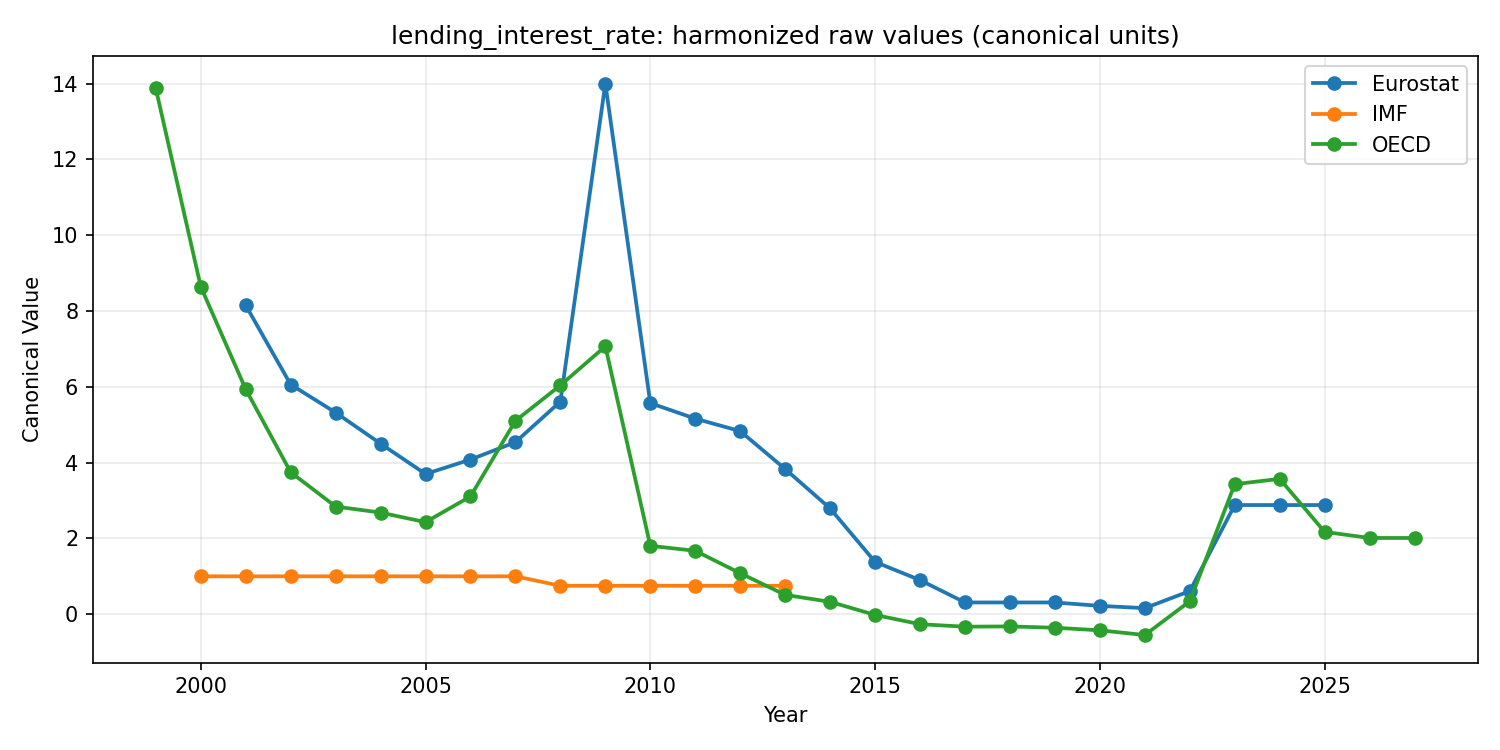

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Fiscal indicators

#### general_government_gross_debt_pct_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1998.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


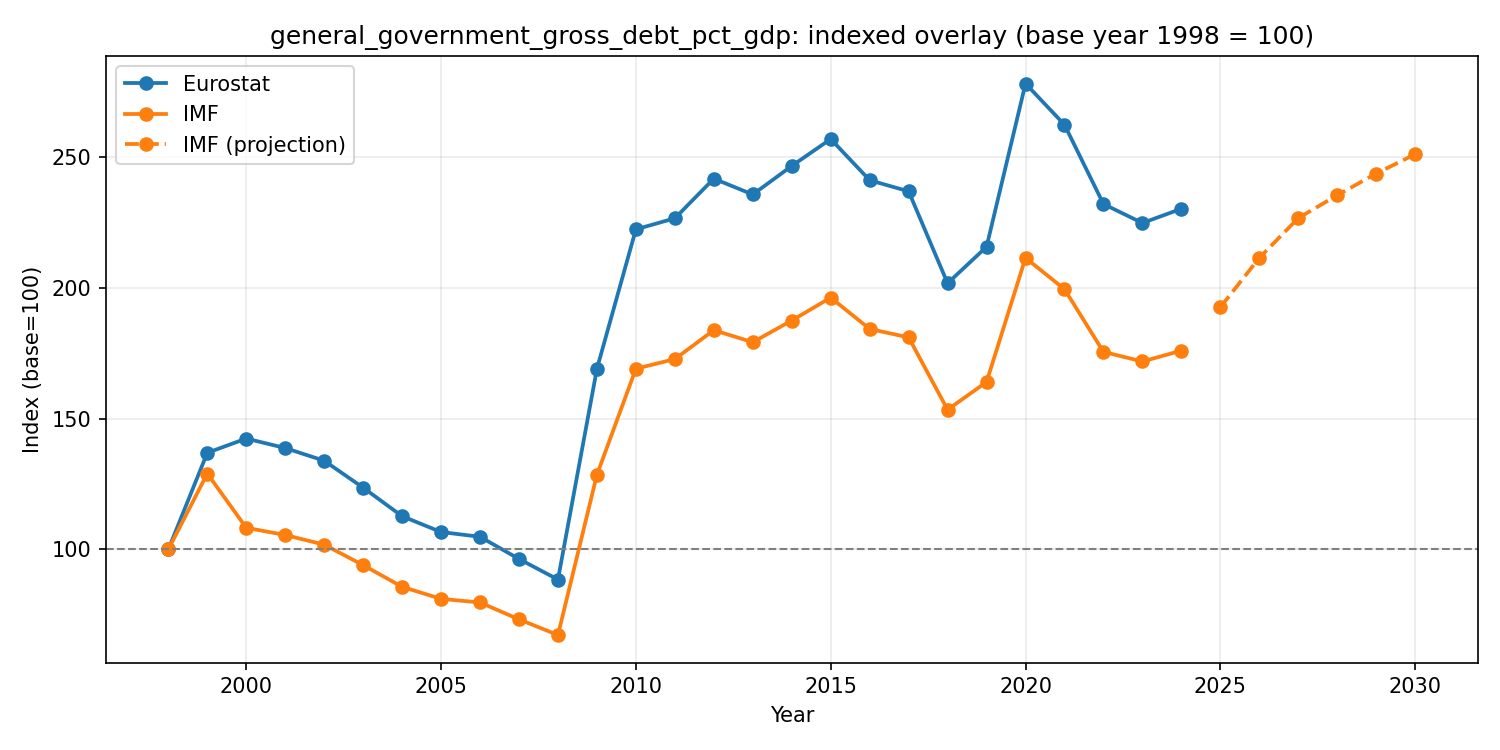

_Glossary:_ indexed comparison derived from harmonized comparable values.

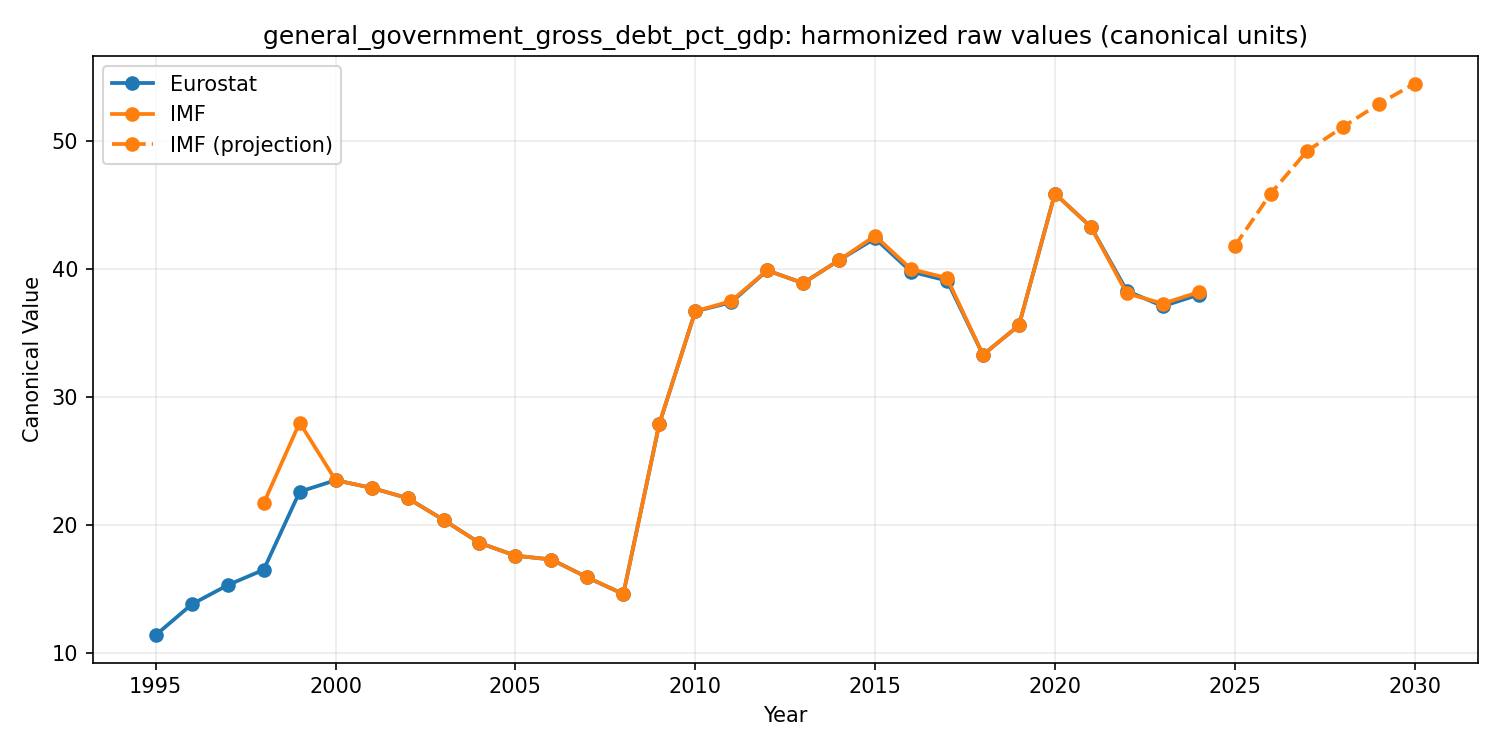

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### general_government_balance_deficit_pct_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,skipped,NaN,NaN,No overlap year with at least two sources.
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


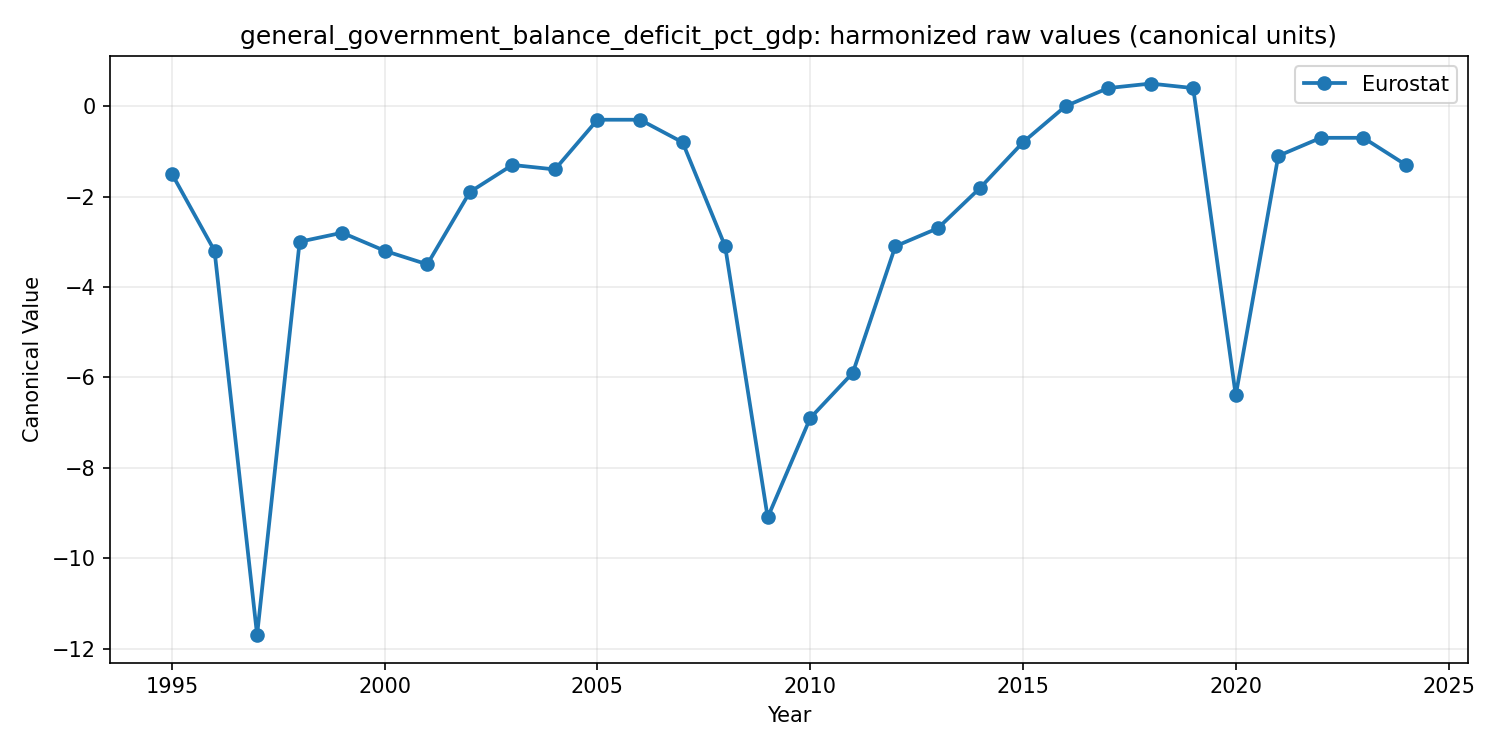

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### External sector indicators

#### trade_balance_pct_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


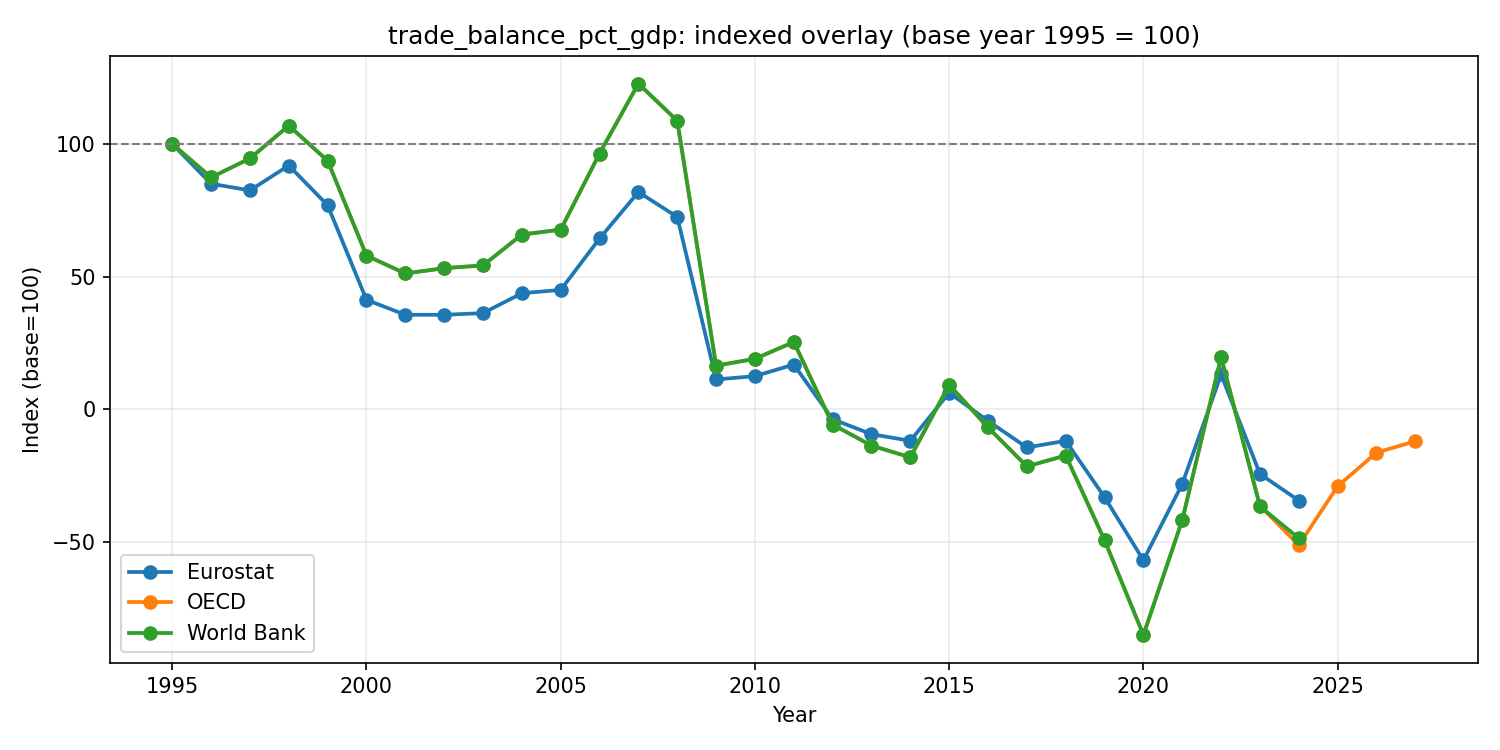

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NE.RSB.GNFS.ZS`) | percent of GDP | percent of GDP | identity | Exact mapping |
| IMF (`BT_GDP`) | source-defined | percent of GDP | identity | Proxy with potential definition differences |
| Eurostat (`bop_gdp6_q`) | `PC_GDP` | percent of GDP | identity | Proxy (BPM6 framing differs) |
| OECD (`DSD_EO@DF_EO`, `FBGSQ`) | percent of GDP | percent of GDP | identity | Proxy: net exports of goods/services as % GDP |

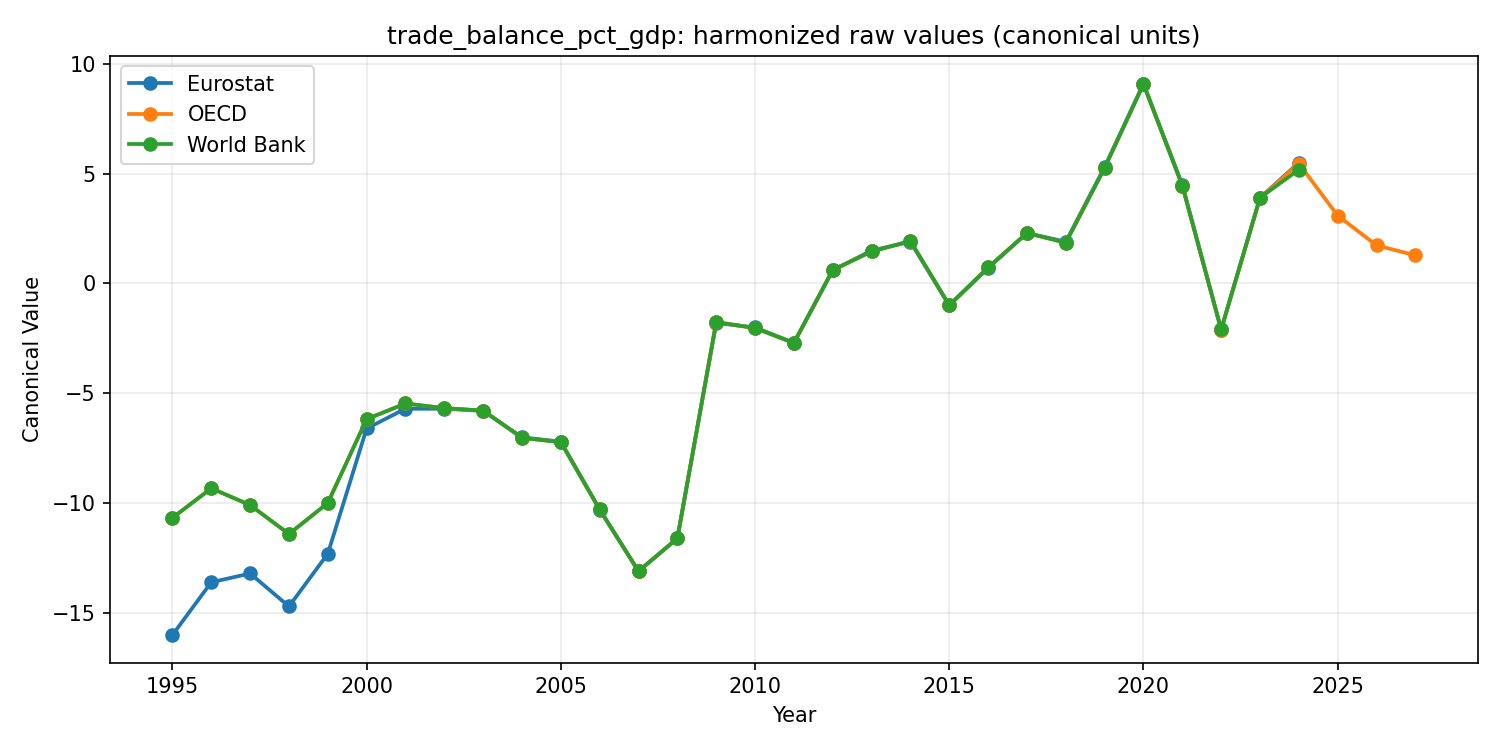

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### exchange_rate_lcu_per_usd

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1994.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


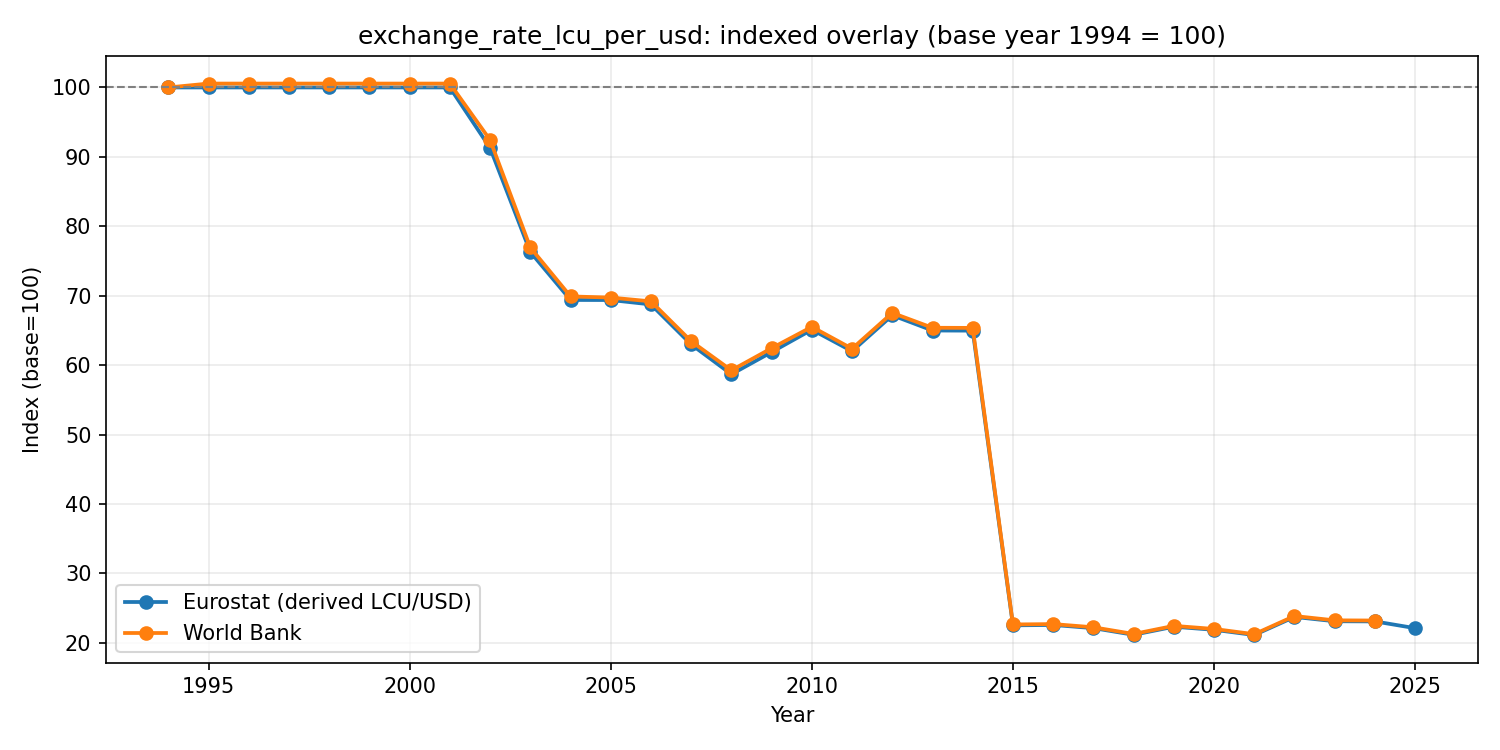

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`PA.NUS.FCRF`) | LCU per USD | LCU per USD | identity | Exact mapping |
| Eurostat raw (`ert_bil_eur_a`) | USD per EUR (`NAC`) | LCU per USD target | not directly comparable | Marked `is_comparable=false` for cross-source overlays |
| Eurostat derived (`eurostat_derived`) | derived from USD/EUR | LCU per USD | LT regime rules by year | Comparable series used in harmonized/overlay charts |
| OECD (`DSD_EO@DF_EO`, `EXCHUD`) | LCU per USD | LCU per USD | identity | Proxy: OECD EO exchange-rate conventions can differ by historical treatment |

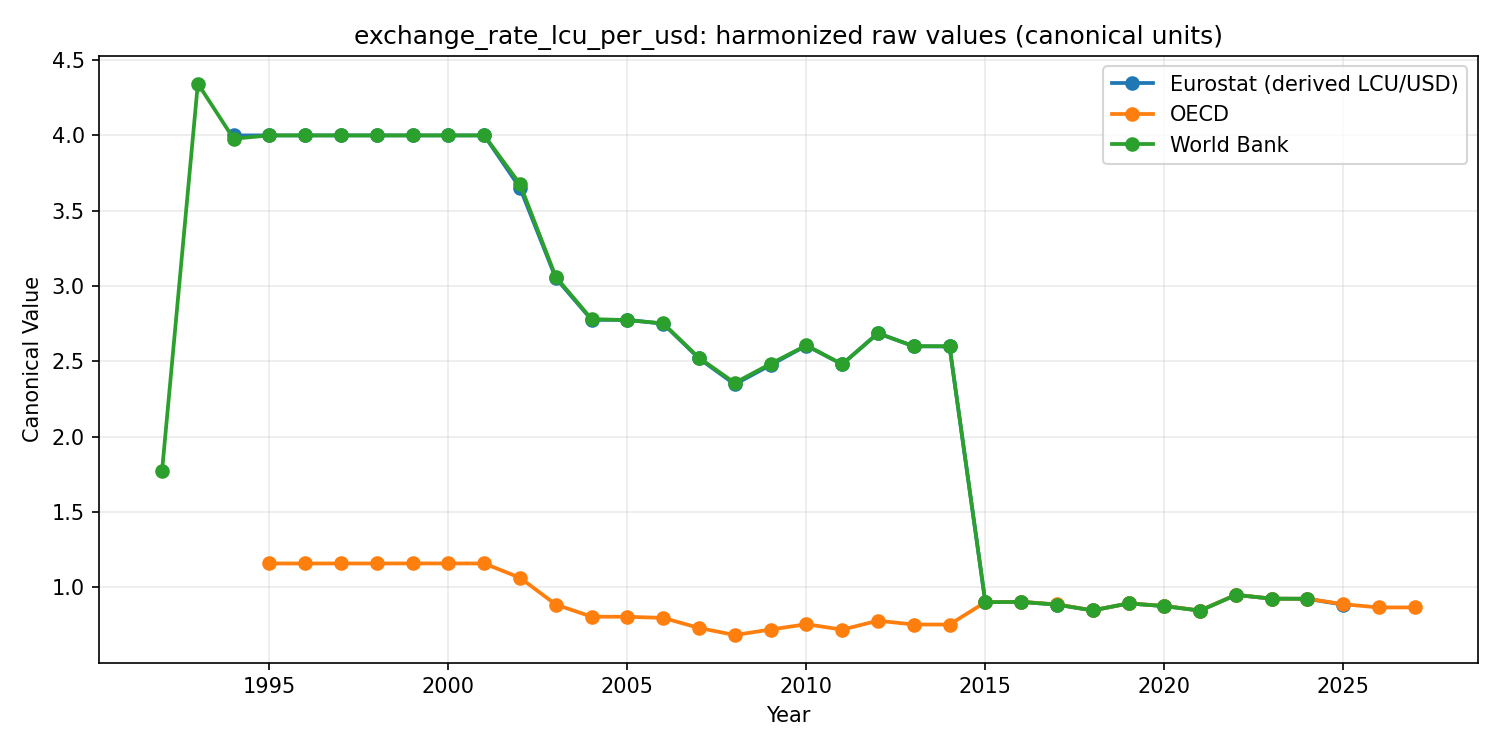

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Confidence and surveys

_No indicators mapped in current pipeline output._

## Static z-score visuals

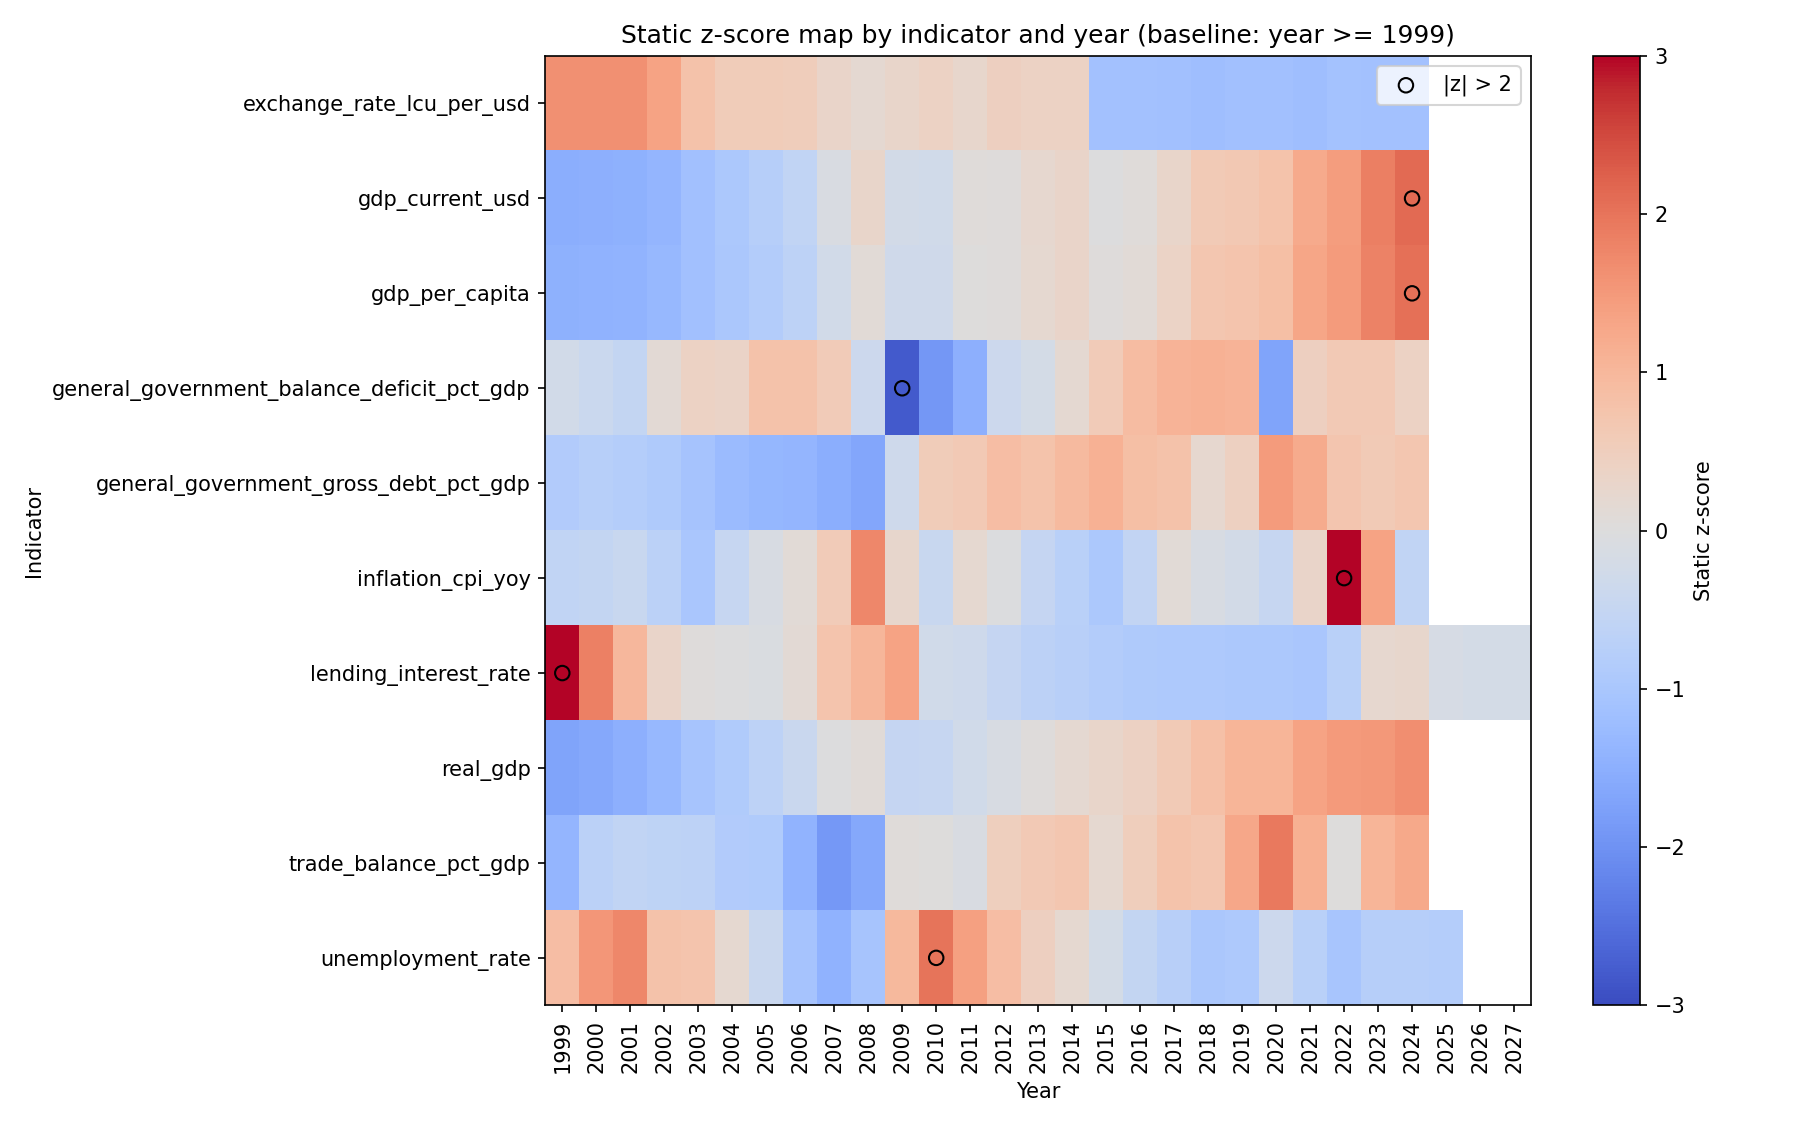

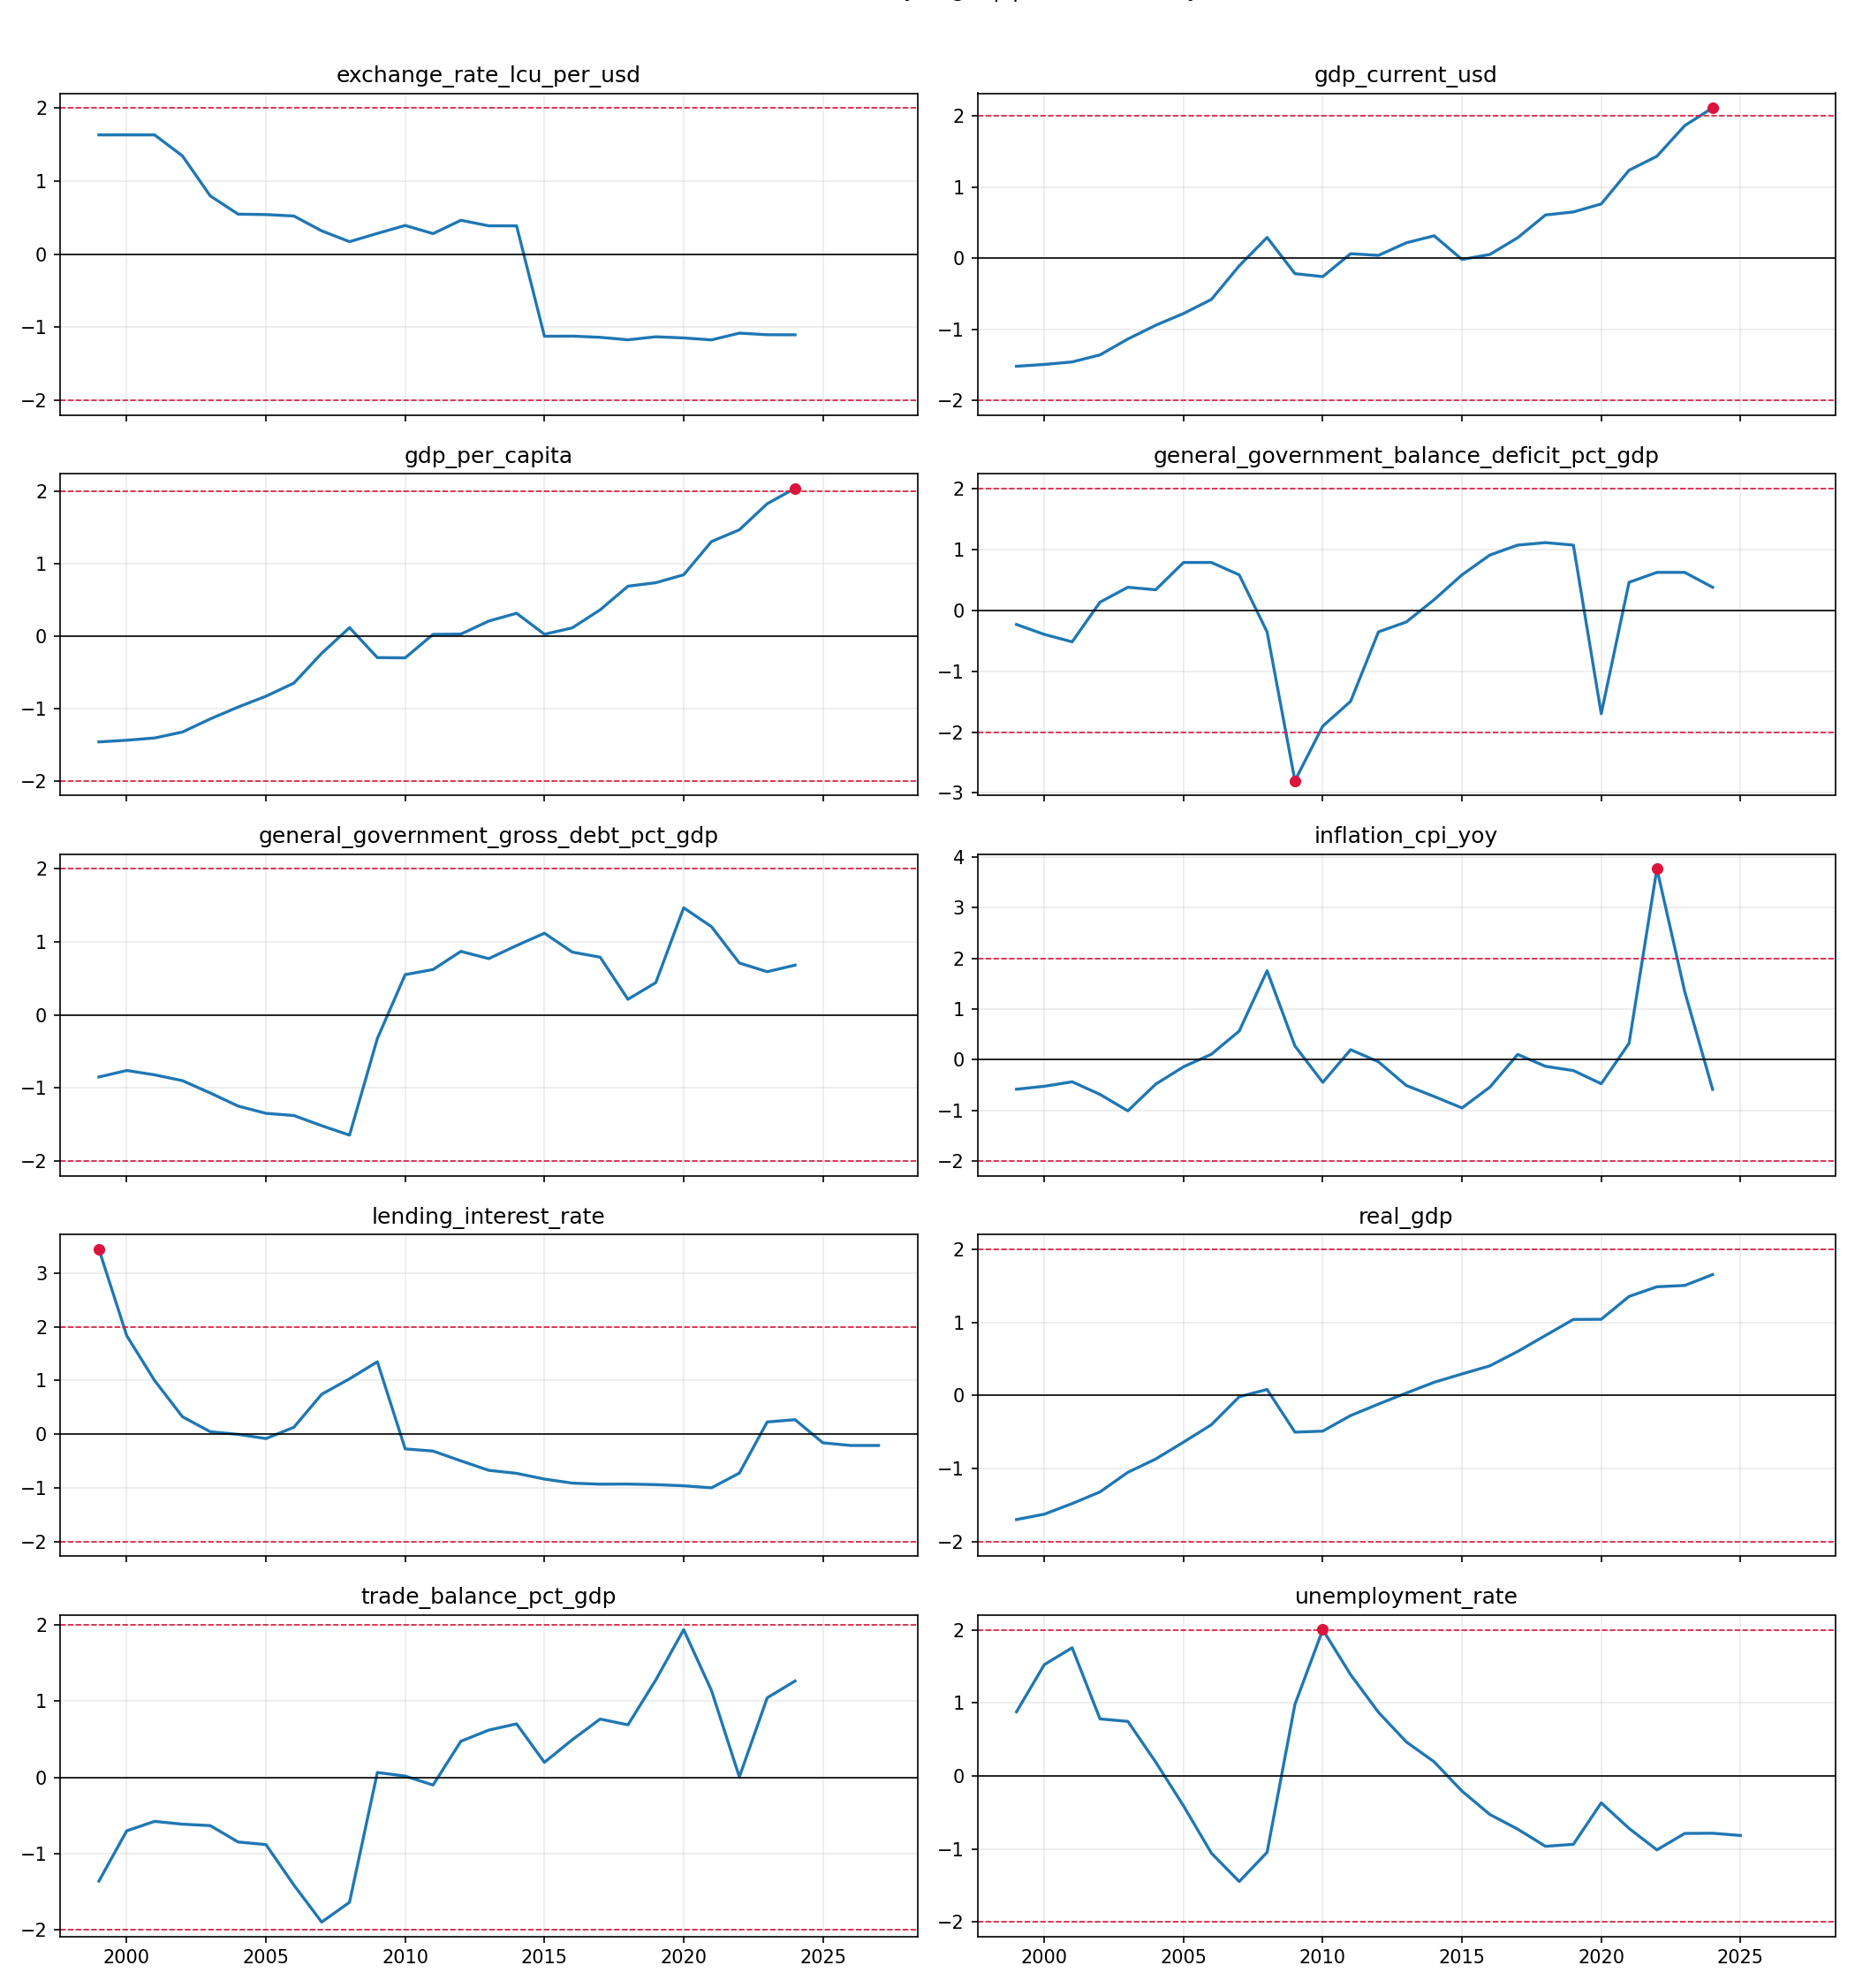

In [6]:
_lt_context = _render_country_section("LT")


## Latvia

Latvia uses the same pipeline outputs and compact chart profile as Lithuania.


**Country code:** `LV`

**Country output directory:** `/workspaces/da-ai/bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics/LV`

## Diagnostics

### Coverage status counts

,status,count
0,missing_source,44
1,resolved,36
2,known_but_missing_params,20


...

,check_name,actual_value,target,status,details
0,all_indicators_have_two_or_more_sources,9,10,fail,Count of indicators meeting >=2 plot-ready sou...
1,indicator_general_government_balance_deficit_p...,1,>=2,fail,Per-indicator plot-ready source count.
2,indicator_exchange_rate_lcu_per_usd_sources,3,>=2,pass,Per-indicator plot-ready source count.
3,indicator_gdp_current_usd_sources,4,>=2,pass,Per-indicator plot-ready source count.
4,indicator_gdp_per_capita_sources,3,>=2,pass,Per-indicator plot-ready source count.
5,indicator_general_government_gross_debt_pct_gd...,3,>=2,pass,Per-indicator plot-ready source count.
6,indicator_inflation_cpi_yoy_sources,4,>=2,pass,Per-indicator plot-ready source count.
7,indicator_lending_interest_rate_sources,3,>=2,pass,Per-indicator plot-ready source count.
8,indicator_real_gdp_sources,3,>=2,pass,Per-indicator plot-ready source count.
9,indicator_trade_balance_pct_gdp_sources,3,>=2,pass,Per-indicator plot-ready source count.


## Indicator charts

### Output and growth

#### real_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


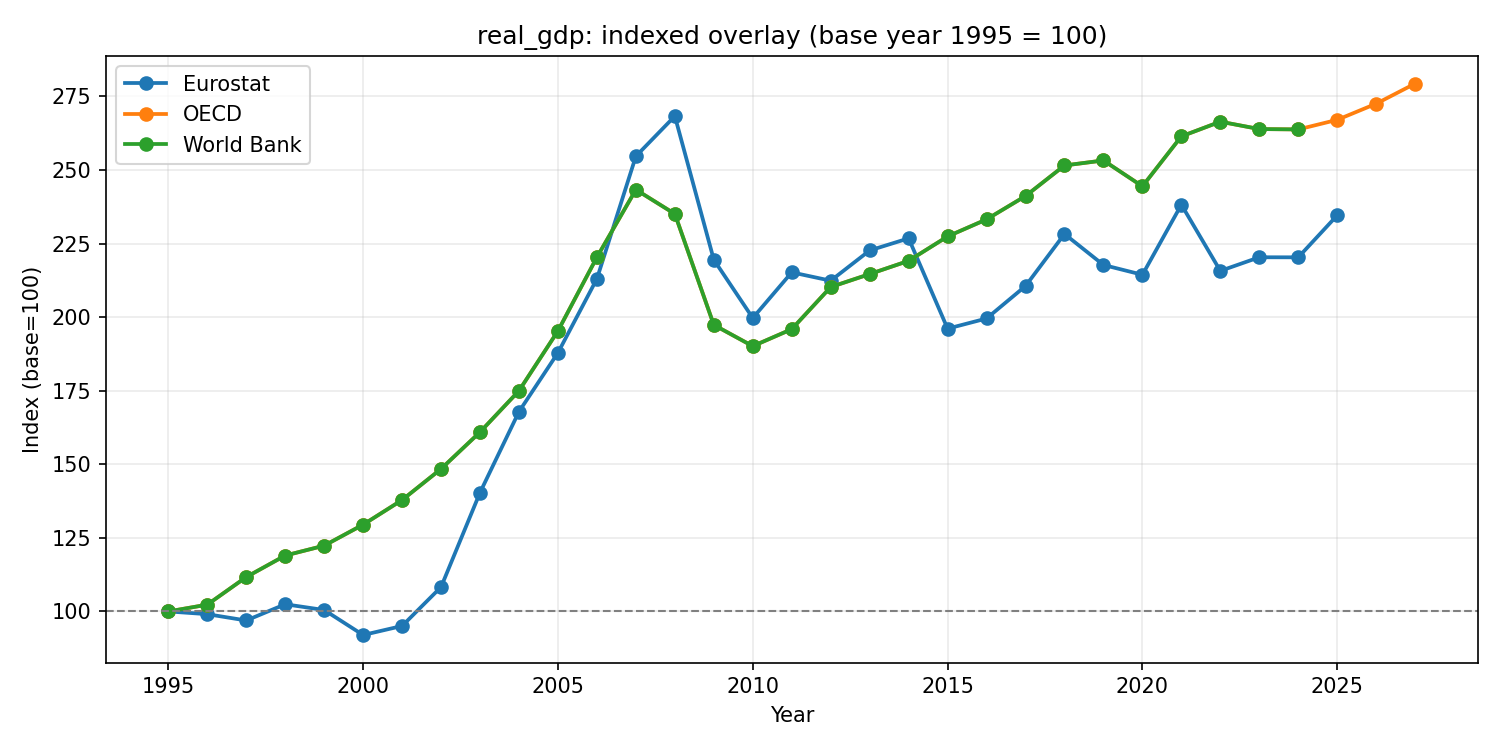

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.MKTP.KD`) | constant USD | `USD` | `value_canonical = value_raw` | Exact mapping (constant-price GDP in USD) |
| IMF (`NGDP_R`) | source-defined | `USD` | `value_canonical = value_raw` | Proxy; source unit conventions may differ |
| Eurostat (`nama_10_gdp`, `CLV10_MEUR`) | million EUR (chain-linked volumes, 2010 ref) | `USD` | `value_canonical = value_raw * 1e6 * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series; constant-price methodology differs from other sources |
| OECD (`DSD_EO@DF_EO`, `GDP_USD`) | `USD` | `USD` | `value_canonical = value_raw` | Proxy: OECD EO GDP is in USD at constant exchange rates |

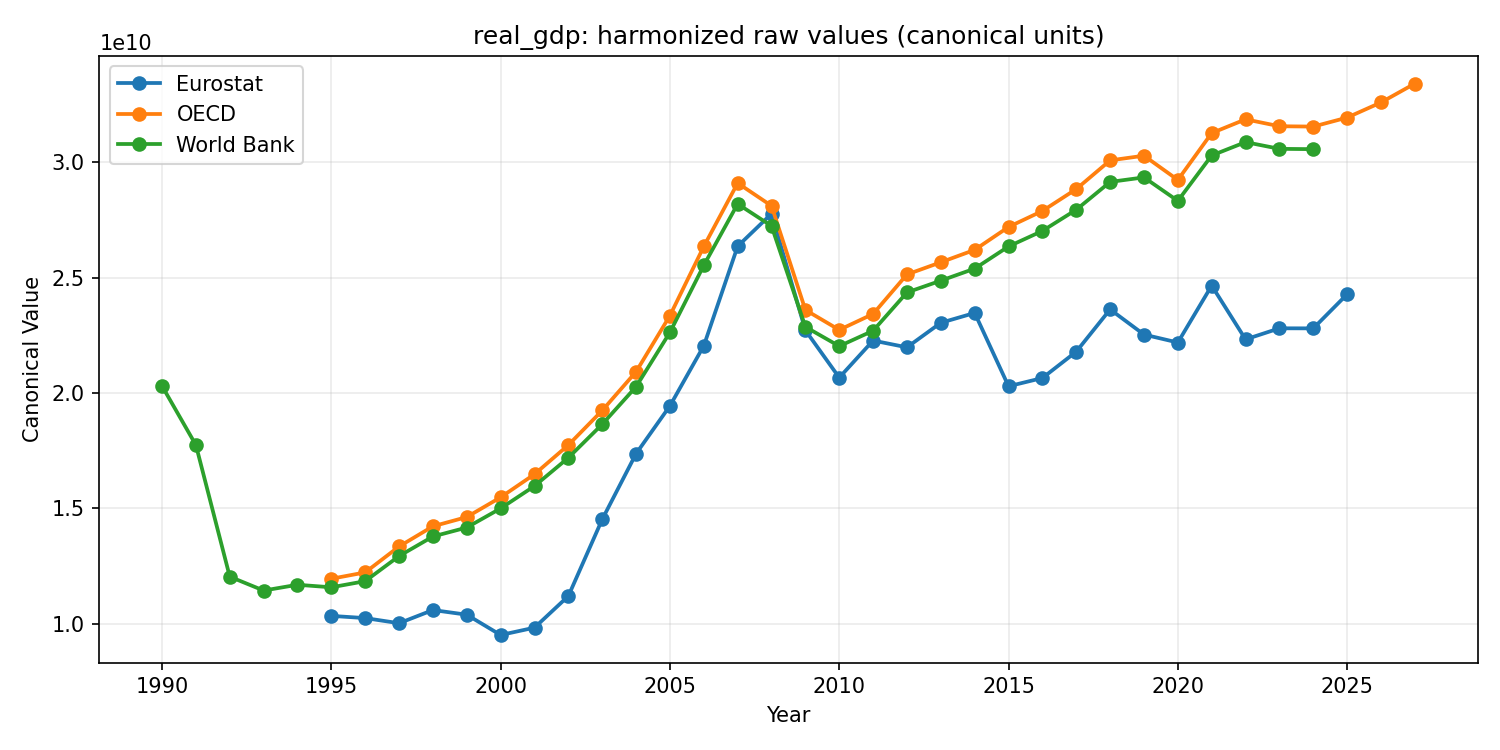

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### gdp_current_usd

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


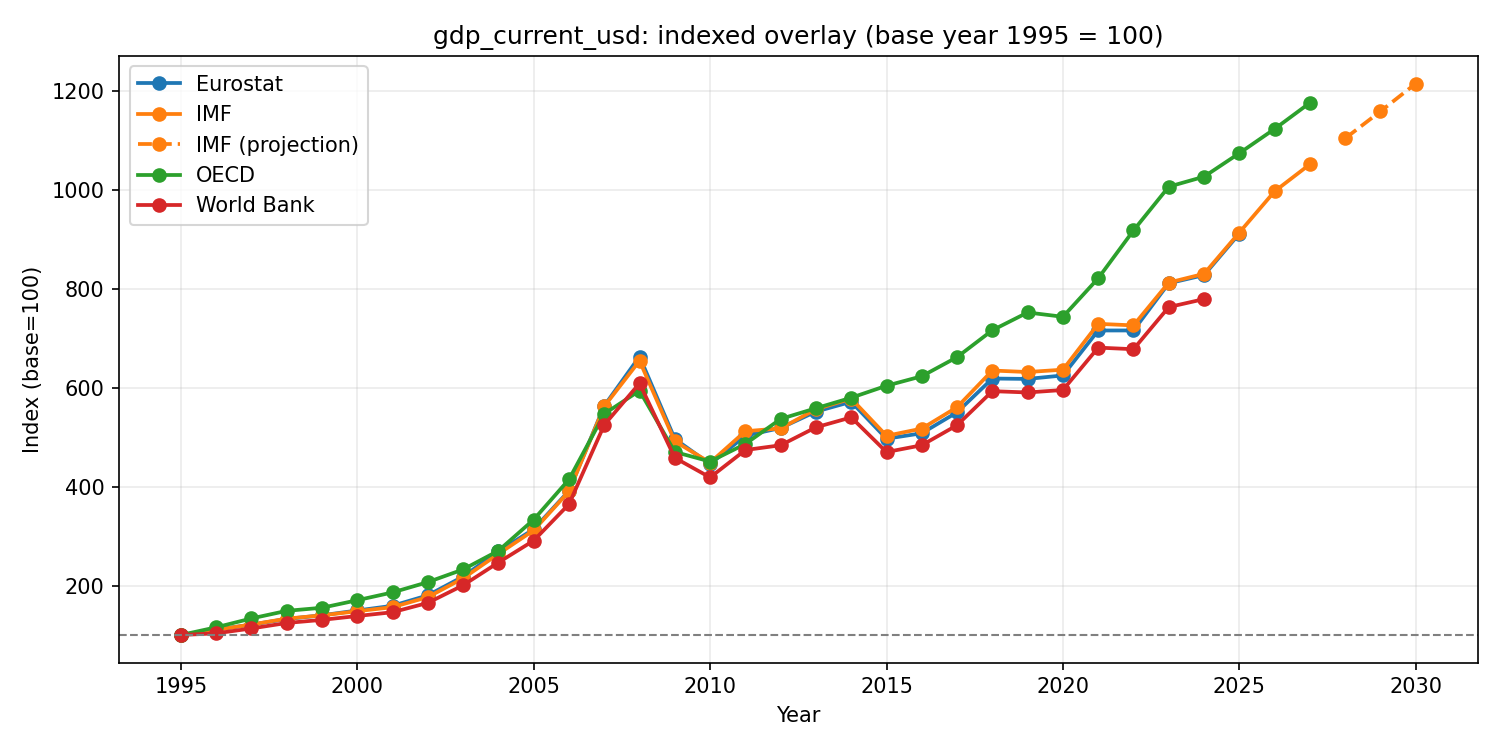

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.MKTP.CD`) | `USD` | `USD` | `value_canonical = value_raw` | Exact mapping |
| IMF (`NGDPD`) | source-defined | `USD` | `value_canonical = value_raw * 1e9` | WEO-backed; future years are projection-flagged |
| Eurostat (`nama_10_gdp`, `CP_MEUR`) | million EUR | `USD` | `value_canonical = value_raw * 1e6 * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series |
| OECD (`DSD_EO@DF_EO`, `GDP_USD`) | `USD` | `USD` | `value_canonical = value_raw` | Proxy: OECD EO GDP is in USD at constant exchange rates (not WB current US$) |

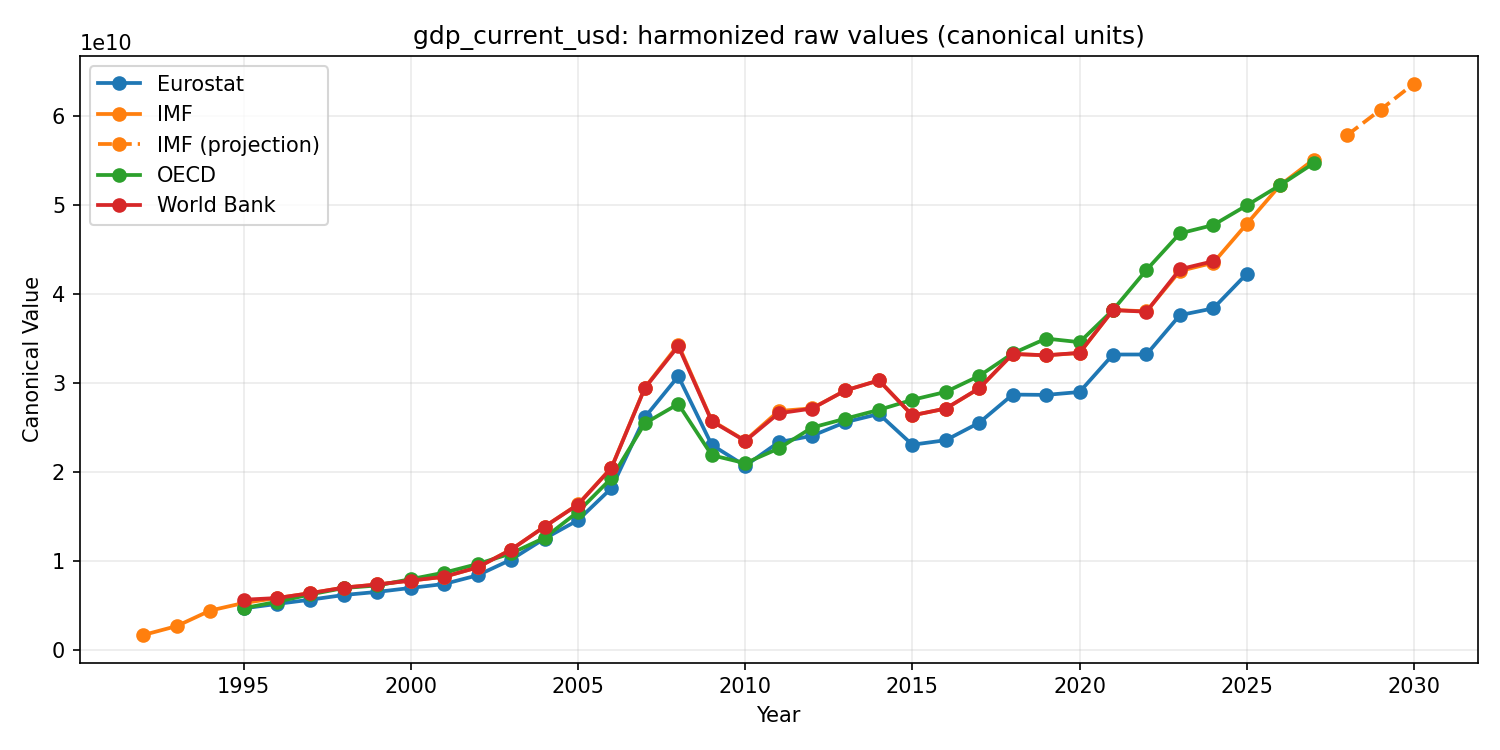

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### gdp_per_capita

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


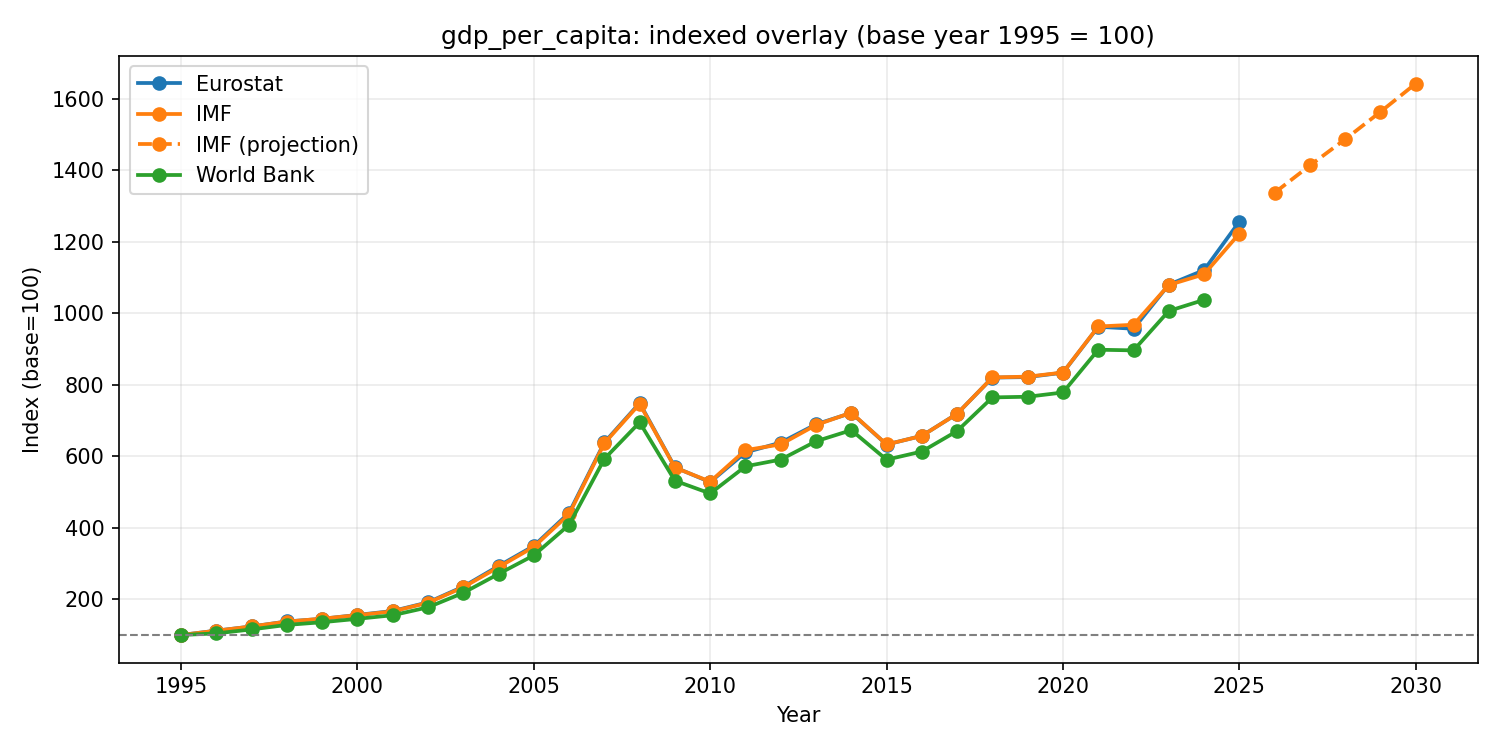

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.PCAP.CD`) | USD per capita | USD per capita | identity | Exact mapping |
| IMF (`NGDPDPC`) | source-defined | USD per capita | identity | WEO-backed; future years are projection-flagged |
| Eurostat (`nama_10_pc`, `CP_EUR_HAB`) | EUR per inhabitant | USD per capita | `value_canonical = value_raw * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series |

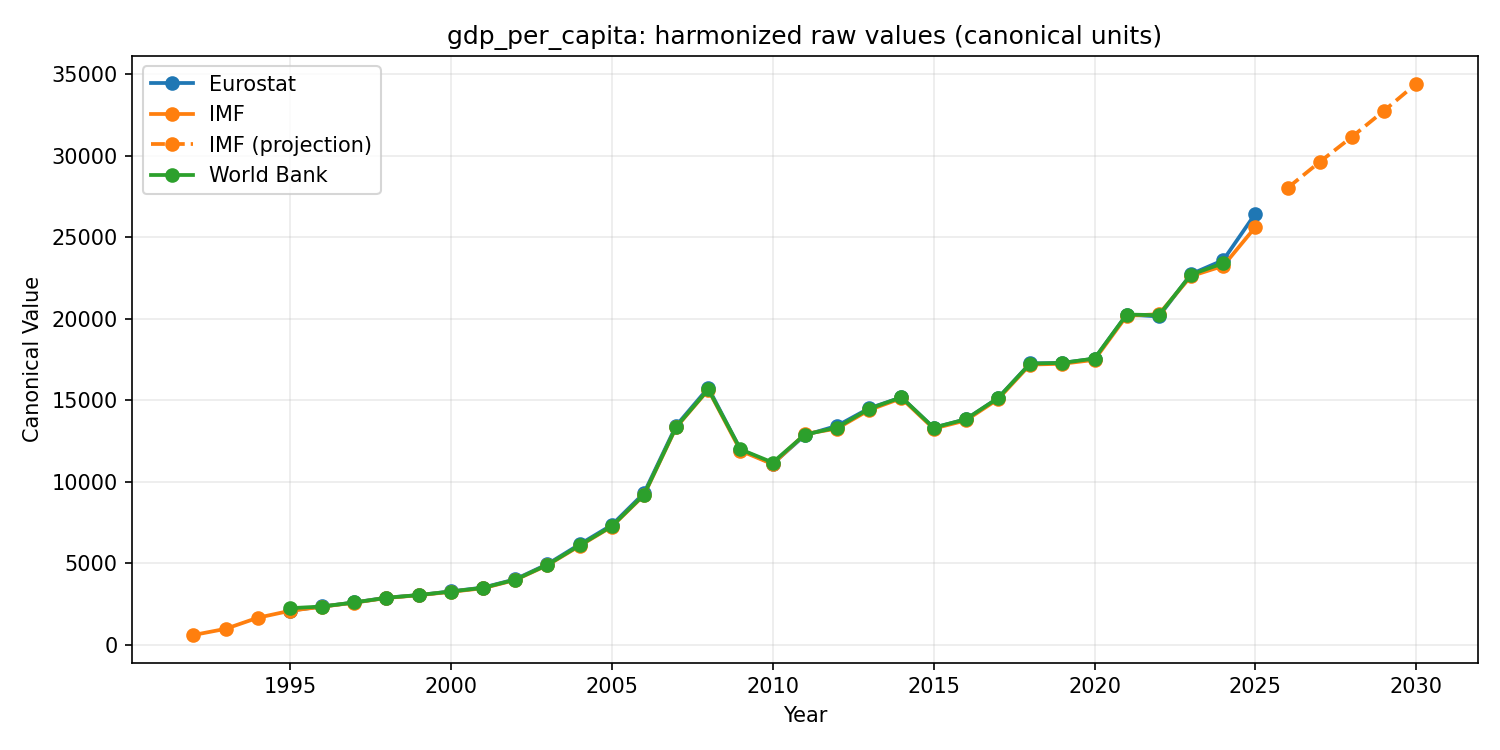

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Labor market

#### unemployment_rate

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1992.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


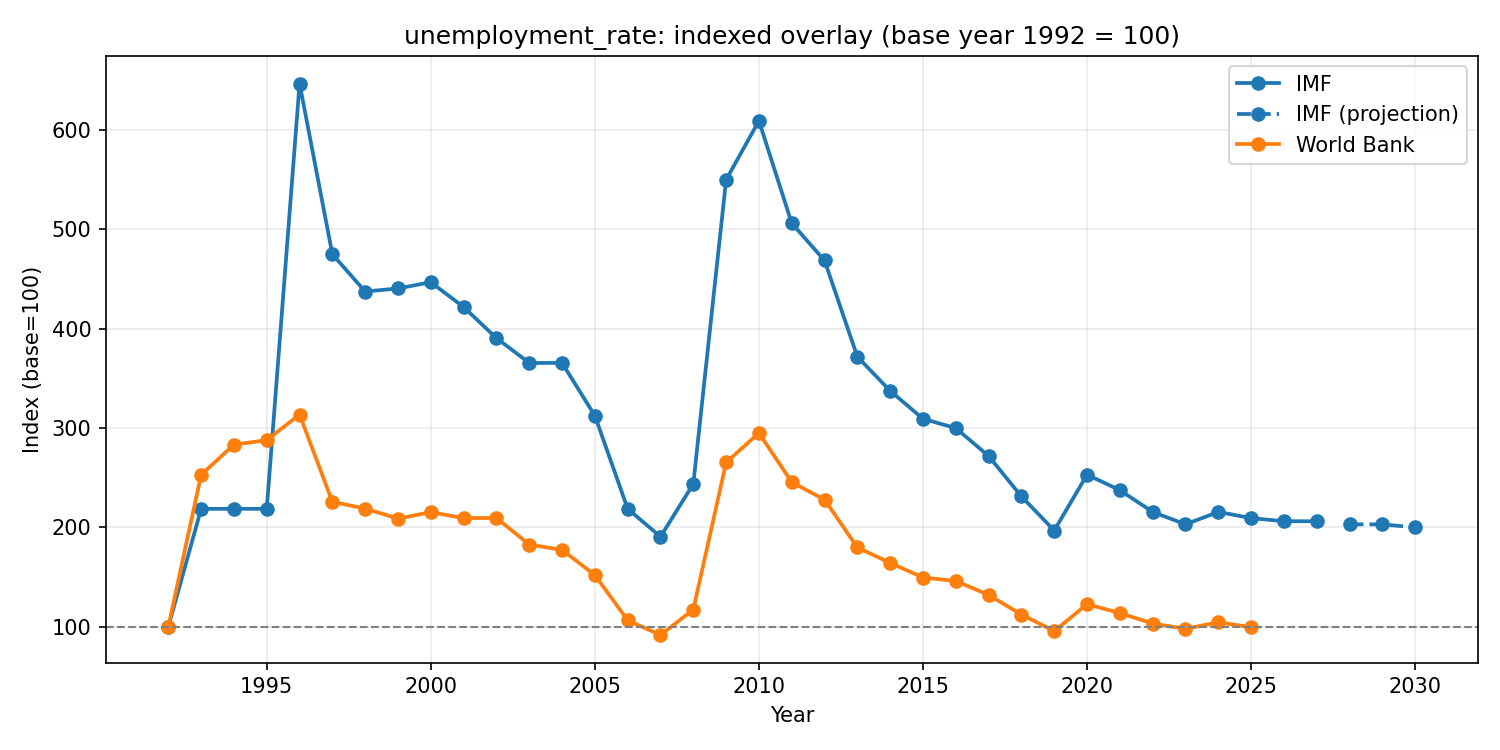

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`SL.UEM.TOTL.ZS`) | percent | percent | identity | Exact mapping |
| IMF (`LUR`) | source-defined | percent | identity | Comparable concept; possible projection years |
| Eurostat (`une_rt_a`) | `PC_ACT` | percent | identity | Proxy (methodology differences) |
| OECD (`DSD_EO@DF_EO`, `UNR`) | percent | percent | identity | Comparable unemployment concept from OECD EO |

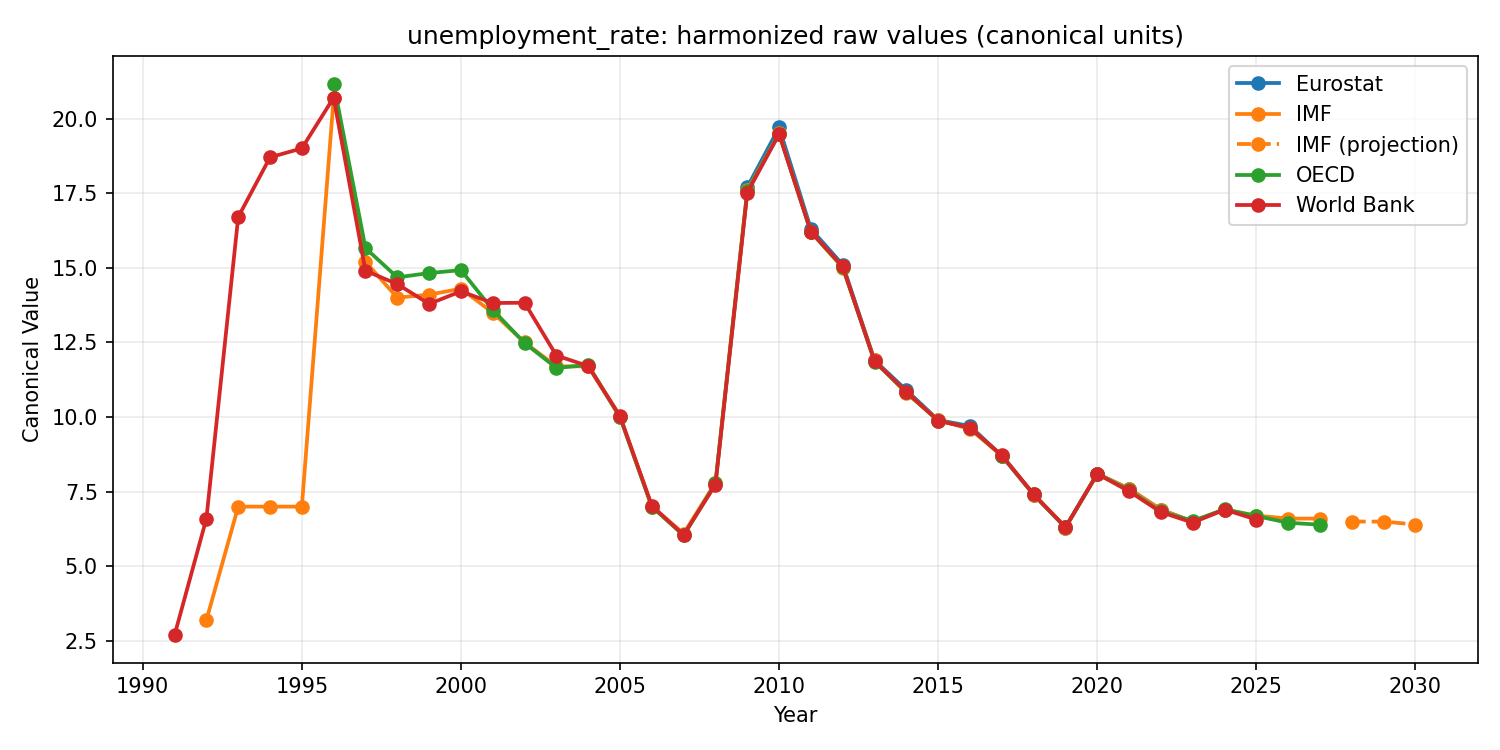

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Inflation and prices

#### inflation_cpi_yoy

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1993.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


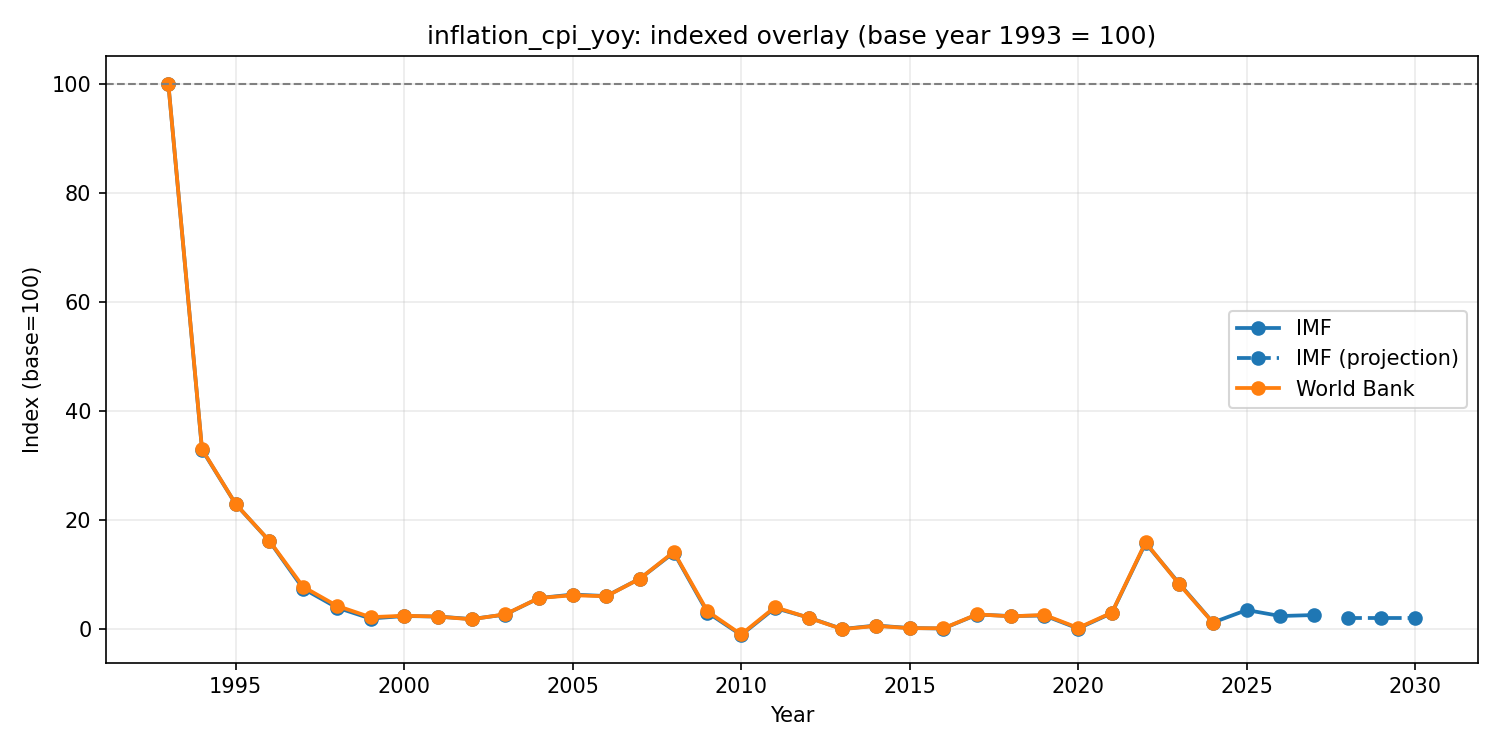

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`FP.CPI.TOTL.ZG`) | percent | percent | identity | Exact mapping |
| IMF (`PCPIPCH`) | source-defined | percent | identity | Proxy-equivalent concept; future years can be projections |
| Eurostat (`prc_hicp_manr`) | `RCH_A` monthly YoY | percent annual | annual mean of monthly values | Proxy with methodology differences |
| OECD (`DSD_EO@DF_EO`, `CPIH_YTYPCT`) | percent | percent | identity | Proxy: harmonised CPI annual inflation rate |

Chart rendering note: `inflation_cpi_yoy` raw and raw-harmonized charts use a logarithmic y-axis; if any non-positive values exist, the axis falls back to `symlog`.

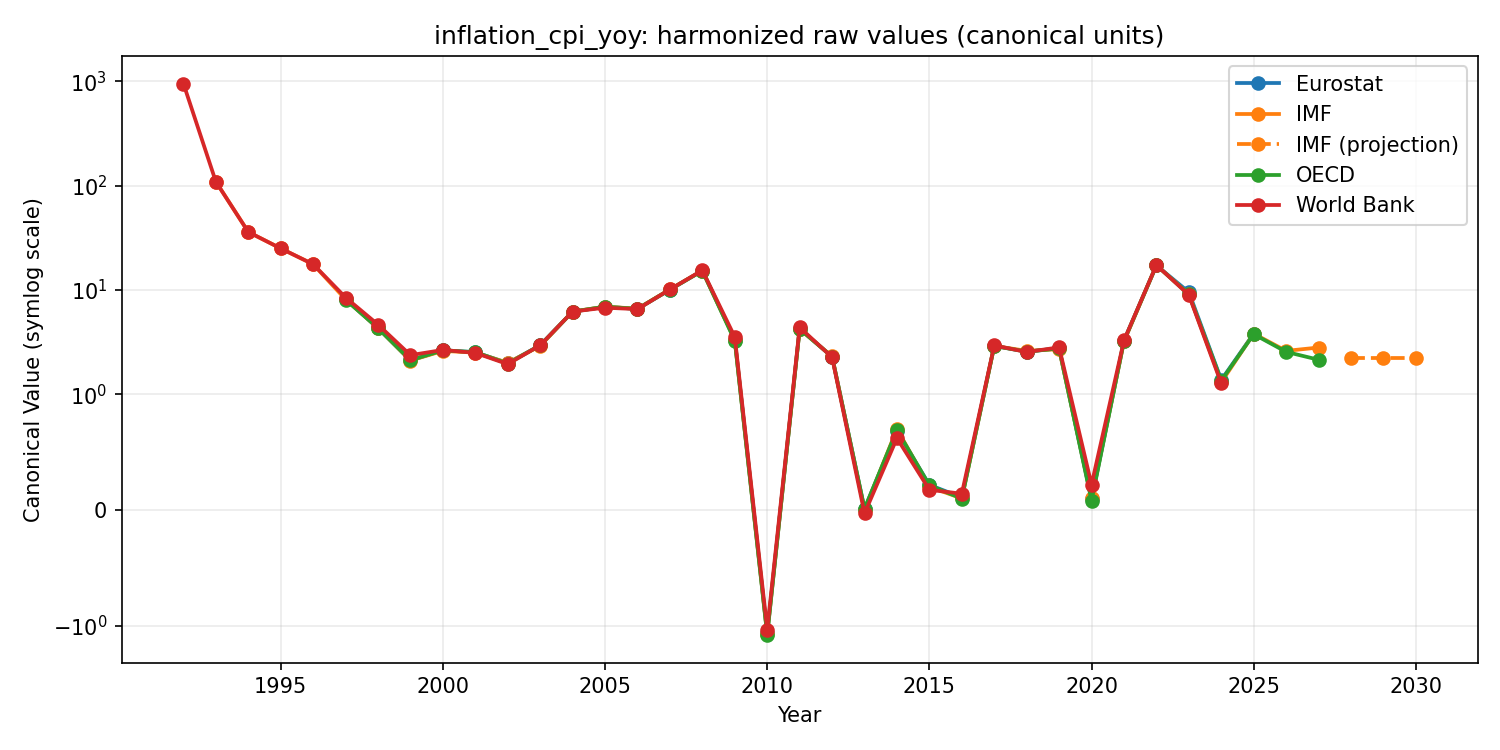

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Monetary conditions and interest rates

#### lending_interest_rate

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,2000.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


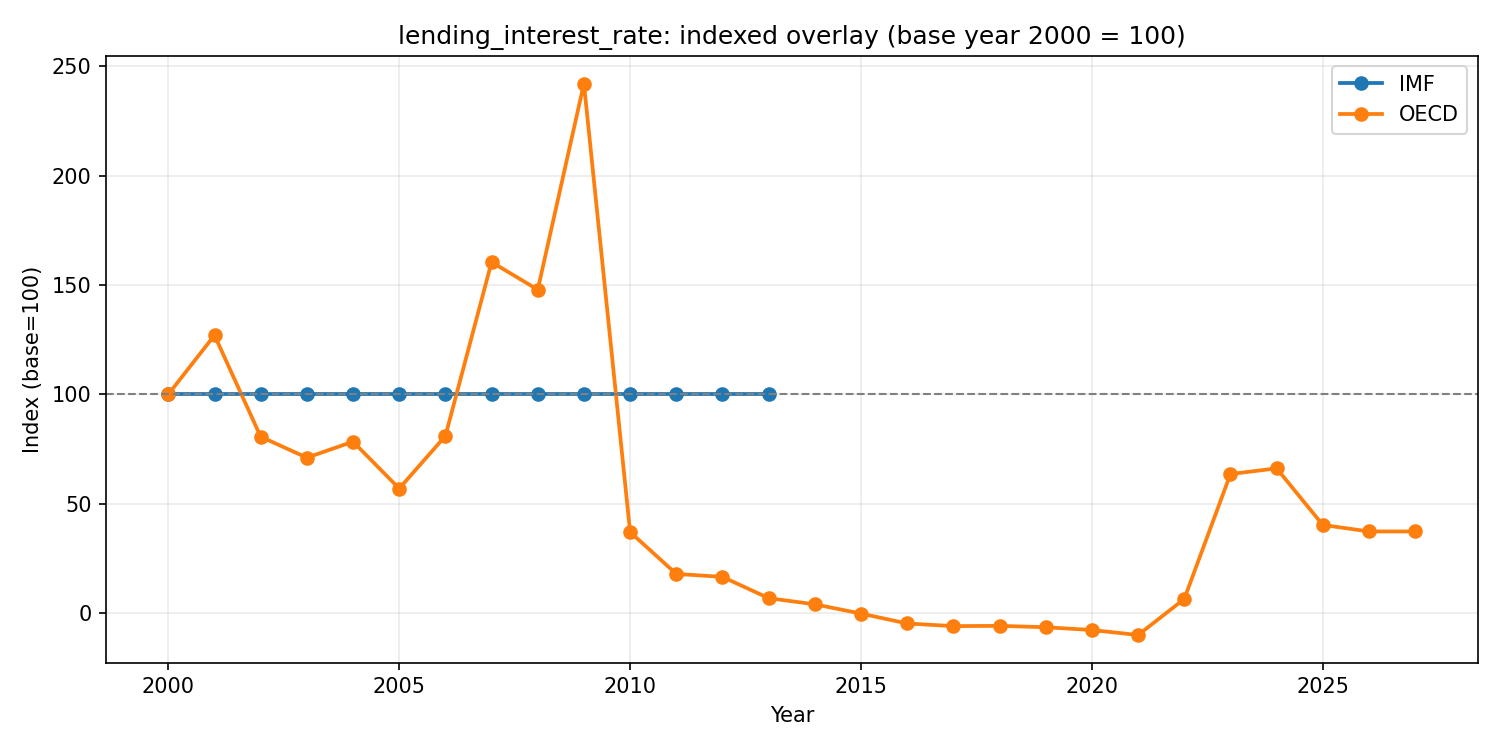

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`FR.INR.LEND`) | percent | percent | identity | Endpoint resolves but currently no numeric LT rows |
| IMF (`Ka_mm`) | index | percent (pipeline canonical target) | identity | Weak proxy; LT availability only to 2013 |
| Eurostat (`irt_lt_mcby_a`) | percent | percent | identity | Proxy (long-term rate, not direct lending rate) |
| OECD (`DSD_EO@DF_EO`, `IRS`) | percent | percent | identity | Proxy: short-term interest rate, not direct lending rate |

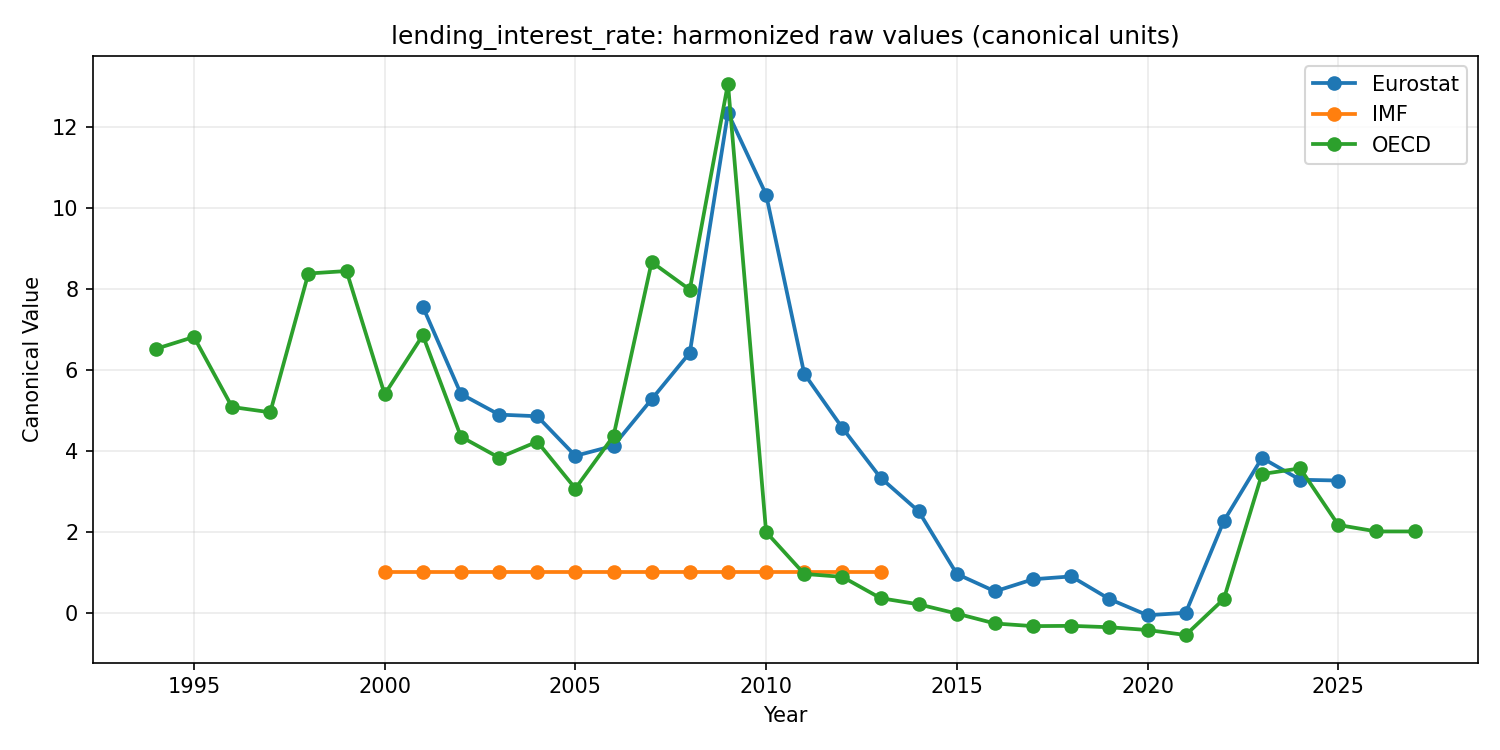

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Fiscal indicators

#### general_government_gross_debt_pct_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1998.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


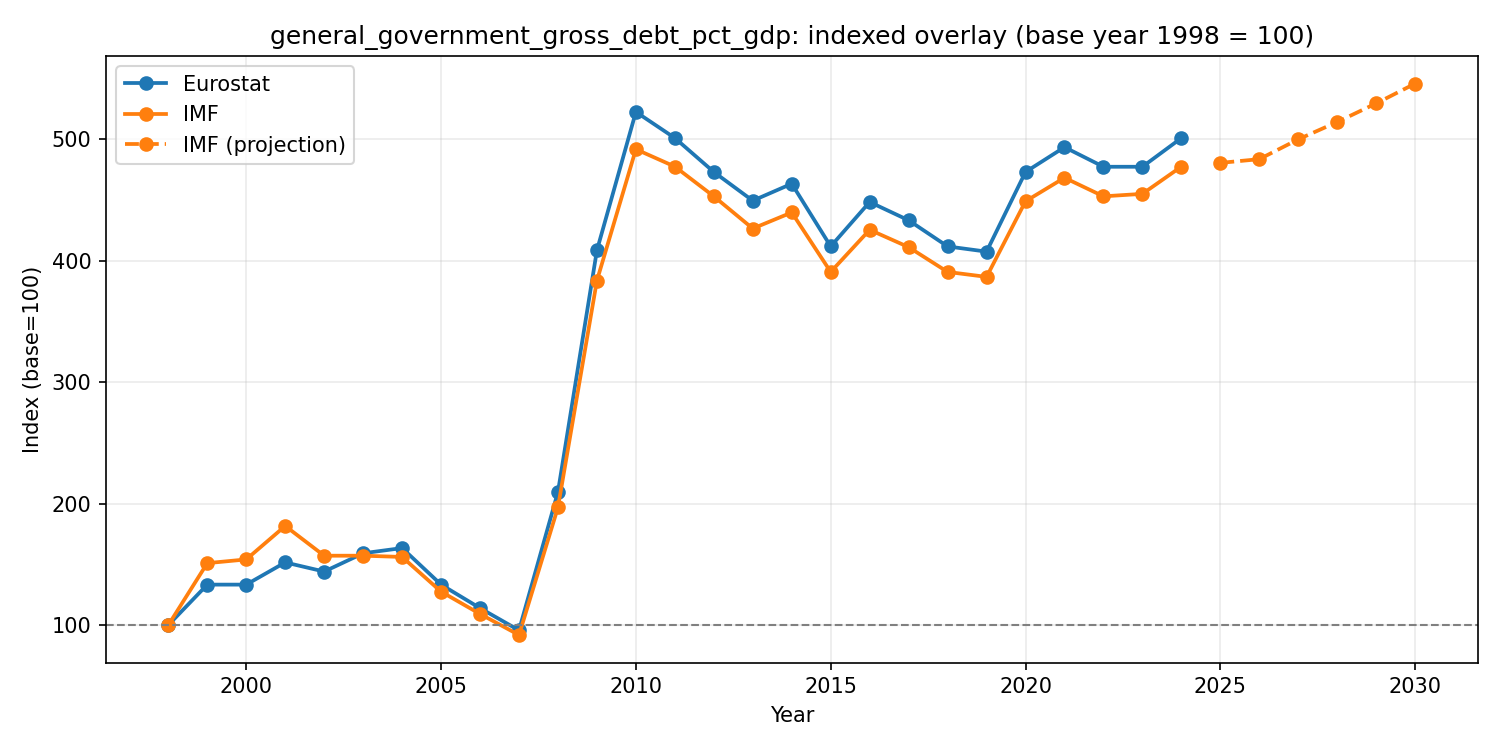

_Glossary:_ indexed comparison derived from harmonized comparable values.

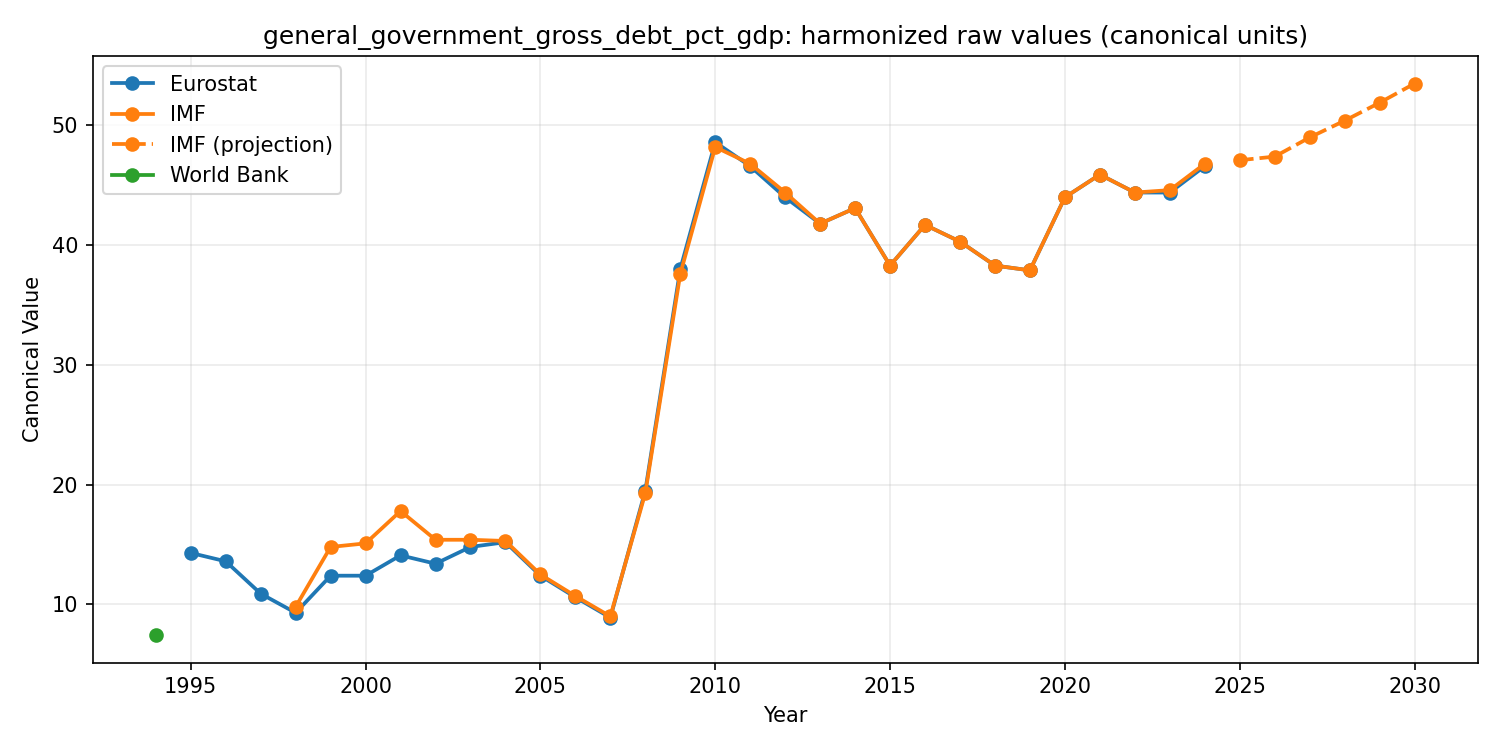

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### general_government_balance_deficit_pct_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,skipped,NaN,NaN,No overlap year with at least two sources.
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


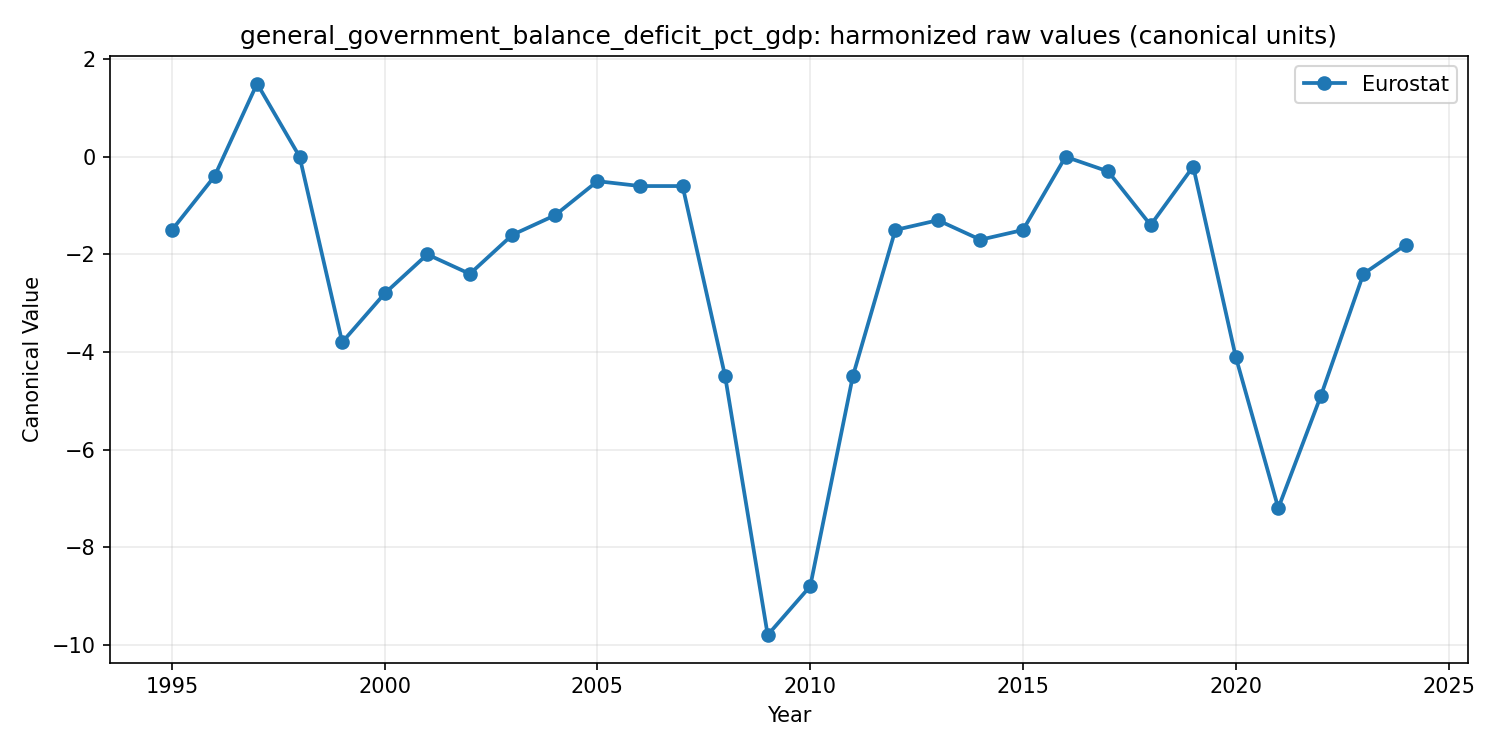

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### External sector indicators

#### trade_balance_pct_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


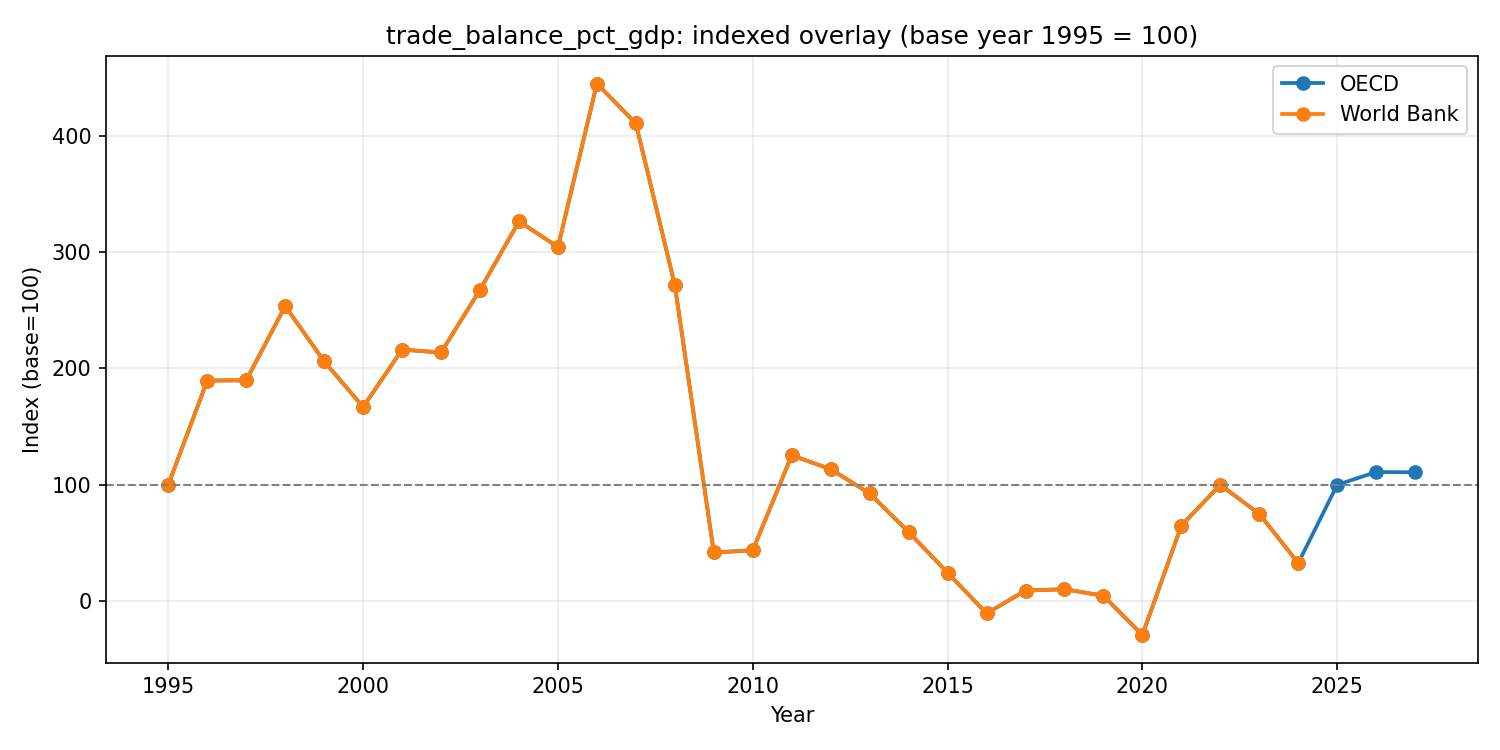

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NE.RSB.GNFS.ZS`) | percent of GDP | percent of GDP | identity | Exact mapping |
| IMF (`BT_GDP`) | source-defined | percent of GDP | identity | Proxy with potential definition differences |
| Eurostat (`bop_gdp6_q`) | `PC_GDP` | percent of GDP | identity | Proxy (BPM6 framing differs) |
| OECD (`DSD_EO@DF_EO`, `FBGSQ`) | percent of GDP | percent of GDP | identity | Proxy: net exports of goods/services as % GDP |

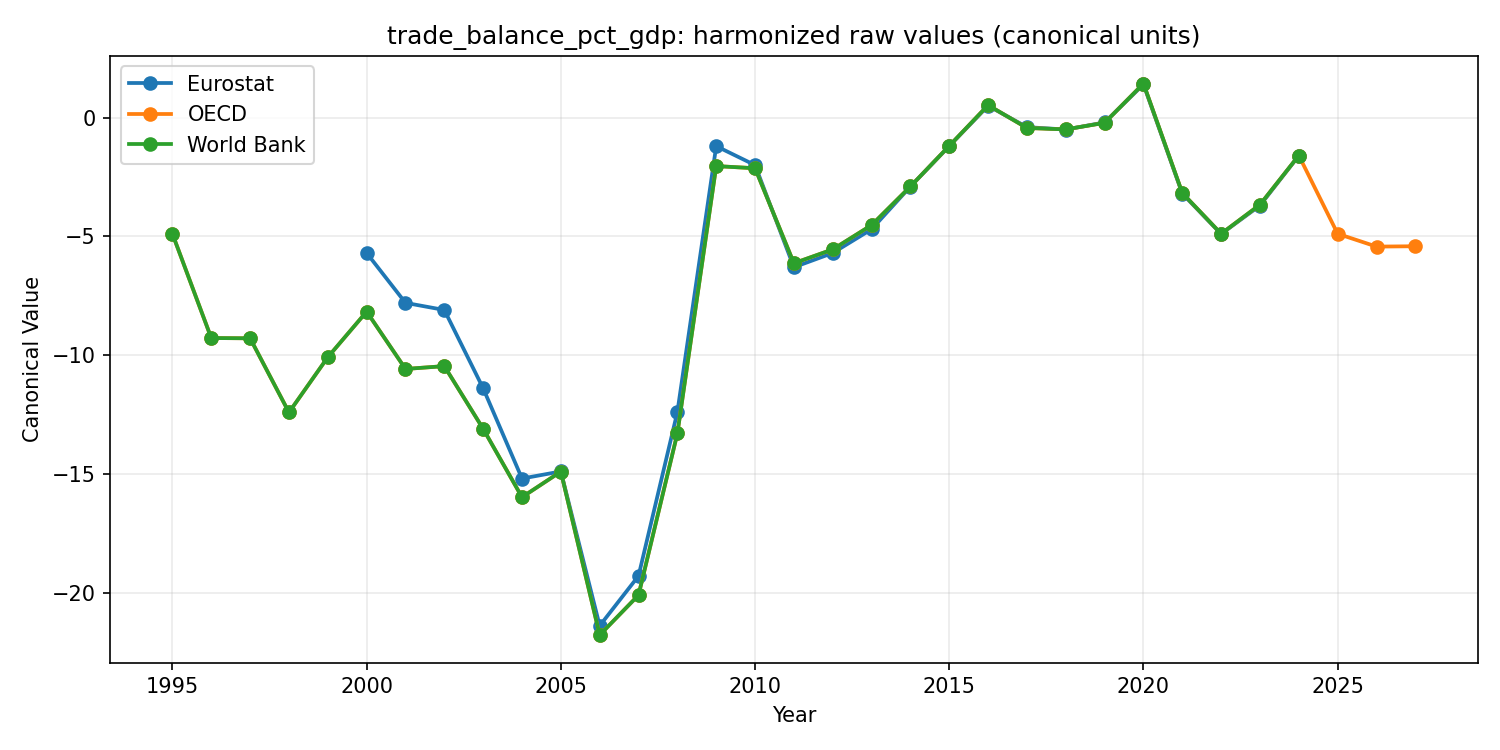

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### exchange_rate_lcu_per_usd

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


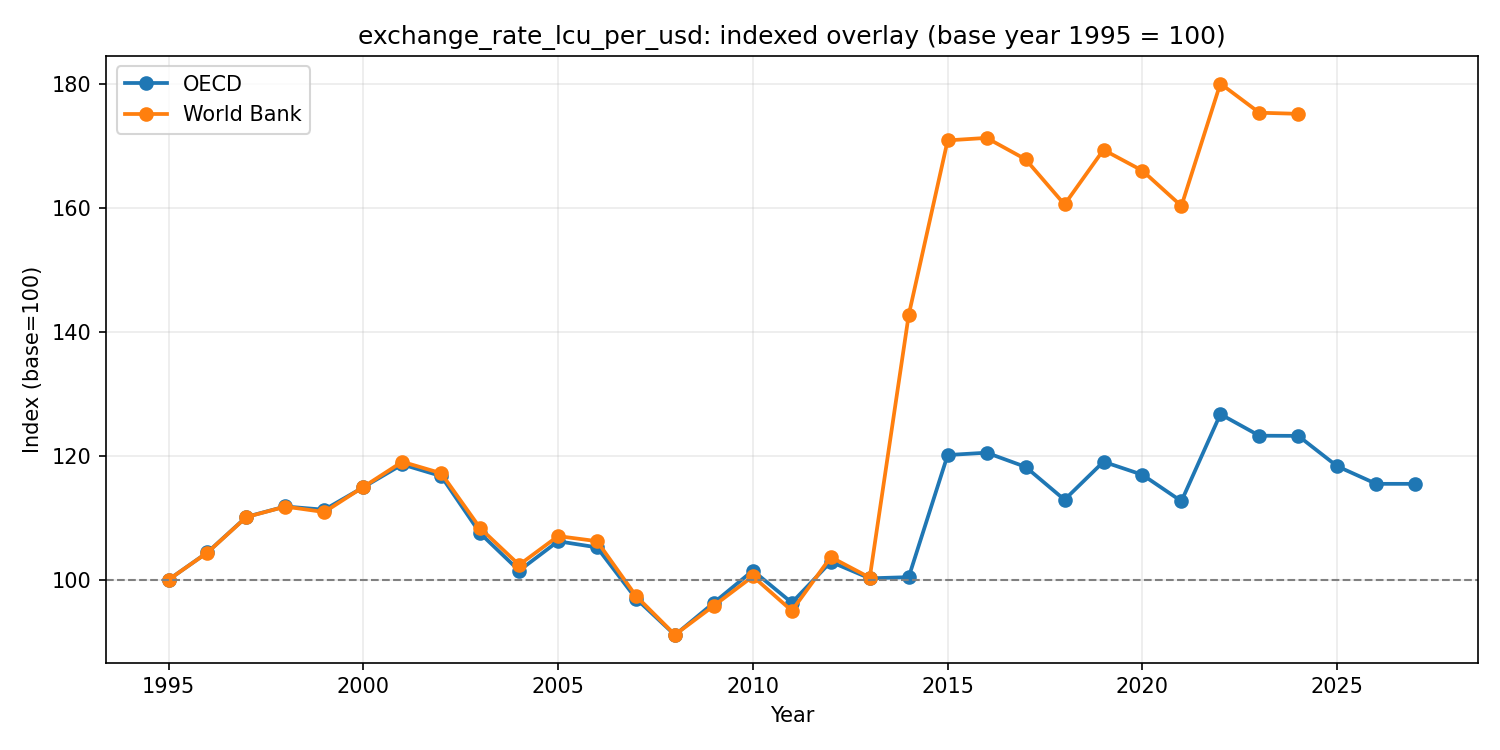

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`PA.NUS.FCRF`) | LCU per USD | LCU per USD | identity | Exact mapping |
| Eurostat raw (`ert_bil_eur_a`) | USD per EUR (`NAC`) | LCU per USD target | not directly comparable | Marked `is_comparable=false` for cross-source overlays |
| Eurostat derived (`eurostat_derived`) | derived from USD/EUR | LCU per USD | LT regime rules by year | Comparable series used in harmonized/overlay charts |
| OECD (`DSD_EO@DF_EO`, `EXCHUD`) | LCU per USD | LCU per USD | identity | Proxy: OECD EO exchange-rate conventions can differ by historical treatment |

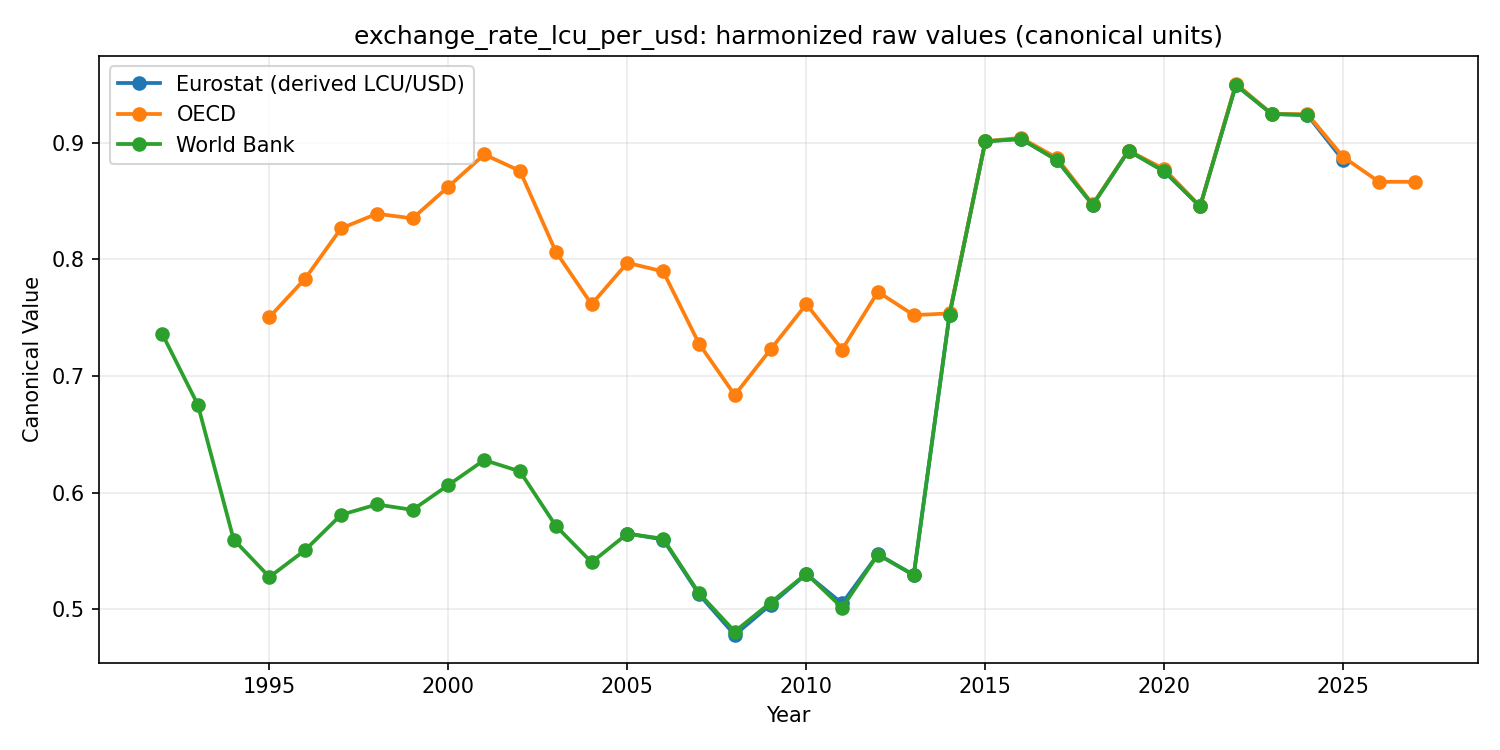

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Confidence and surveys

_No indicators mapped in current pipeline output._

## Static z-score visuals

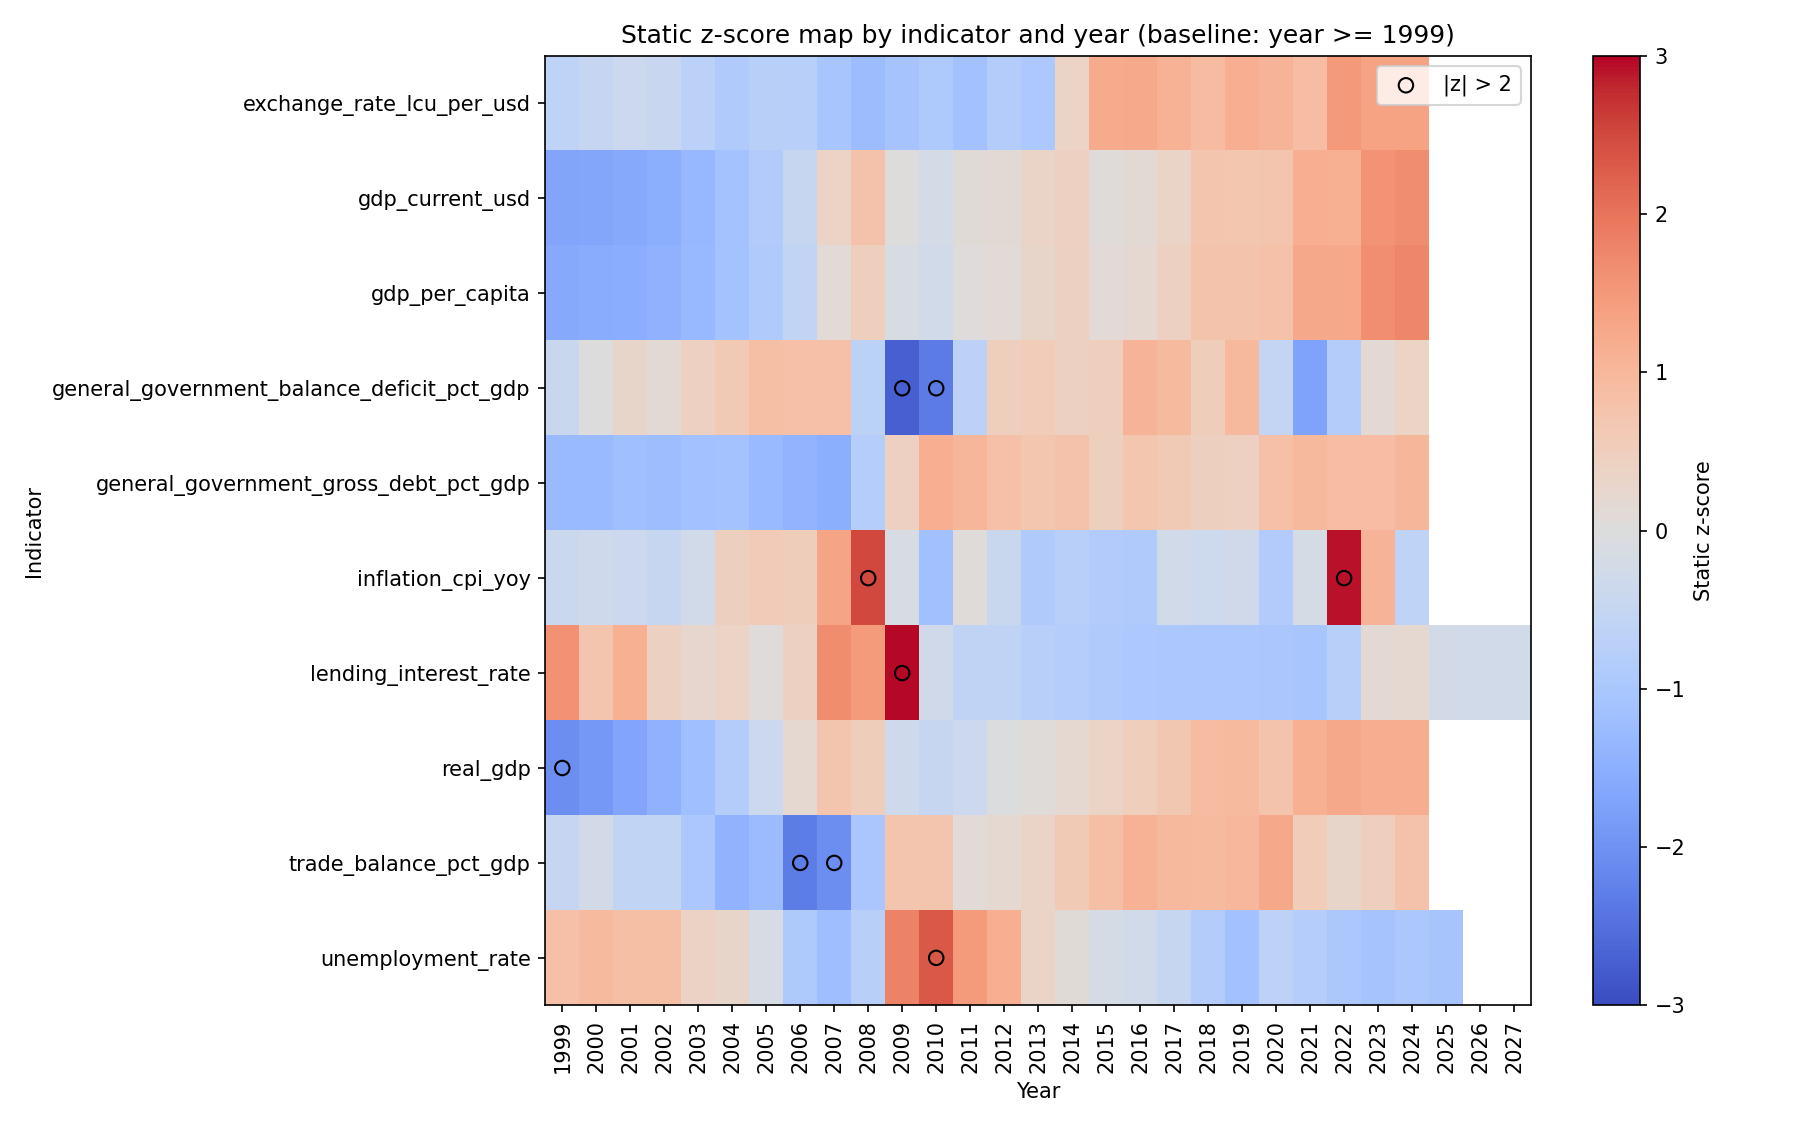

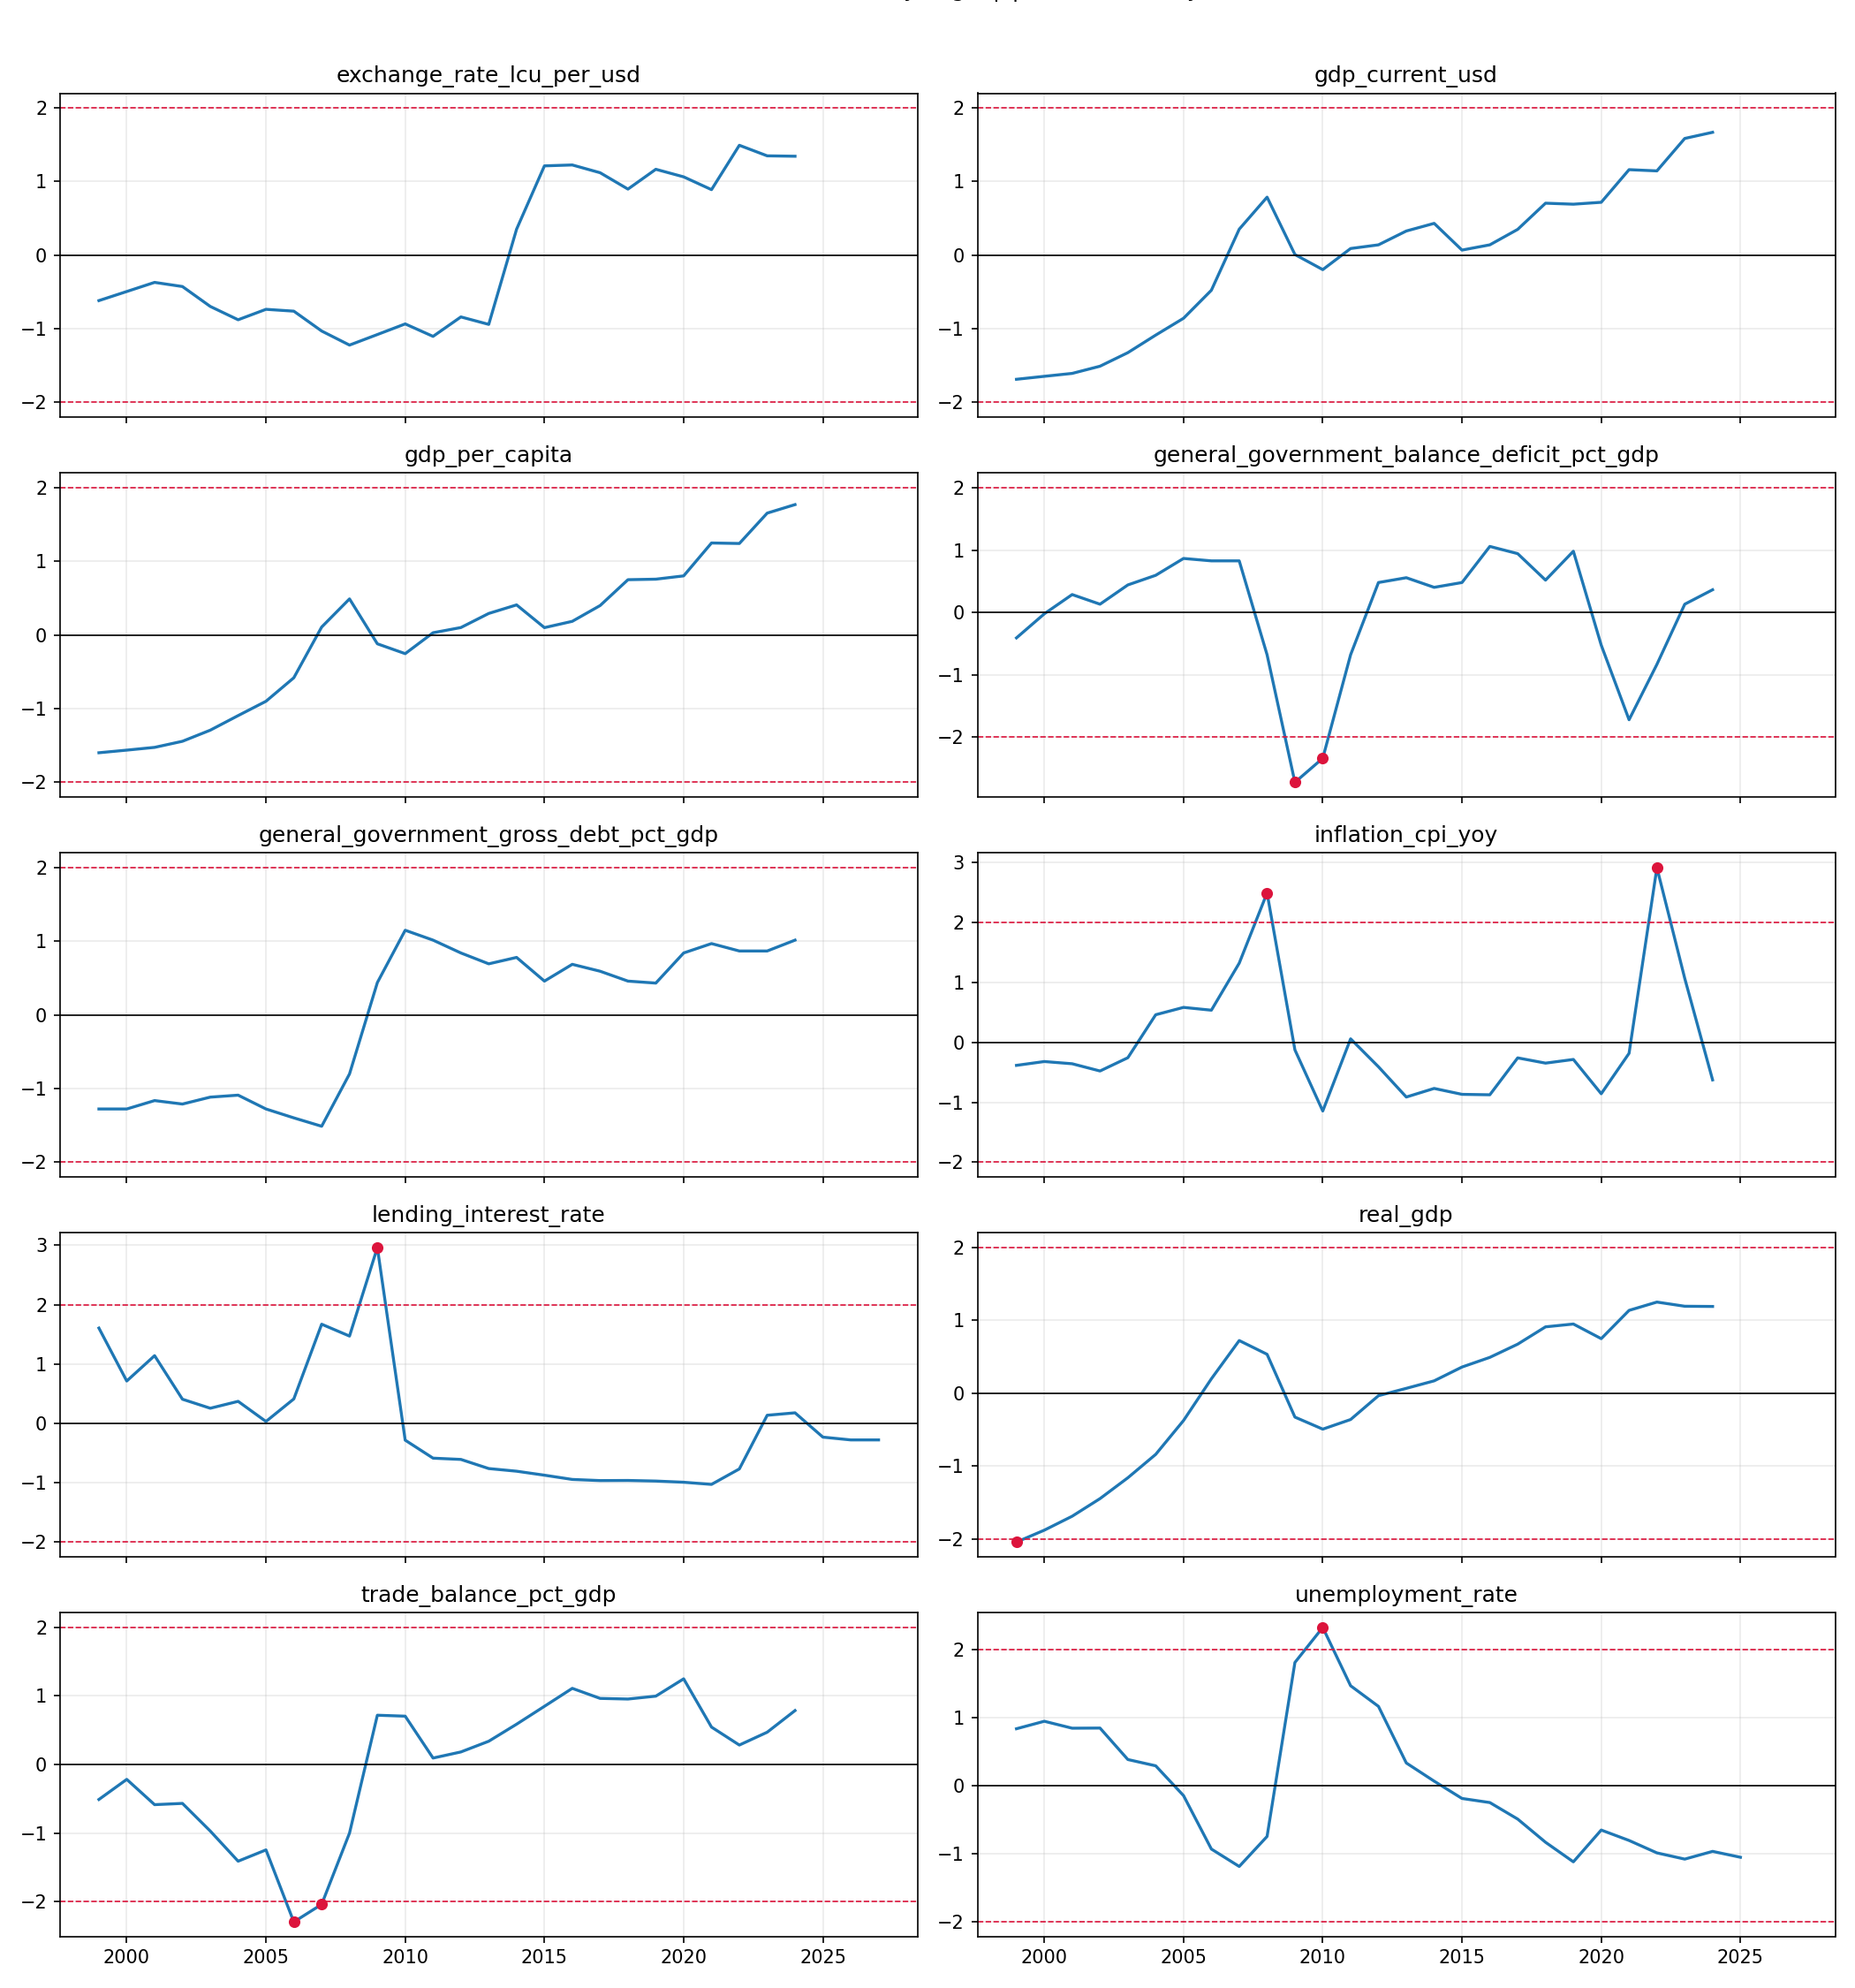

In [7]:
_lv_context = _render_country_section("LV")


## Estonia

Estonia uses the same pipeline outputs and compact chart profile as the other Baltic sections.


**Country code:** `EE`

**Country output directory:** `/workspaces/da-ai/bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics/EE`

## Diagnostics

### Coverage status counts

,status,count
0,missing_source,44
1,resolved,36
2,known_but_missing_params,20


...

,check_name,actual_value,target,status,details
0,all_indicators_have_two_or_more_sources,9,10,fail,Count of indicators meeting >=2 plot-ready sou...
1,indicator_general_government_balance_deficit_p...,1,>=2,fail,Per-indicator plot-ready source count.
2,indicator_exchange_rate_lcu_per_usd_sources,3,>=2,pass,Per-indicator plot-ready source count.
3,indicator_gdp_current_usd_sources,4,>=2,pass,Per-indicator plot-ready source count.
4,indicator_gdp_per_capita_sources,3,>=2,pass,Per-indicator plot-ready source count.
5,indicator_general_government_gross_debt_pct_gd...,2,>=2,pass,Per-indicator plot-ready source count.
6,indicator_inflation_cpi_yoy_sources,3,>=2,pass,Per-indicator plot-ready source count.
7,indicator_lending_interest_rate_sources,3,>=2,pass,Per-indicator plot-ready source count.
8,indicator_real_gdp_sources,2,>=2,pass,Per-indicator plot-ready source count.
9,indicator_trade_balance_pct_gdp_sources,2,>=2,pass,Per-indicator plot-ready source count.


## Indicator charts

### Output and growth

#### real_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


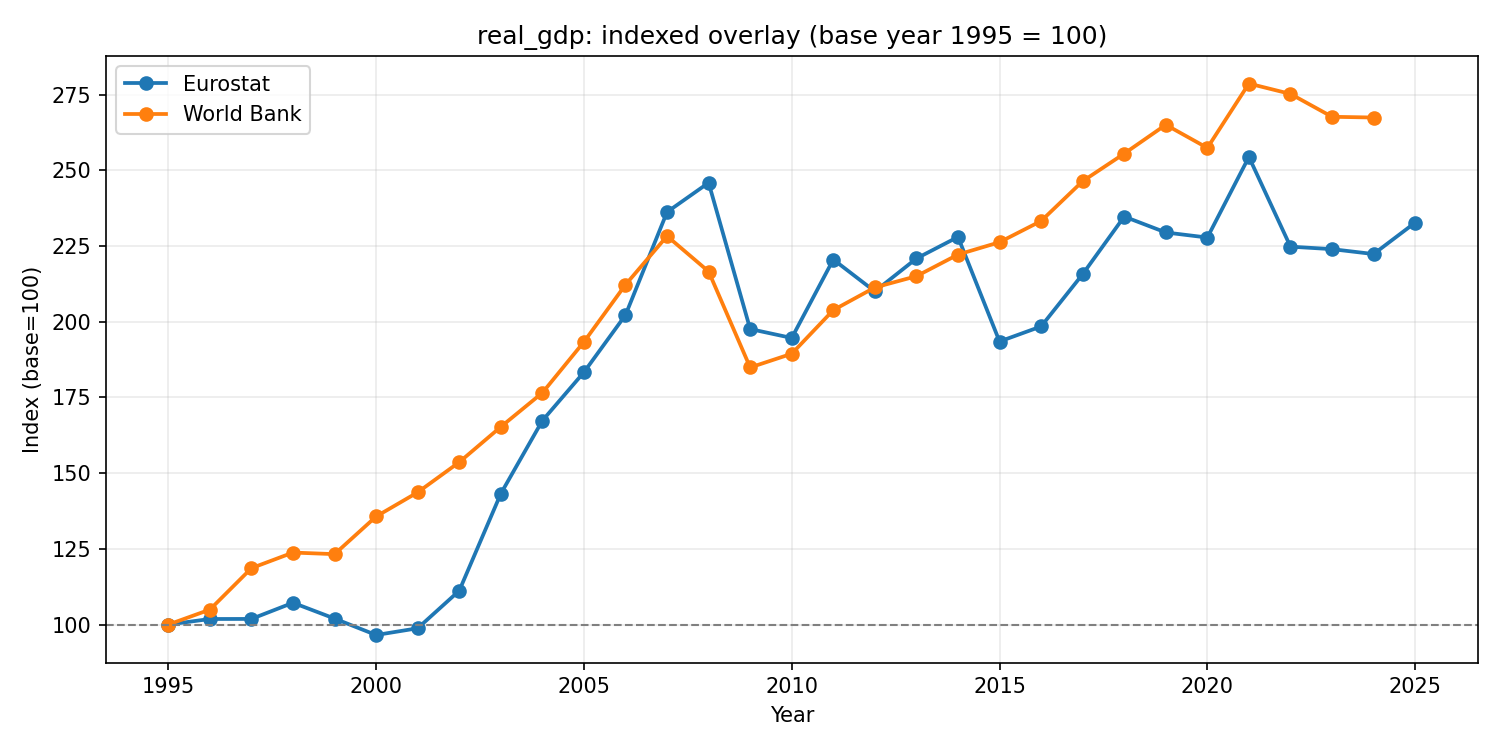

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.MKTP.KD`) | constant USD | `USD` | `value_canonical = value_raw` | Exact mapping (constant-price GDP in USD) |
| IMF (`NGDP_R`) | source-defined | `USD` | `value_canonical = value_raw` | Proxy; source unit conventions may differ |
| Eurostat (`nama_10_gdp`, `CLV10_MEUR`) | million EUR (chain-linked volumes, 2010 ref) | `USD` | `value_canonical = value_raw * 1e6 * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series; constant-price methodology differs from other sources |
| OECD (`DSD_EO@DF_EO`, `GDP_USD`) | `USD` | `USD` | `value_canonical = value_raw` | Proxy: OECD EO GDP is in USD at constant exchange rates |

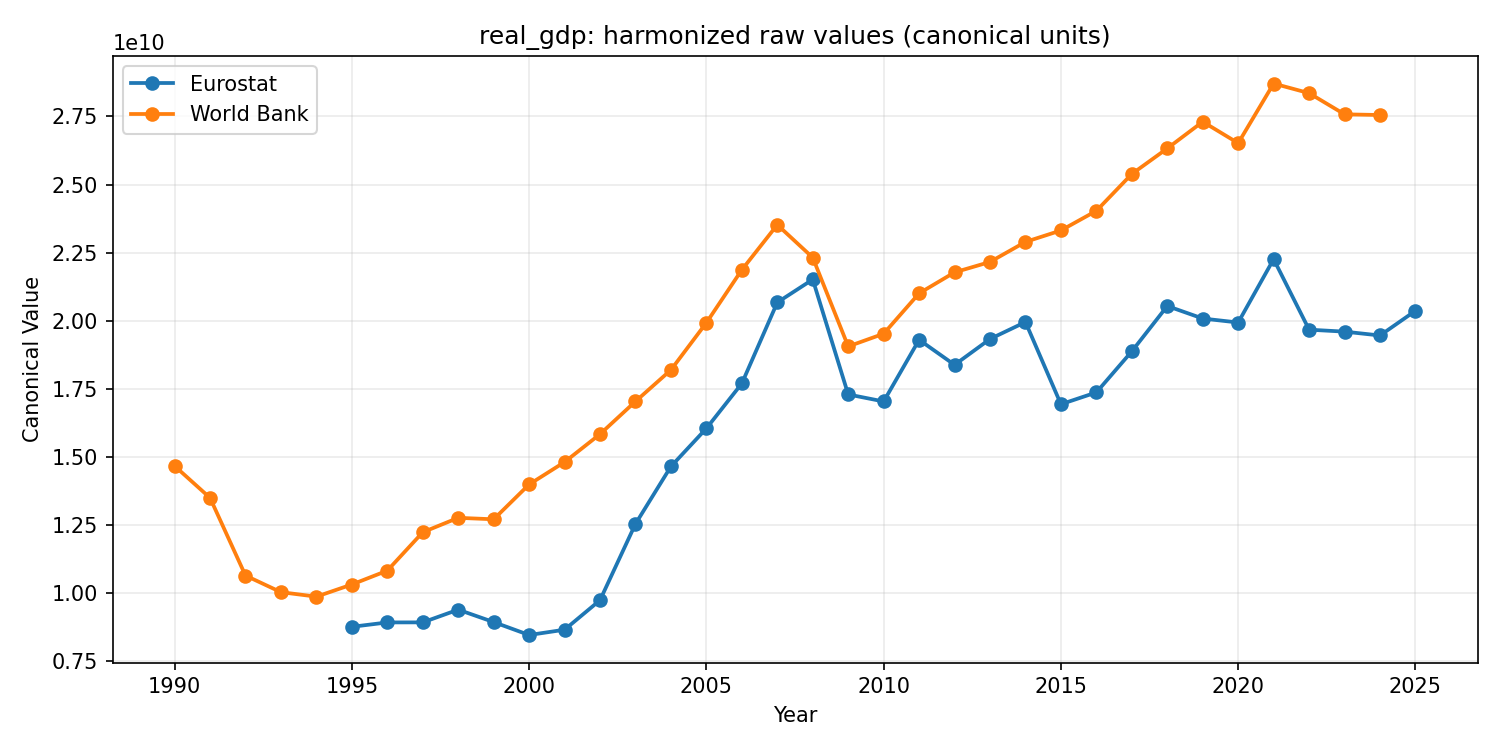

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### gdp_current_usd

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1993.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


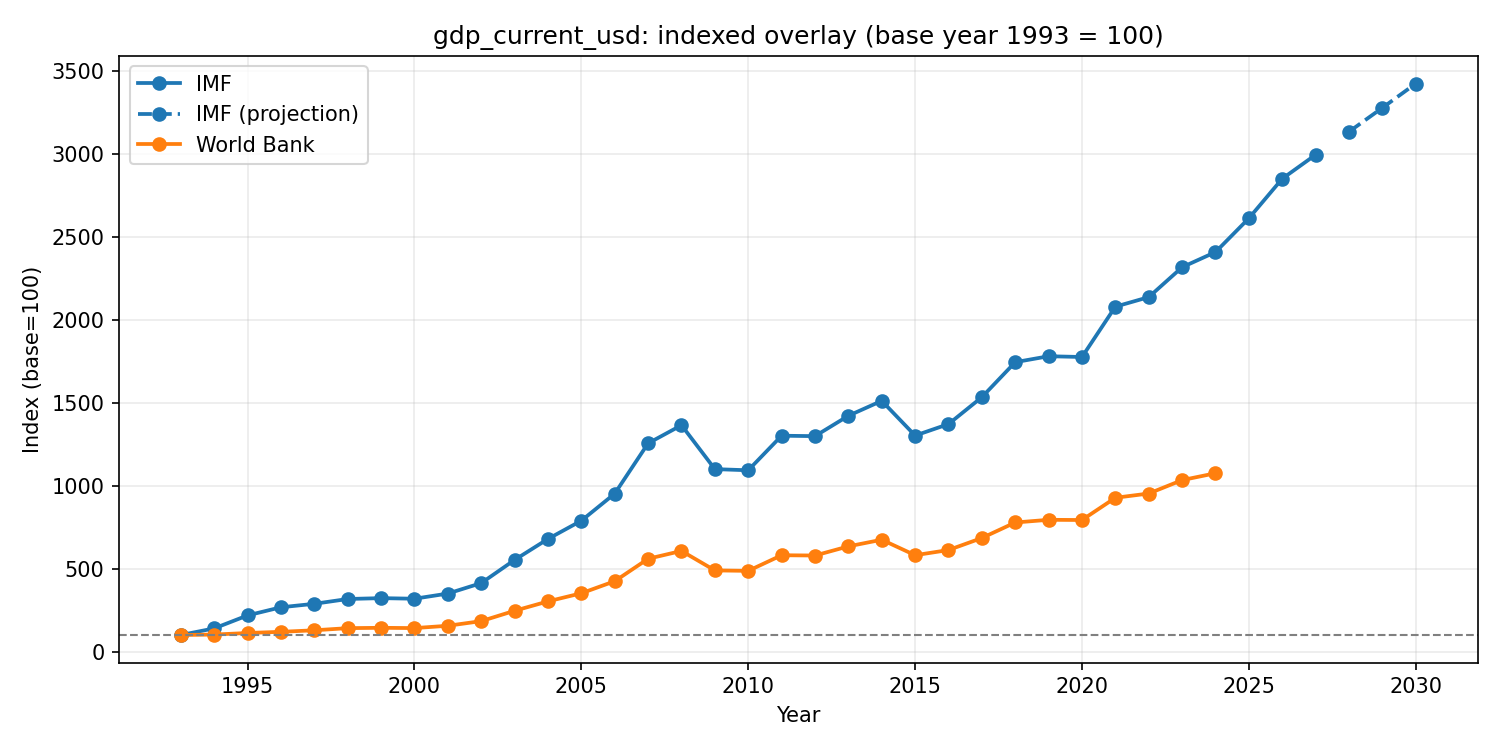

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.MKTP.CD`) | `USD` | `USD` | `value_canonical = value_raw` | Exact mapping |
| IMF (`NGDPD`) | source-defined | `USD` | `value_canonical = value_raw * 1e9` | WEO-backed; future years are projection-flagged |
| Eurostat (`nama_10_gdp`, `CP_MEUR`) | million EUR | `USD` | `value_canonical = value_raw * 1e6 * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series |
| OECD (`DSD_EO@DF_EO`, `GDP_USD`) | `USD` | `USD` | `value_canonical = value_raw` | Proxy: OECD EO GDP is in USD at constant exchange rates (not WB current US$) |

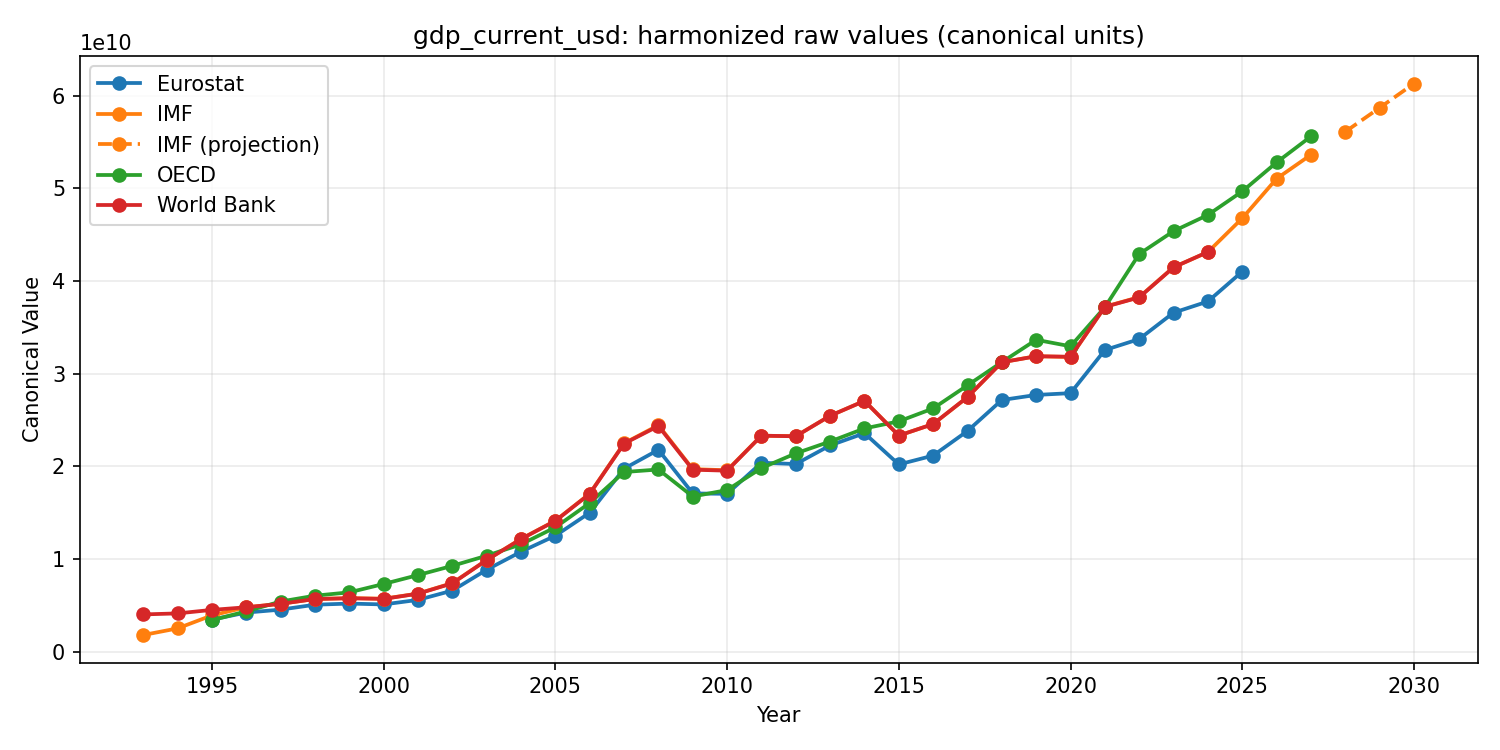

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### gdp_per_capita

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1993.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


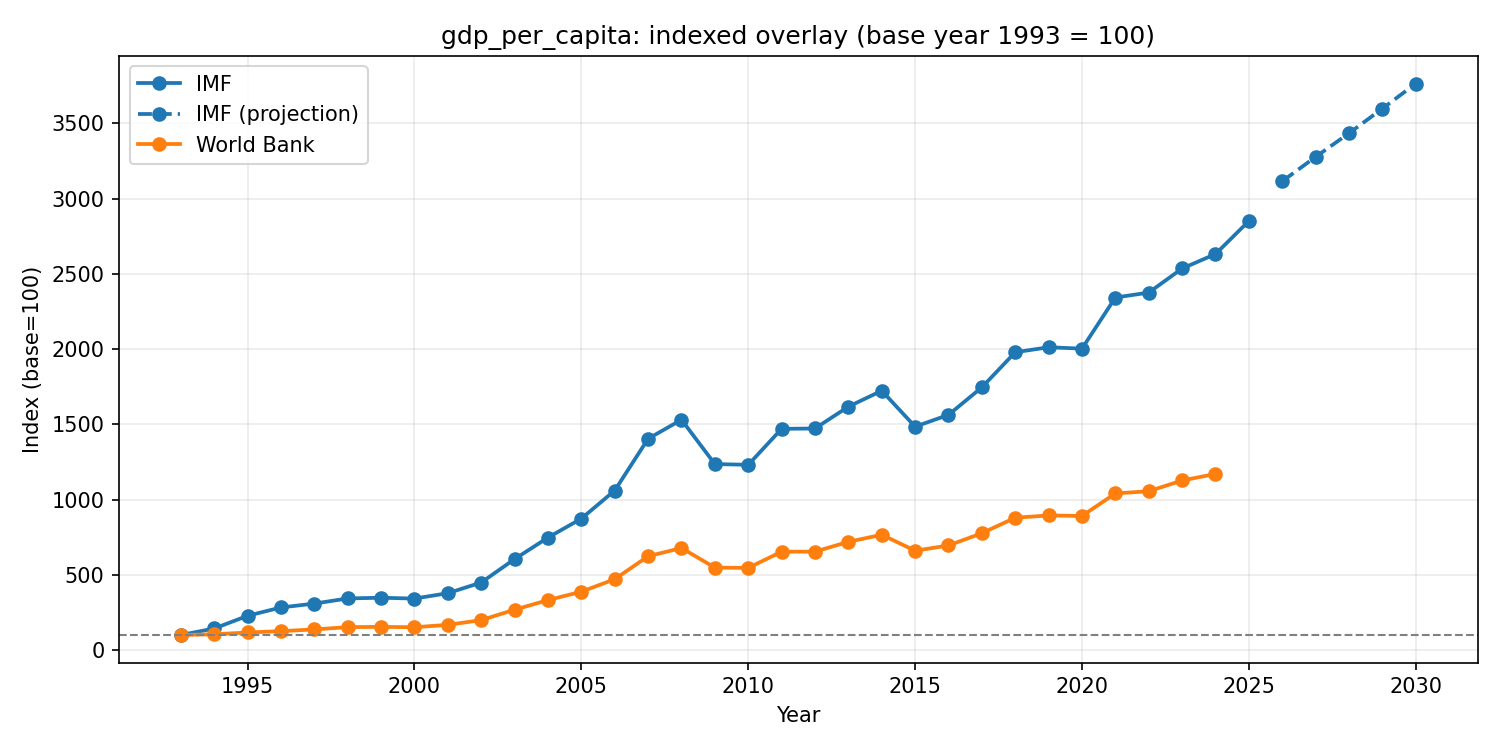

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.PCAP.CD`) | USD per capita | USD per capita | identity | Exact mapping |
| IMF (`NGDPDPC`) | source-defined | USD per capita | identity | WEO-backed; future years are projection-flagged |
| Eurostat (`nama_10_pc`, `CP_EUR_HAB`) | EUR per inhabitant | USD per capita | `value_canonical = value_raw * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series |

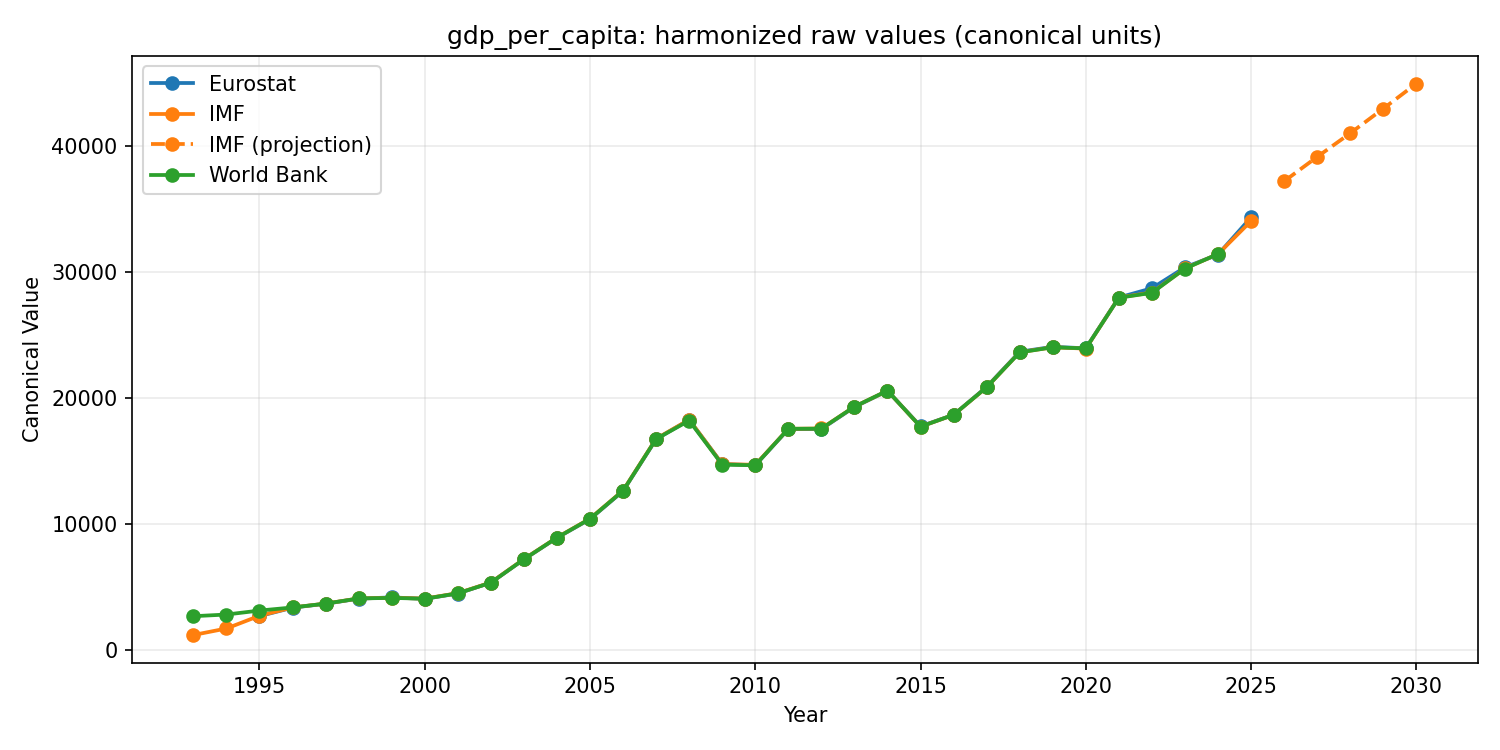

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Labor market

#### unemployment_rate

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1993.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


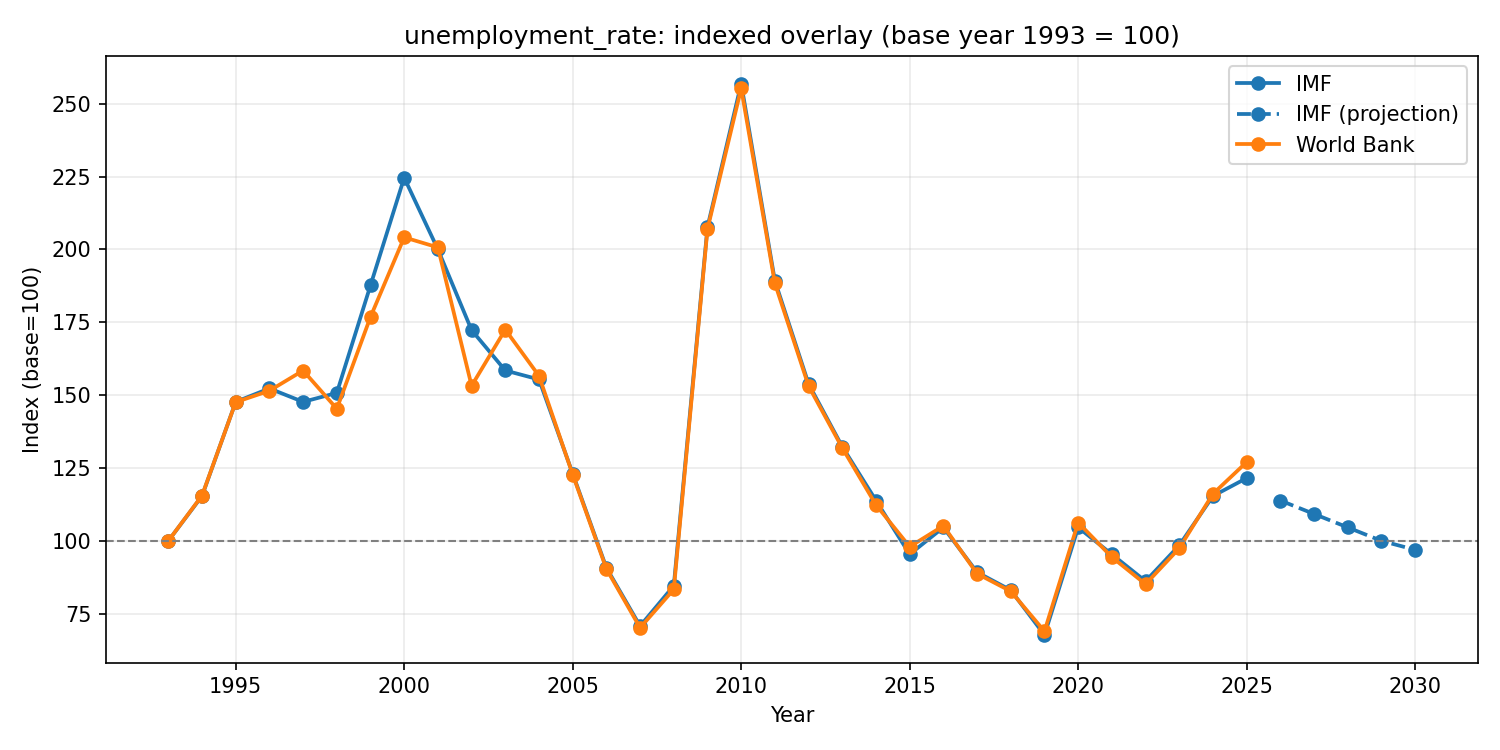

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`SL.UEM.TOTL.ZS`) | percent | percent | identity | Exact mapping |
| IMF (`LUR`) | source-defined | percent | identity | Comparable concept; possible projection years |
| Eurostat (`une_rt_a`) | `PC_ACT` | percent | identity | Proxy (methodology differences) |
| OECD (`DSD_EO@DF_EO`, `UNR`) | percent | percent | identity | Comparable unemployment concept from OECD EO |

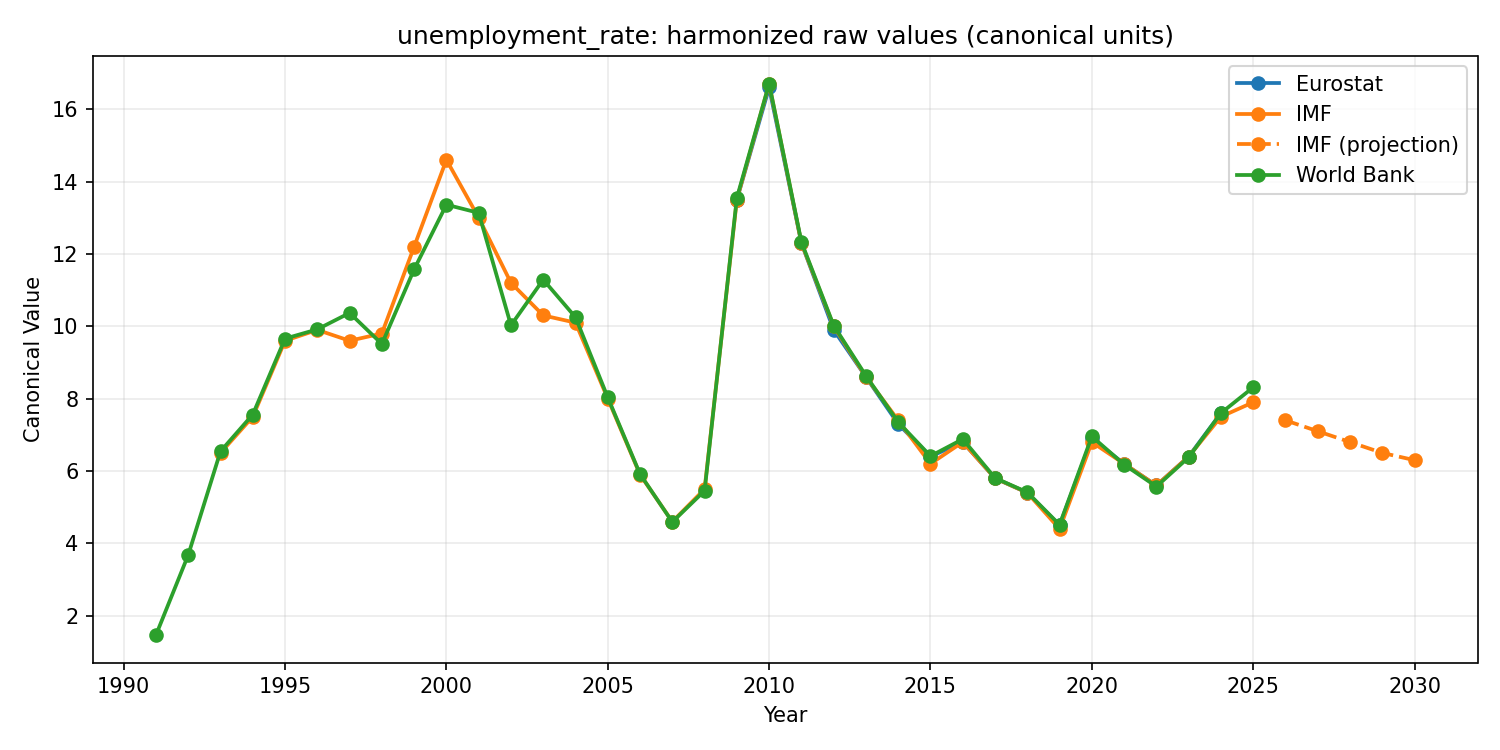

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Inflation and prices

#### inflation_cpi_yoy

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1997.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


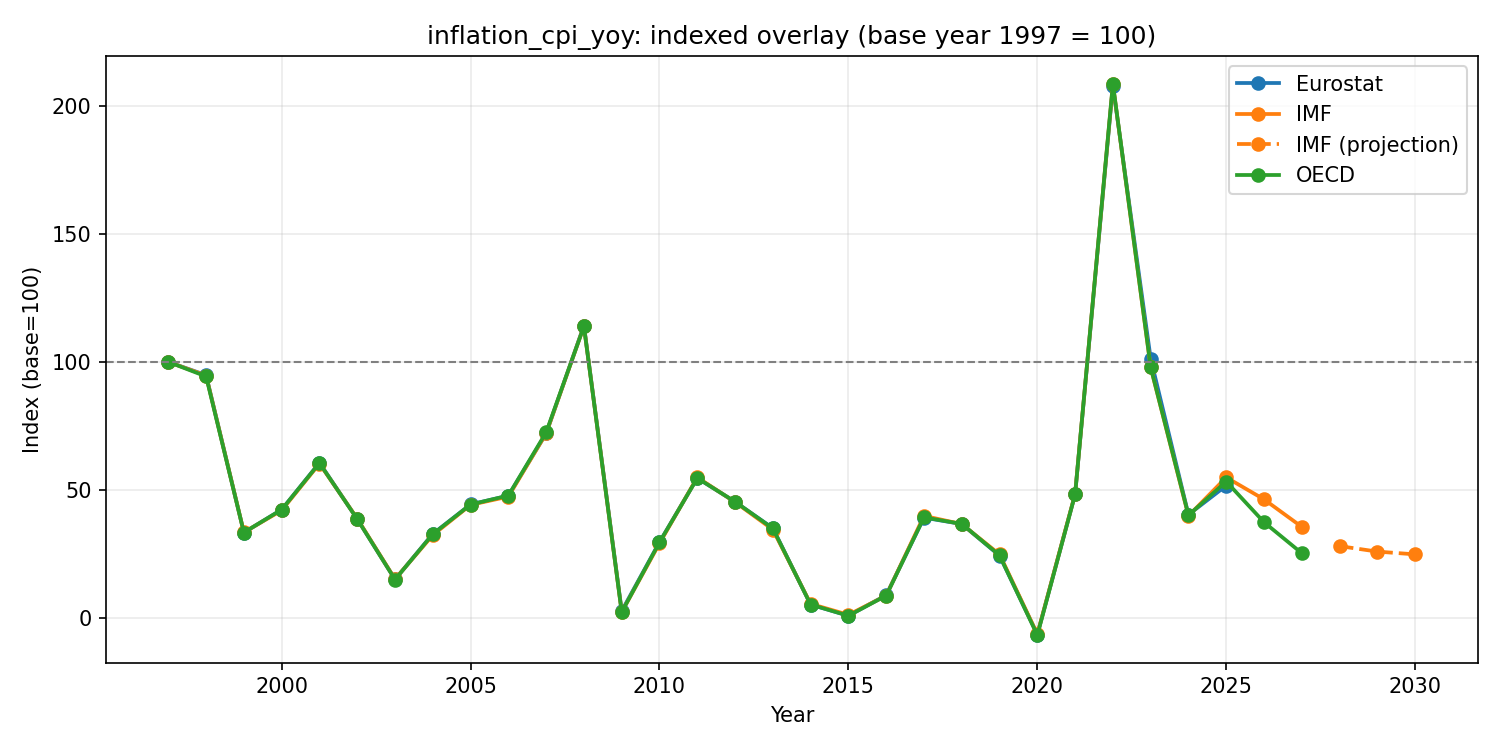

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`FP.CPI.TOTL.ZG`) | percent | percent | identity | Exact mapping |
| IMF (`PCPIPCH`) | source-defined | percent | identity | Proxy-equivalent concept; future years can be projections |
| Eurostat (`prc_hicp_manr`) | `RCH_A` monthly YoY | percent annual | annual mean of monthly values | Proxy with methodology differences |
| OECD (`DSD_EO@DF_EO`, `CPIH_YTYPCT`) | percent | percent | identity | Proxy: harmonised CPI annual inflation rate |

Chart rendering note: `inflation_cpi_yoy` raw and raw-harmonized charts use a logarithmic y-axis; if any non-positive values exist, the axis falls back to `symlog`.

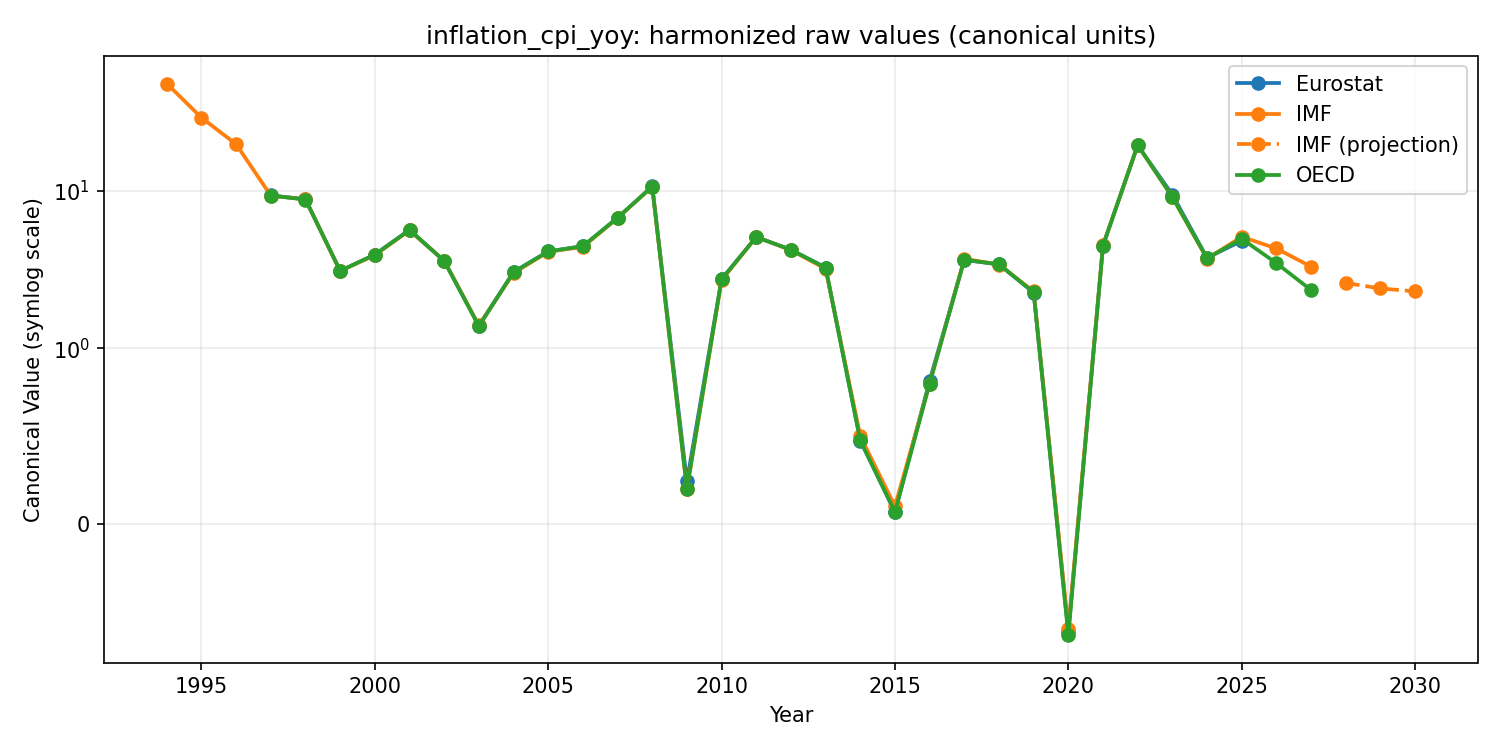

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Monetary conditions and interest rates

#### lending_interest_rate

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,2000.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


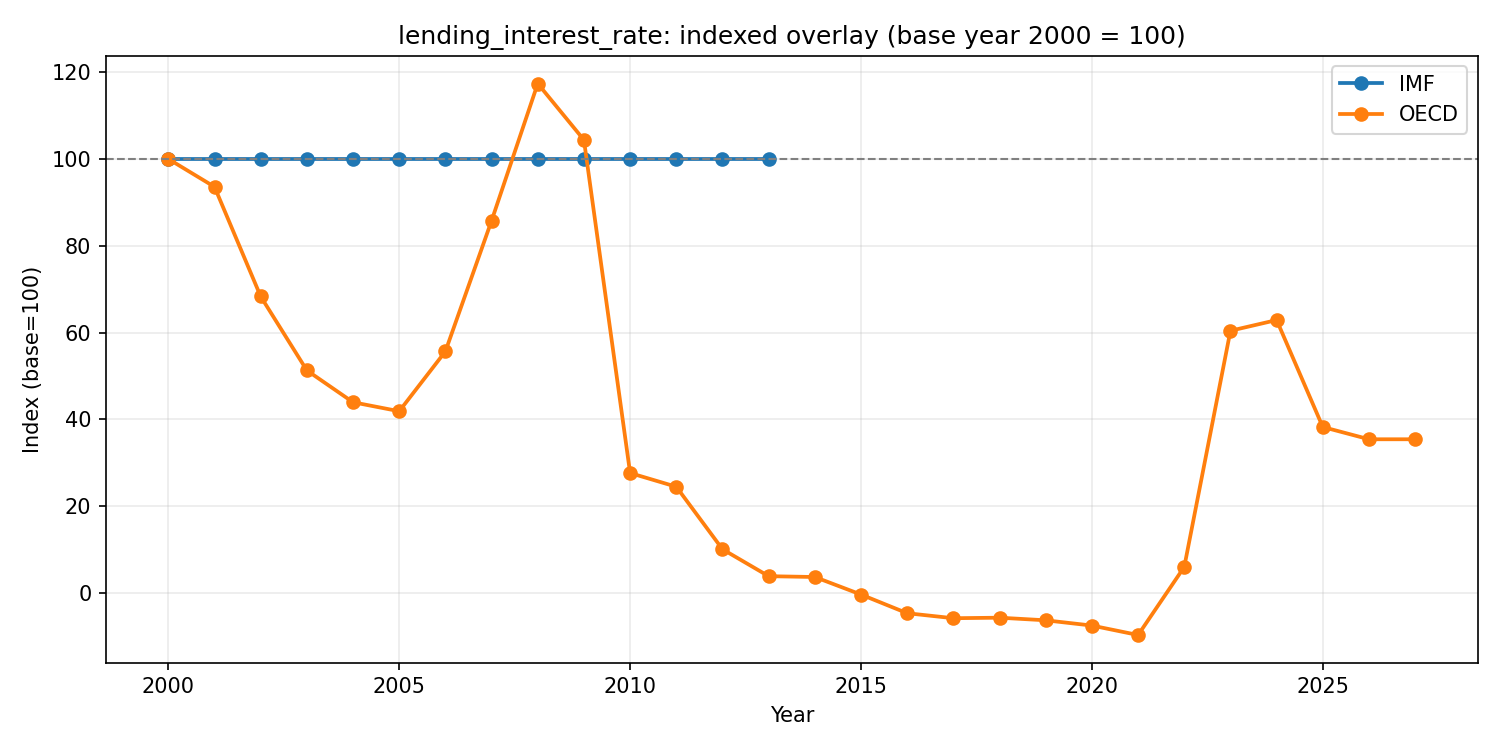

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`FR.INR.LEND`) | percent | percent | identity | Endpoint resolves but currently no numeric LT rows |
| IMF (`Ka_mm`) | index | percent (pipeline canonical target) | identity | Weak proxy; LT availability only to 2013 |
| Eurostat (`irt_lt_mcby_a`) | percent | percent | identity | Proxy (long-term rate, not direct lending rate) |
| OECD (`DSD_EO@DF_EO`, `IRS`) | percent | percent | identity | Proxy: short-term interest rate, not direct lending rate |

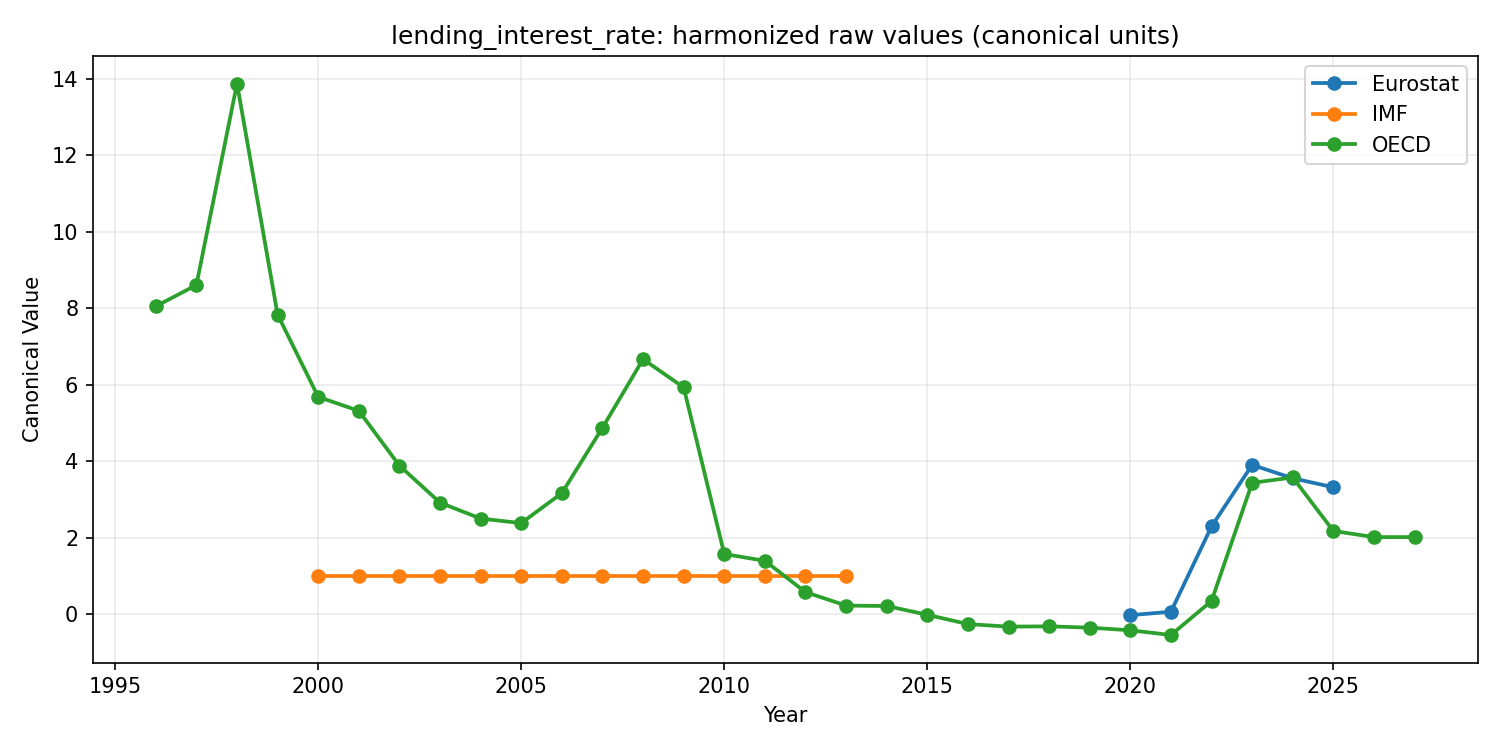

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Fiscal indicators

#### general_government_gross_debt_pct_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


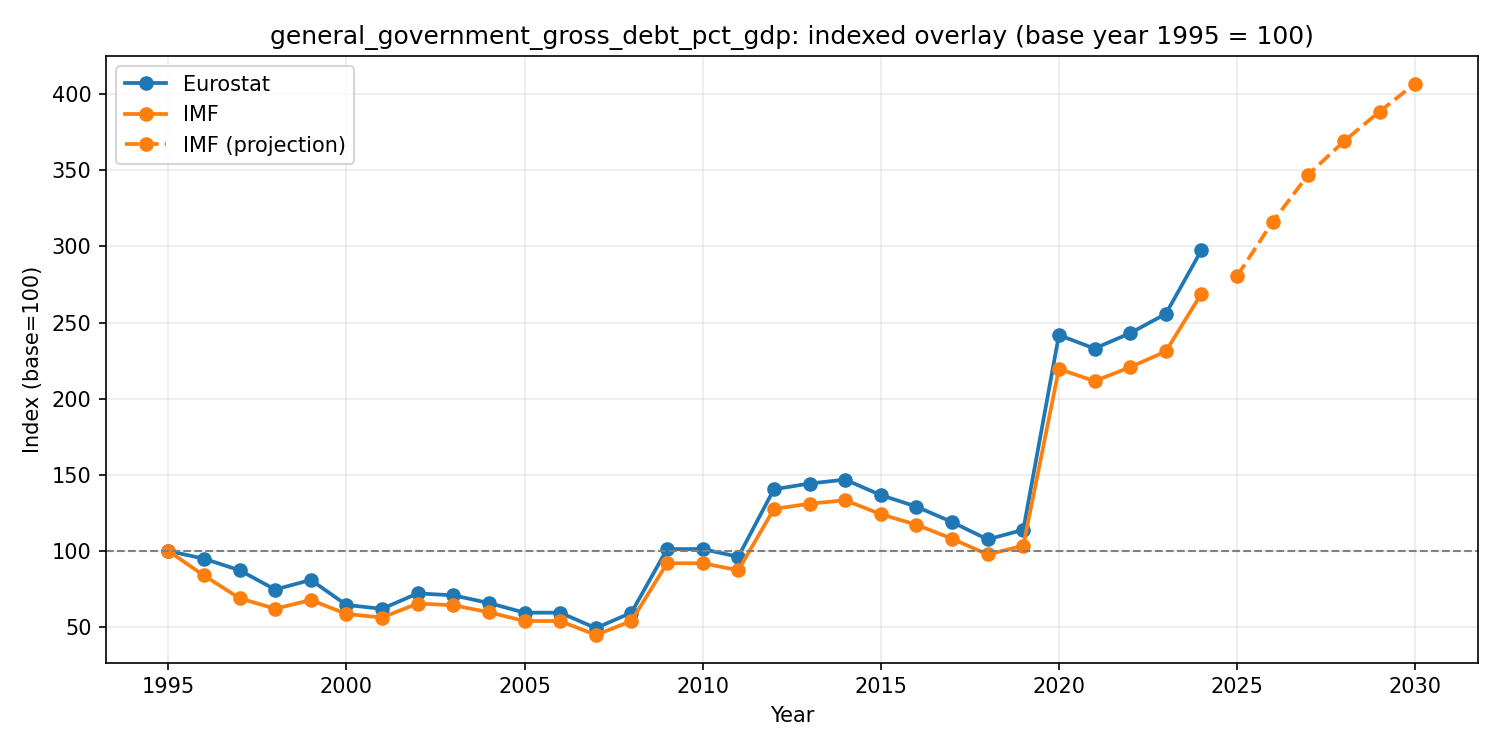

_Glossary:_ indexed comparison derived from harmonized comparable values.

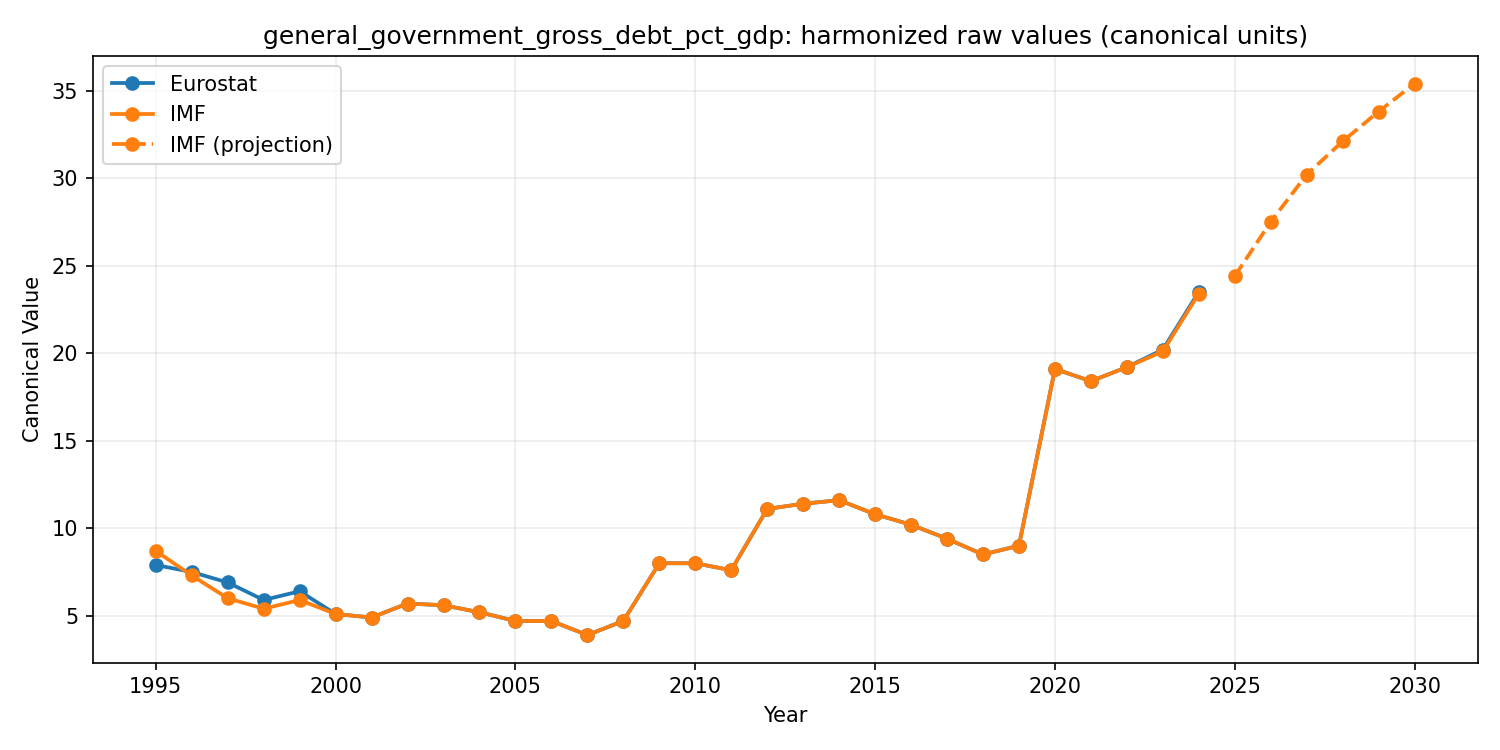

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### general_government_balance_deficit_pct_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,skipped,NaN,NaN,No overlap year with at least two sources.
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


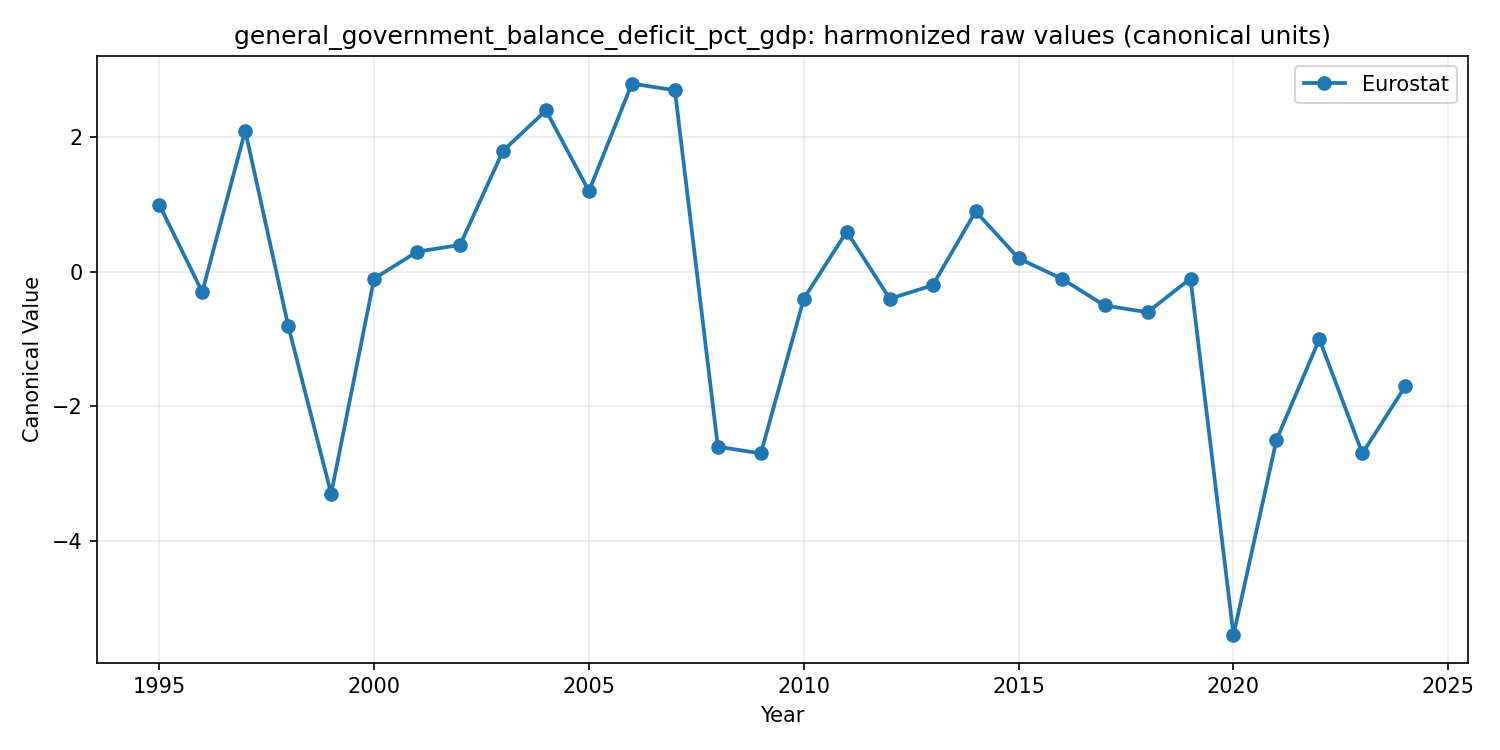

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### External sector indicators

#### trade_balance_pct_gdp

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


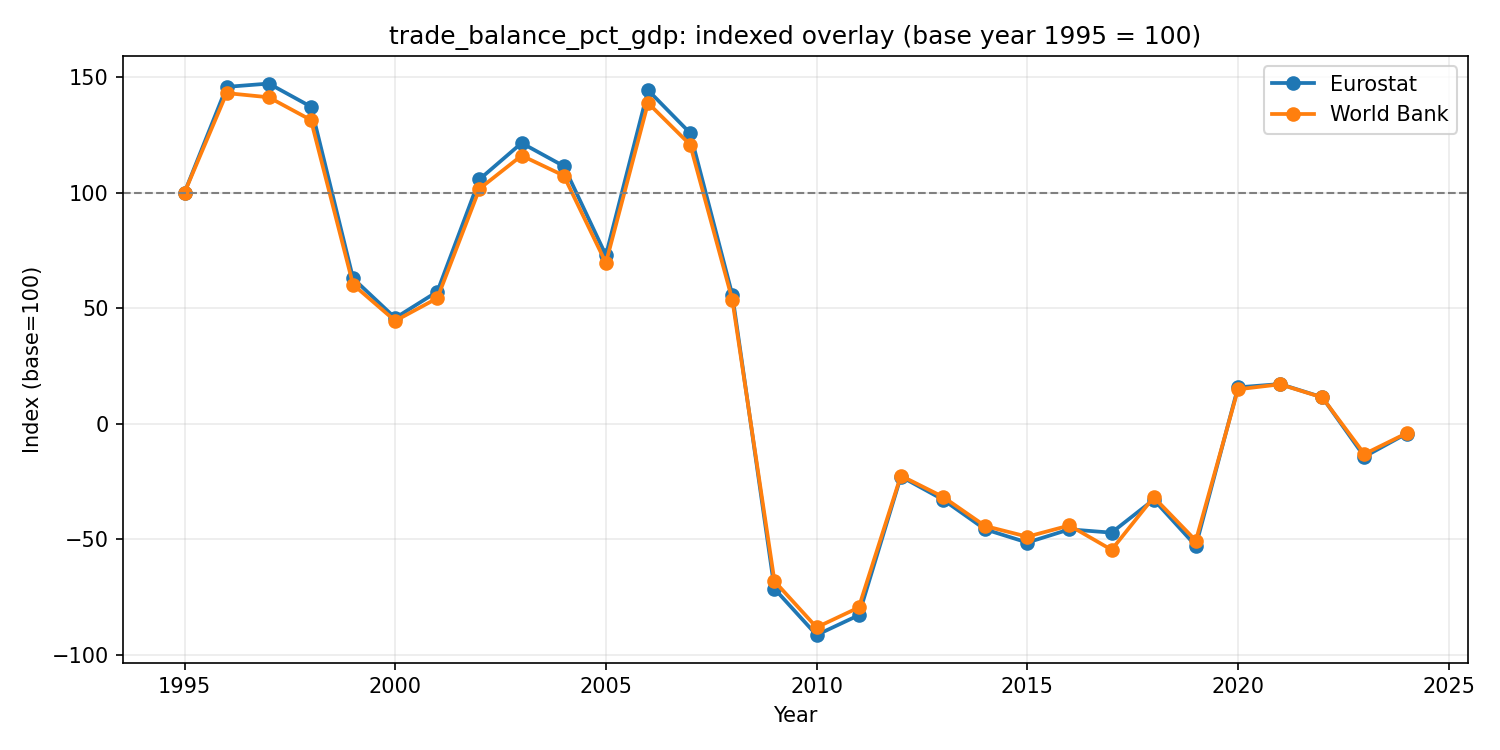

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NE.RSB.GNFS.ZS`) | percent of GDP | percent of GDP | identity | Exact mapping |
| IMF (`BT_GDP`) | source-defined | percent of GDP | identity | Proxy with potential definition differences |
| Eurostat (`bop_gdp6_q`) | `PC_GDP` | percent of GDP | identity | Proxy (BPM6 framing differs) |
| OECD (`DSD_EO@DF_EO`, `FBGSQ`) | percent of GDP | percent of GDP | identity | Proxy: net exports of goods/services as % GDP |

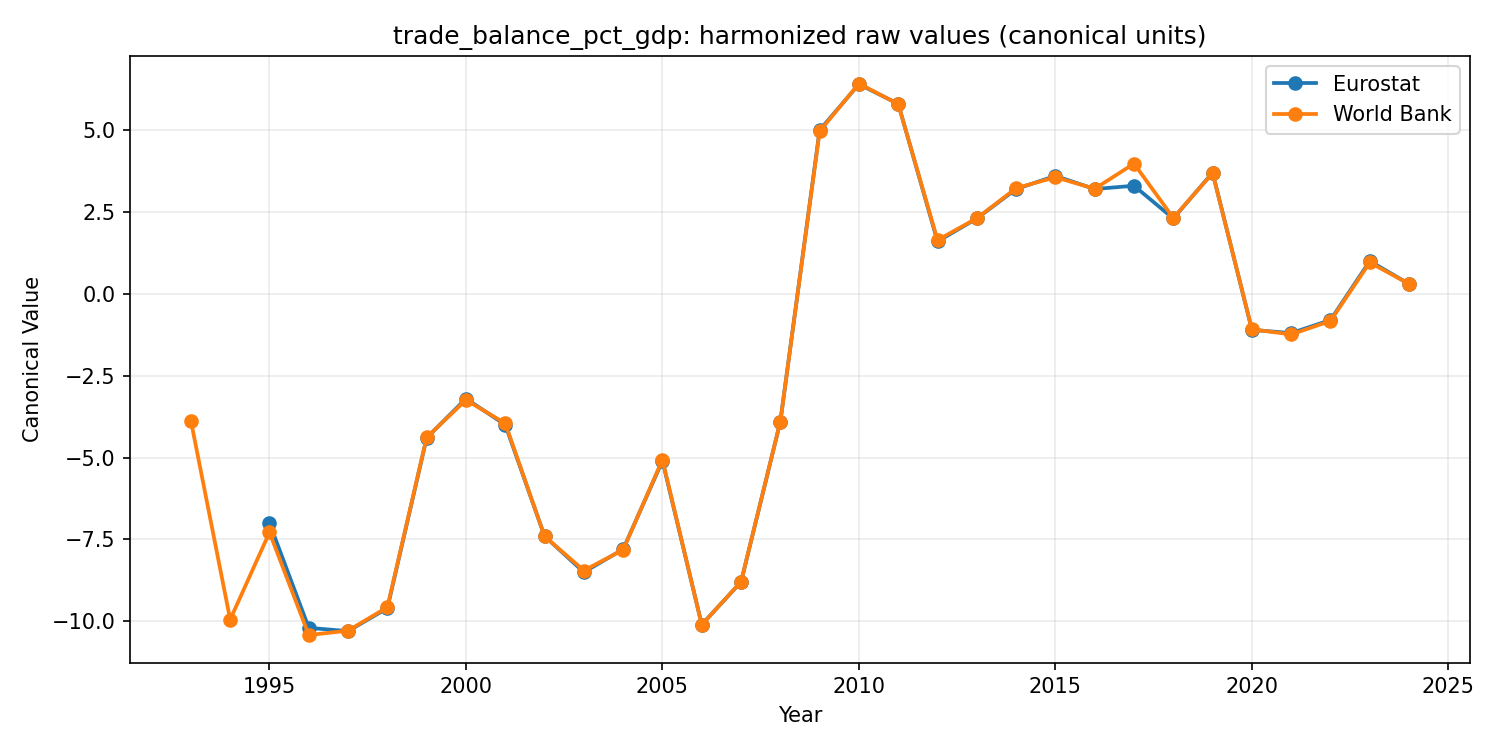

_Glossary:_ canonical-unit values for comparable cross-source analysis.

#### exchange_rate_lcu_per_usd

,chart_type,status,base_year,file_path,note
0,overlay_index,ok,1993.0,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,NaN


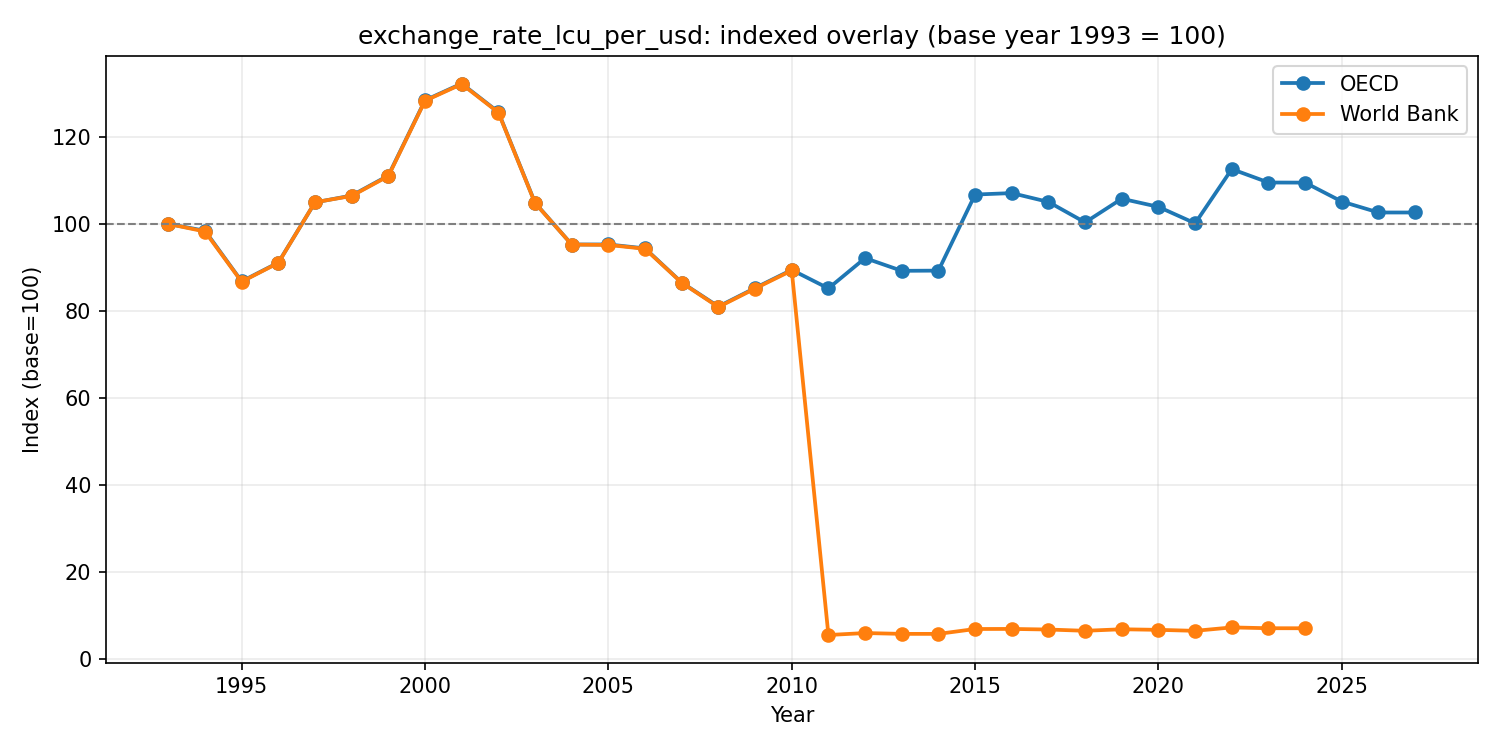

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`PA.NUS.FCRF`) | LCU per USD | LCU per USD | identity | Exact mapping |
| Eurostat raw (`ert_bil_eur_a`) | USD per EUR (`NAC`) | LCU per USD target | not directly comparable | Marked `is_comparable=false` for cross-source overlays |
| Eurostat derived (`eurostat_derived`) | derived from USD/EUR | LCU per USD | LT regime rules by year | Comparable series used in harmonized/overlay charts |
| OECD (`DSD_EO@DF_EO`, `EXCHUD`) | LCU per USD | LCU per USD | identity | Proxy: OECD EO exchange-rate conventions can differ by historical treatment |

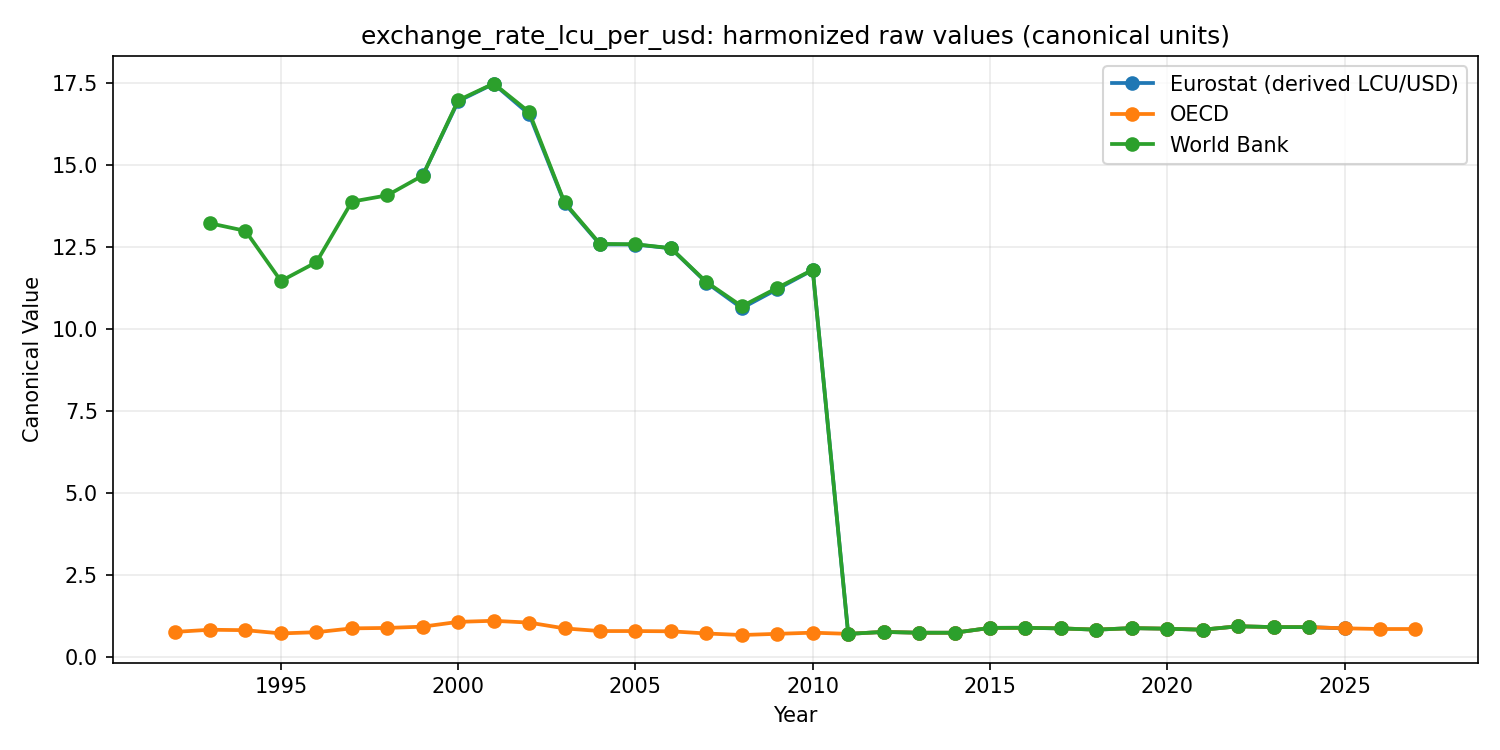

_Glossary:_ canonical-unit values for comparable cross-source analysis.

### Confidence and surveys

_No indicators mapped in current pipeline output._

## Static z-score visuals

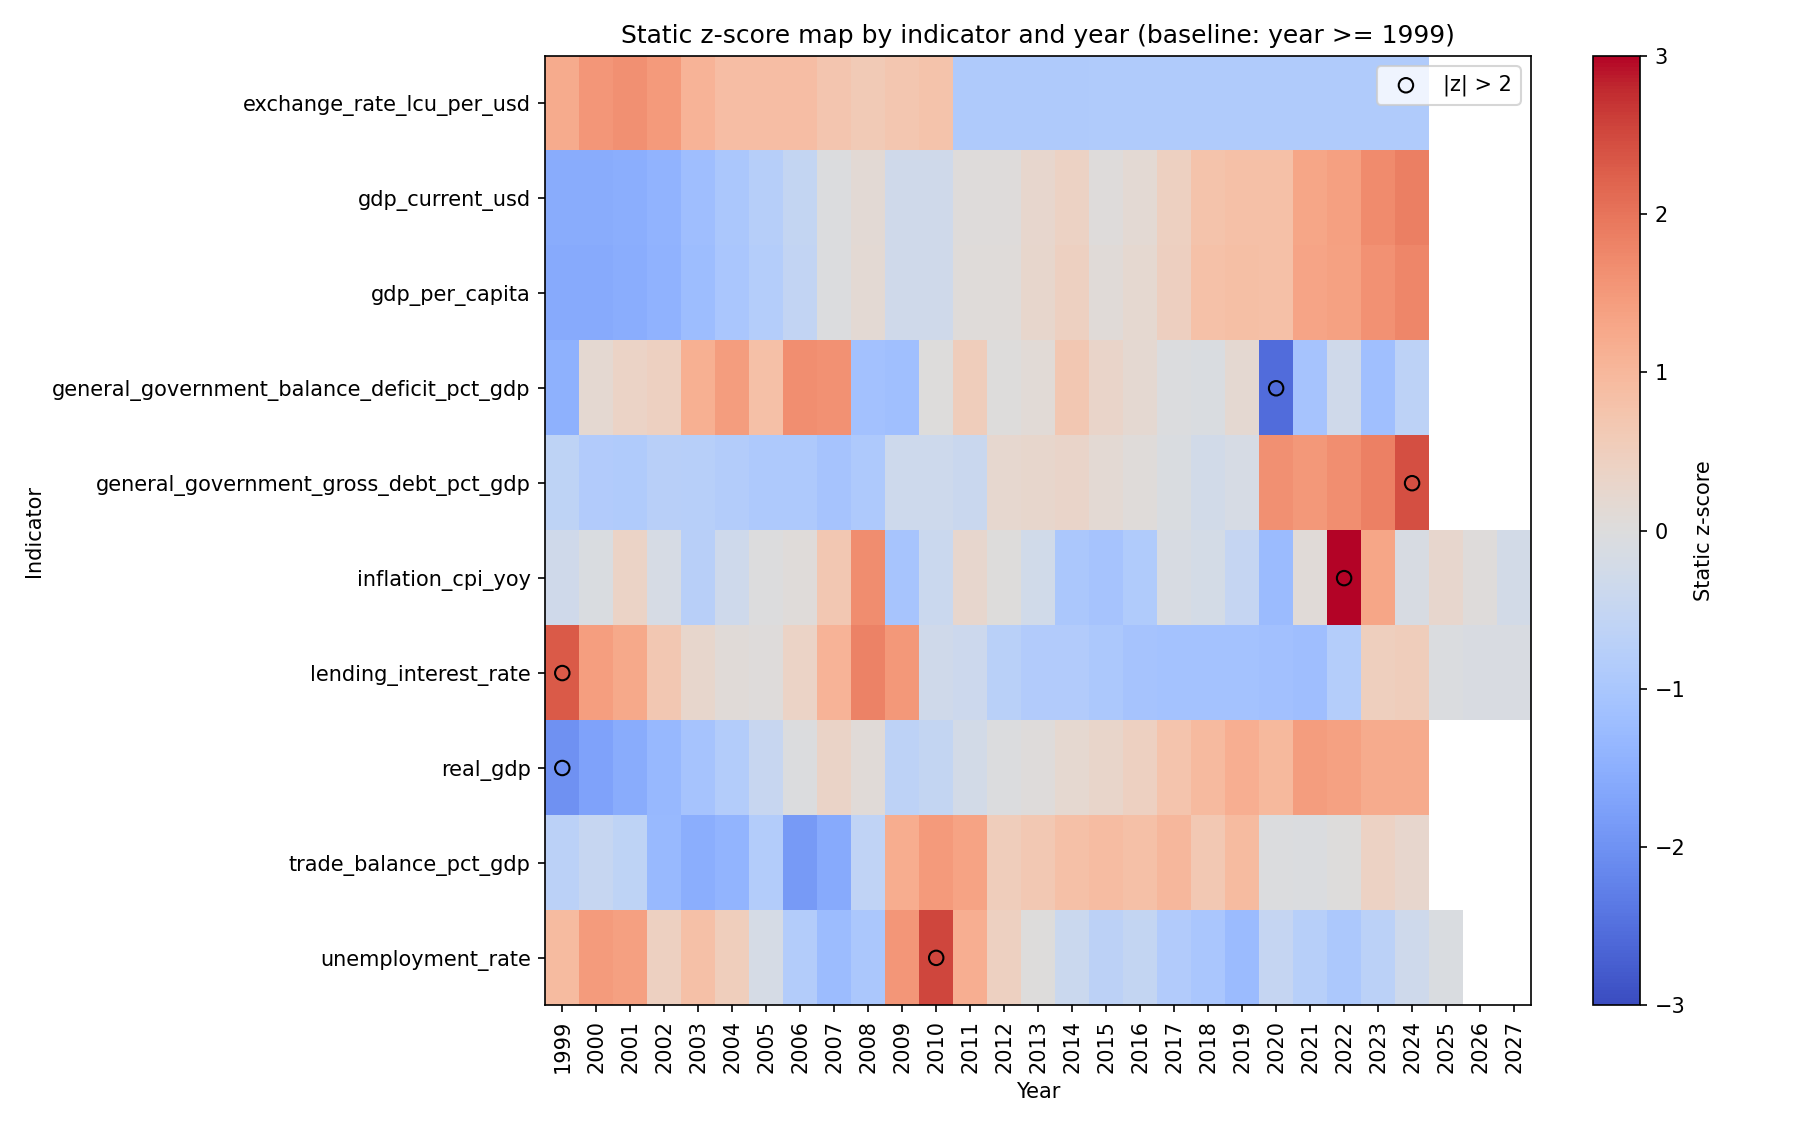

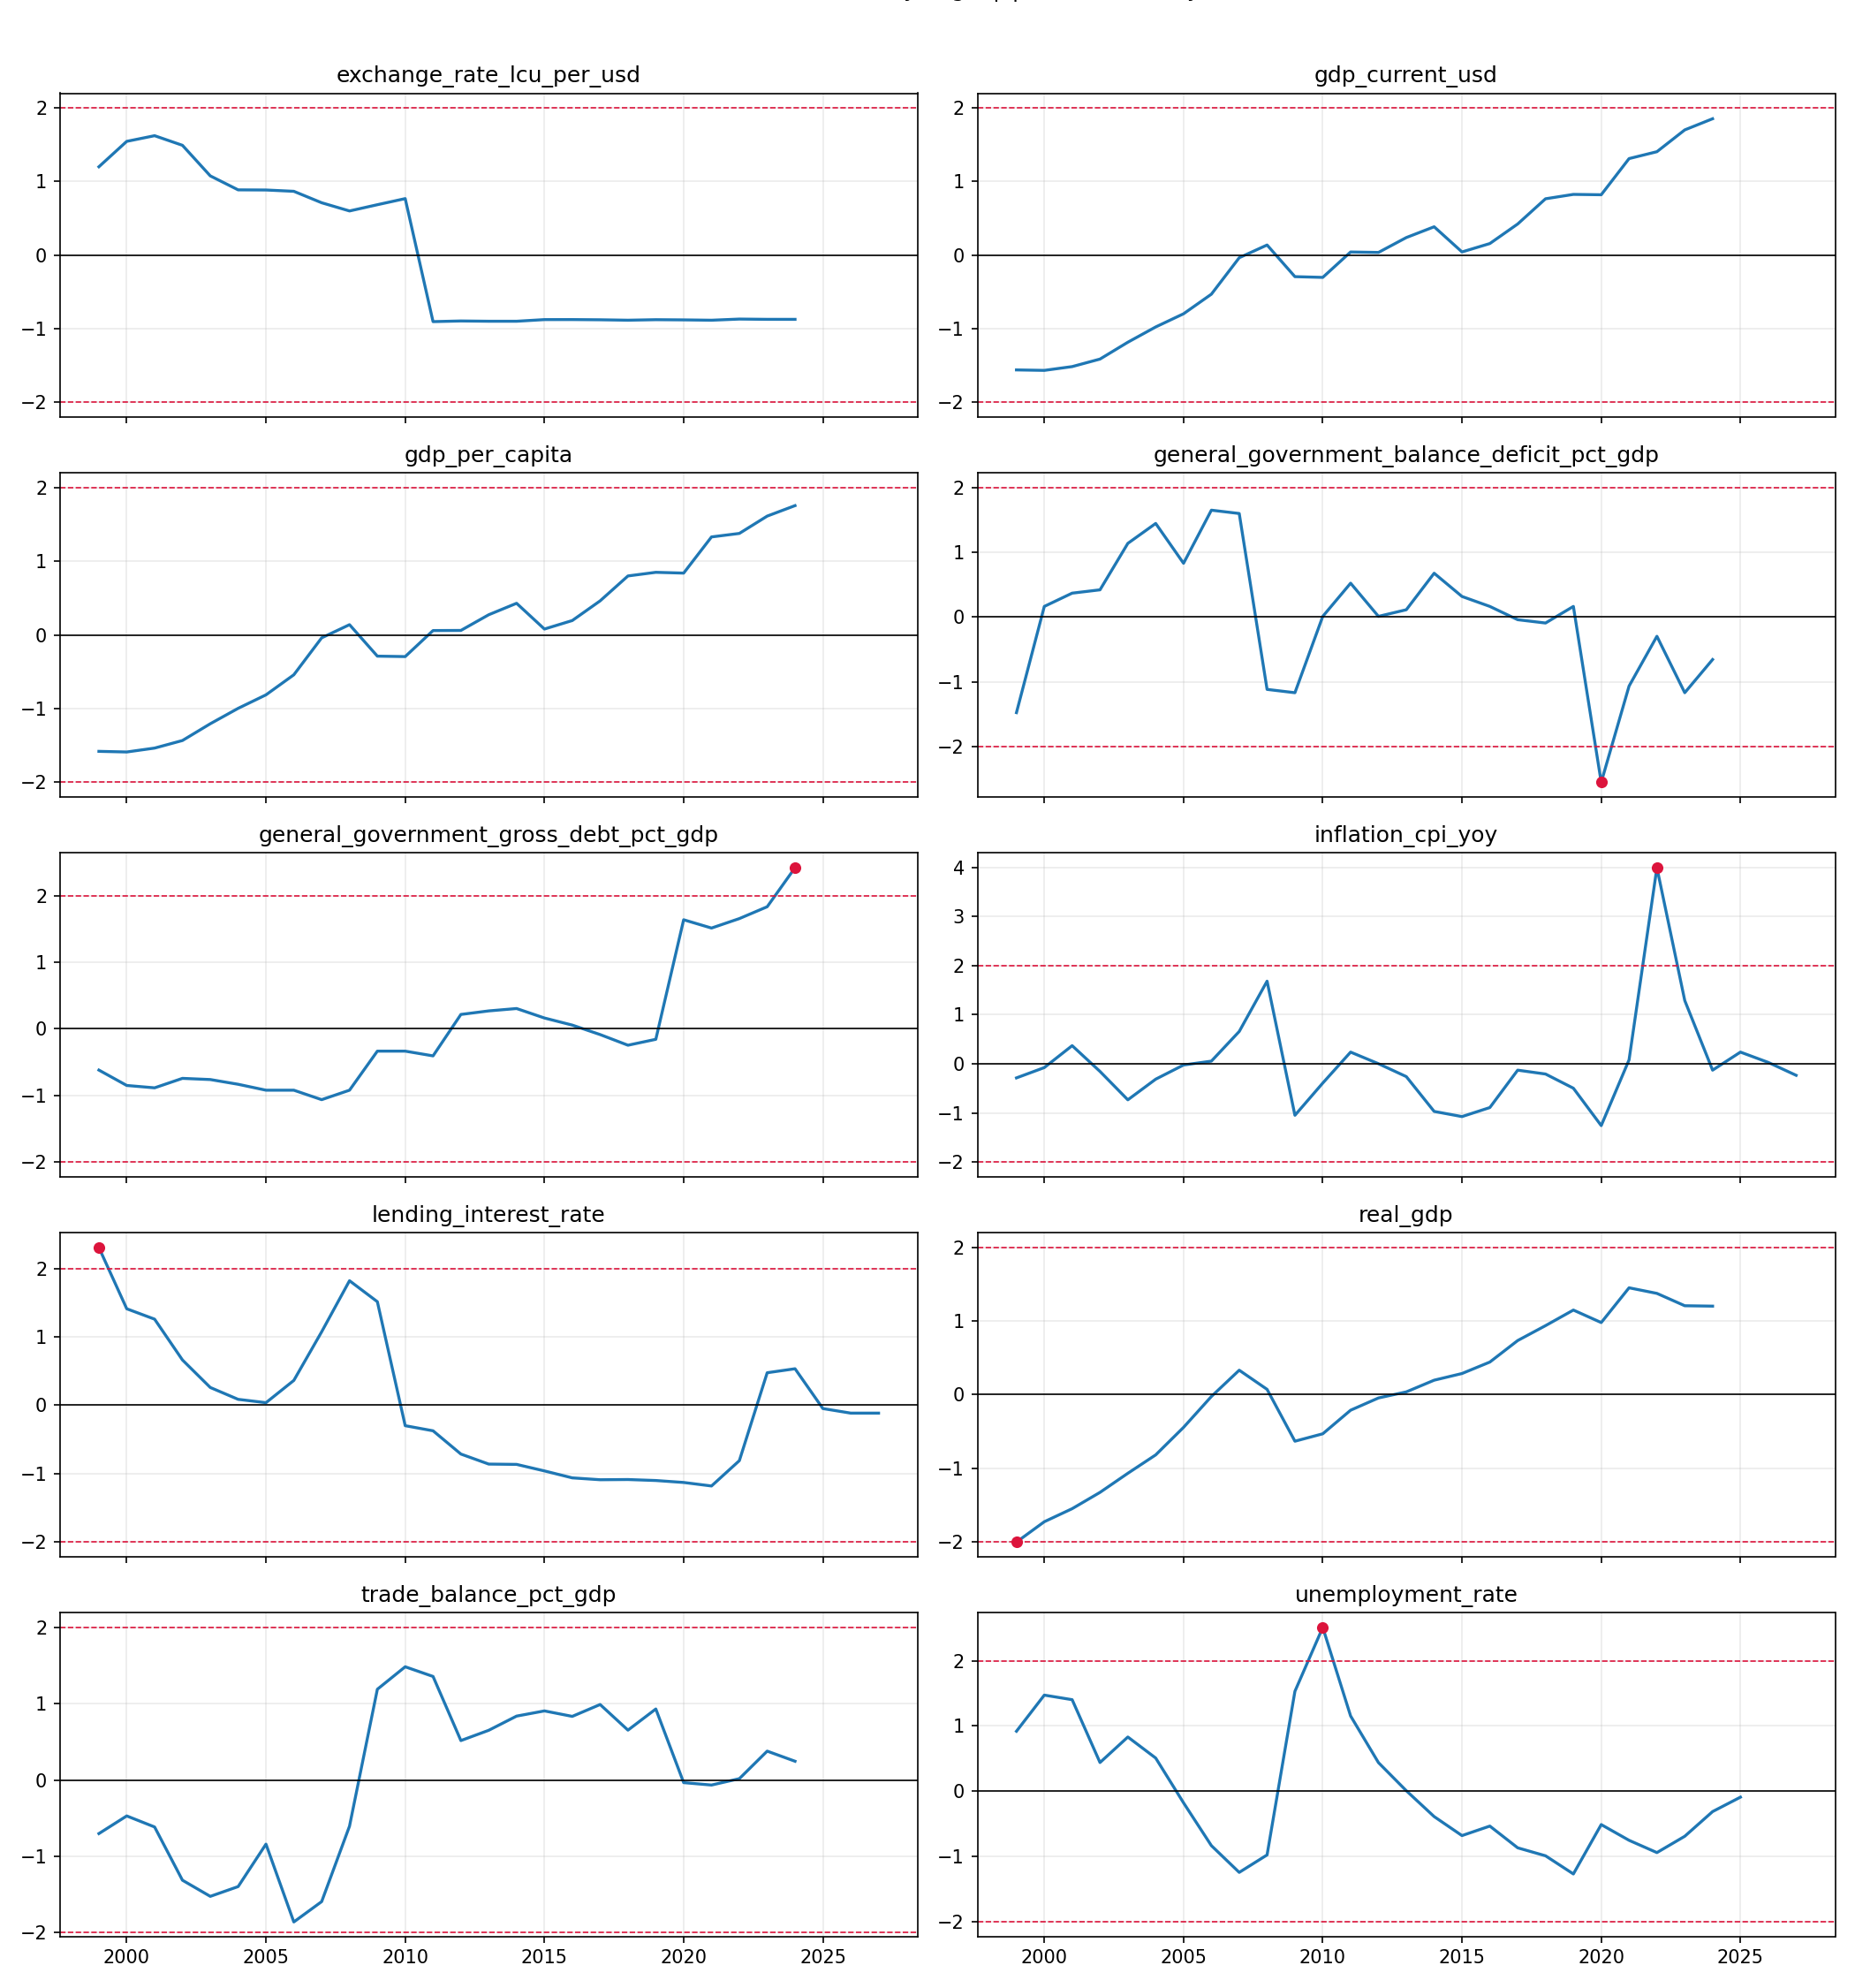

In [8]:
_ee_context = _render_country_section("EE")


This notebook validates country-parameterized execution of the macro indicator pipeline with a reduced chart surface for the Baltic countries.
